Benchmark
============


1. Unterschiedliche Gewichtungsfaktoren (w) der heuristischen Funktion
2. Verschiede Diskretisierungsstufen 
3. Überprüfen der Kanten auf Kollision an/aus
4. Reopening an/aus

Adding all planners
===========


In [1]:
import matplotlib.pylab as plt
%matplotlib inline
from IPPerfMonitor import IPPerfMonitor
#import IPBasicPRM
#import IPVISBasicPRM

#import IPVisibilityPRM
#import IPVISVisibilityPRM

import IPLazyPRM
import IPVISLazyPRM

#import IPRRT
#import IPVISRRT

import IPAStar
import IPVISAStar
import AStarReopeningNew

Set-up of the test scenario and the configuration for all planner
===================================

Following a procedure to compare all discussed planners are shown:

1. Configuration for every planner is defined
2. The configuration and the planner is stored in the variable setup, a Python dict()
3. the variable setup is then used to uniformly call the planning calls


In [ ]:
plannerFactory = dict()

# #========================================
# #Lazy PRM
# #========================================
# lazyConfig = dict()
# lazyConfig["initialRoadmapSize"] = 10
# lazyConfig["updateRoadmapSize"]  = 5 
# lazyConfig["kNearest"] = 8
# lazyConfig["maxIterations"] = 20
# plannerFactory["lazyPRM"] = [IPLazyPRM.LazyPRM, lazyConfig, lazyPRMVisualizeWorkspace]

# #========================================
# #A* Variante 1: w=0.5, grobe Diskretisierung
# #========================================
# astarConfig1 = dict()
# astarConfig1["heuristic"] = 'euclidean' 
# astarConfig1["w"] = 0.5
# astarConfig1["num_steps"] = [10, 10, 36]  # grob
# plannerFactory["astar_w05_grobe_diskretisierung"] = [IPAStar.AStar, astarConfig1, IPVISAStar.aStarVisualizeWspace]

# # ========================================
# # A* Variante 1: w=0.5, feine Diskretisierung
# # ========================================
# astarConfig3 = dict()
# astarConfig3["heuristic"] = 'euclidean' 
# astarConfig3["w"] = 0.5
# astarConfig3["num_steps"] = [44, 44, 36]  # feiner
# plannerFactory["astar_w05_feine_diskretisierung"] = [IPAStar.AStar, astarConfig3, IPVISAStar.aStarVisualizeWspace]

# #========================================
# #A* Variante 2: w=0.7, grobe Diskretisierung
# #========================================
# astarConfig2 = dict()
# astarConfig2["heuristic"] = 'euclidean' 
# astarConfig2["w"] = 0.7
# astarConfig2["num_steps"] = [20, 20, 36]  # grob
# plannerFactory["astar_w07_grobe_diskretisierung"] = [IPAStar.AStar, astarConfig2, IPVISAStar.aStarVisualizeWspace]


# # ========================================
# # A* Variante 4: w=0.7, feine Diskretisierung
# # ========================================
# astarConfig4 = dict()
# astarConfig4["heuristic"] = 'euclidean' 
# astarConfig4["w"] = 0.7
# astarConfig4["num_steps"] = [44, 44, 36]  # feiner
# plannerFactory["astar_w07_fine"] = [IPAStar.AStar, astarConfig4, IPVISAStar.aStarVisualizeWspace]

# ========================================
# A* Variante 3: Mit Edge Collision Check
# ========================================
# astarConfig3 = dict()
# astarConfig3["heuristic"] = 'euclidean' 
# astarConfig3["w"] = 0.5
# astarConfig3["num_steps"] = [20, 20, 36]
# astarConfig3["checkEdgeCollision"] = True  # MIT Kantenkollisionsprüfung
# plannerFactory["astar_w05_with_edgeCheck"] = [IPAStar.AStar, astarConfig3, IPVISAStar.aStarVisualizeWspace]

# # ========================================
# # A* Variante 4: Ohne Edge Collision Check
# # ========================================
# astarConfig4 = dict()
# astarConfig4["heuristic"] = 'euclidean' 
# astarConfig4["w"] = 0.5
# astarConfig4["num_steps"] = [20, 20, 36]
# astarConfig4["checkEdgeCollision"] = False  # OHNE Kantenkollisionsprüfung
# plannerFactory["astar_w05_no_edgeCheck"] = [IPAStar.AStar, astarConfig4, IPVISAStar.aStarVisualizeWspace]

# # # ========================================
# # # A* MIT Reopening
# # # ========================================
# astarReopen_on = dict()
# astarReopen_on["heuristic"] = 'euclidean' 
# astarReopen_on["w"] = 5.0
# astarReopen_on["num_steps"] = [20, 20, 36]
# astarReopen_on["checkEdgeCollision"] = False
# astarReopen_on["allowReopqening"] = True
# plannerFactory["astar_w50_reopening_ON"] = [AStarReopeningNew.ReopenAStar, astarReopen_on, IPVISAStar.aStarVisualizeWspace]

# ========================================
# A* OHNE Reopening (zum Vergleich)
# ========================================
# astarReopen_off = dict()
# astarReopen_off["heuristic"] = 'euclidean' 
# astarReopen_off["w"] = 5.0
# astarReopen_off["num_steps"] = [20, 20, 36]
# astarReopen_off["checkEdgeCollision"] = False
# plannerFactory["astar_w50_reopening_OFF"] = [IPAStar.AStar, astarReopen_off, IPVISAStar.aStarVisualizeWspace]


# Vergleich: unterschiedliche Diskretisierungen (L-shape)

In [8]:
plannerFactory = dict()

#========================================
#A* Variante 1: w=0.5, grobe Diskretisierung
#========================================
astarConfig1 = dict()
astarConfig1["heuristic"] = 'euclidean' 
astarConfig1["w"] = 0.5
astarConfig1["num_steps"] = [10, 10, 36]  # grob
plannerFactory["astar_w05_grobe_diskretisierung"] = [IPAStar.AStar, astarConfig1, IPVISAStar.aStarVisualizeWspace]

# ========================================
# A* Variante 1: w=0.5, feine Diskretisierung
# ========================================
astarConfig3 = dict()
astarConfig3["heuristic"] = 'euclidean' 
astarConfig3["w"] = 0.5
astarConfig3["num_steps"] = [44, 44, 36]  # feiner
plannerFactory["astar_w05_feine_diskretisierung"] = [IPAStar.AStar, astarConfig3, IPVISAStar.aStarVisualizeWspace]

Trap_Complex
Bottleneck_Complex
astar_w05_grobe_diskretisierung [<class 'IPAStar.AStar'>, {'heuristic': 'euclidean', 'w': 0.5, 'num_steps': [10, 10, 36]}, <function aStarVisualizeWspace at 0x000001D3EC335C60>]
Planning: astar_w05_grobe_diskretisierung - Trap_Complex
Planning: astar_w05_grobe_diskretisierung - Bottleneck_Complex
astar_w05_feine_diskretisierung [<class 'IPAStar.AStar'>, {'heuristic': 'euclidean', 'w': 0.5, 'num_steps': [44, 44, 36]}, <function aStarVisualizeWspace at 0x000001D3EC335C60>]
Planning: astar_w05_feine_diskretisierung - Trap_Complex
Planning: astar_w05_feine_diskretisierung - Bottleneck_Complex


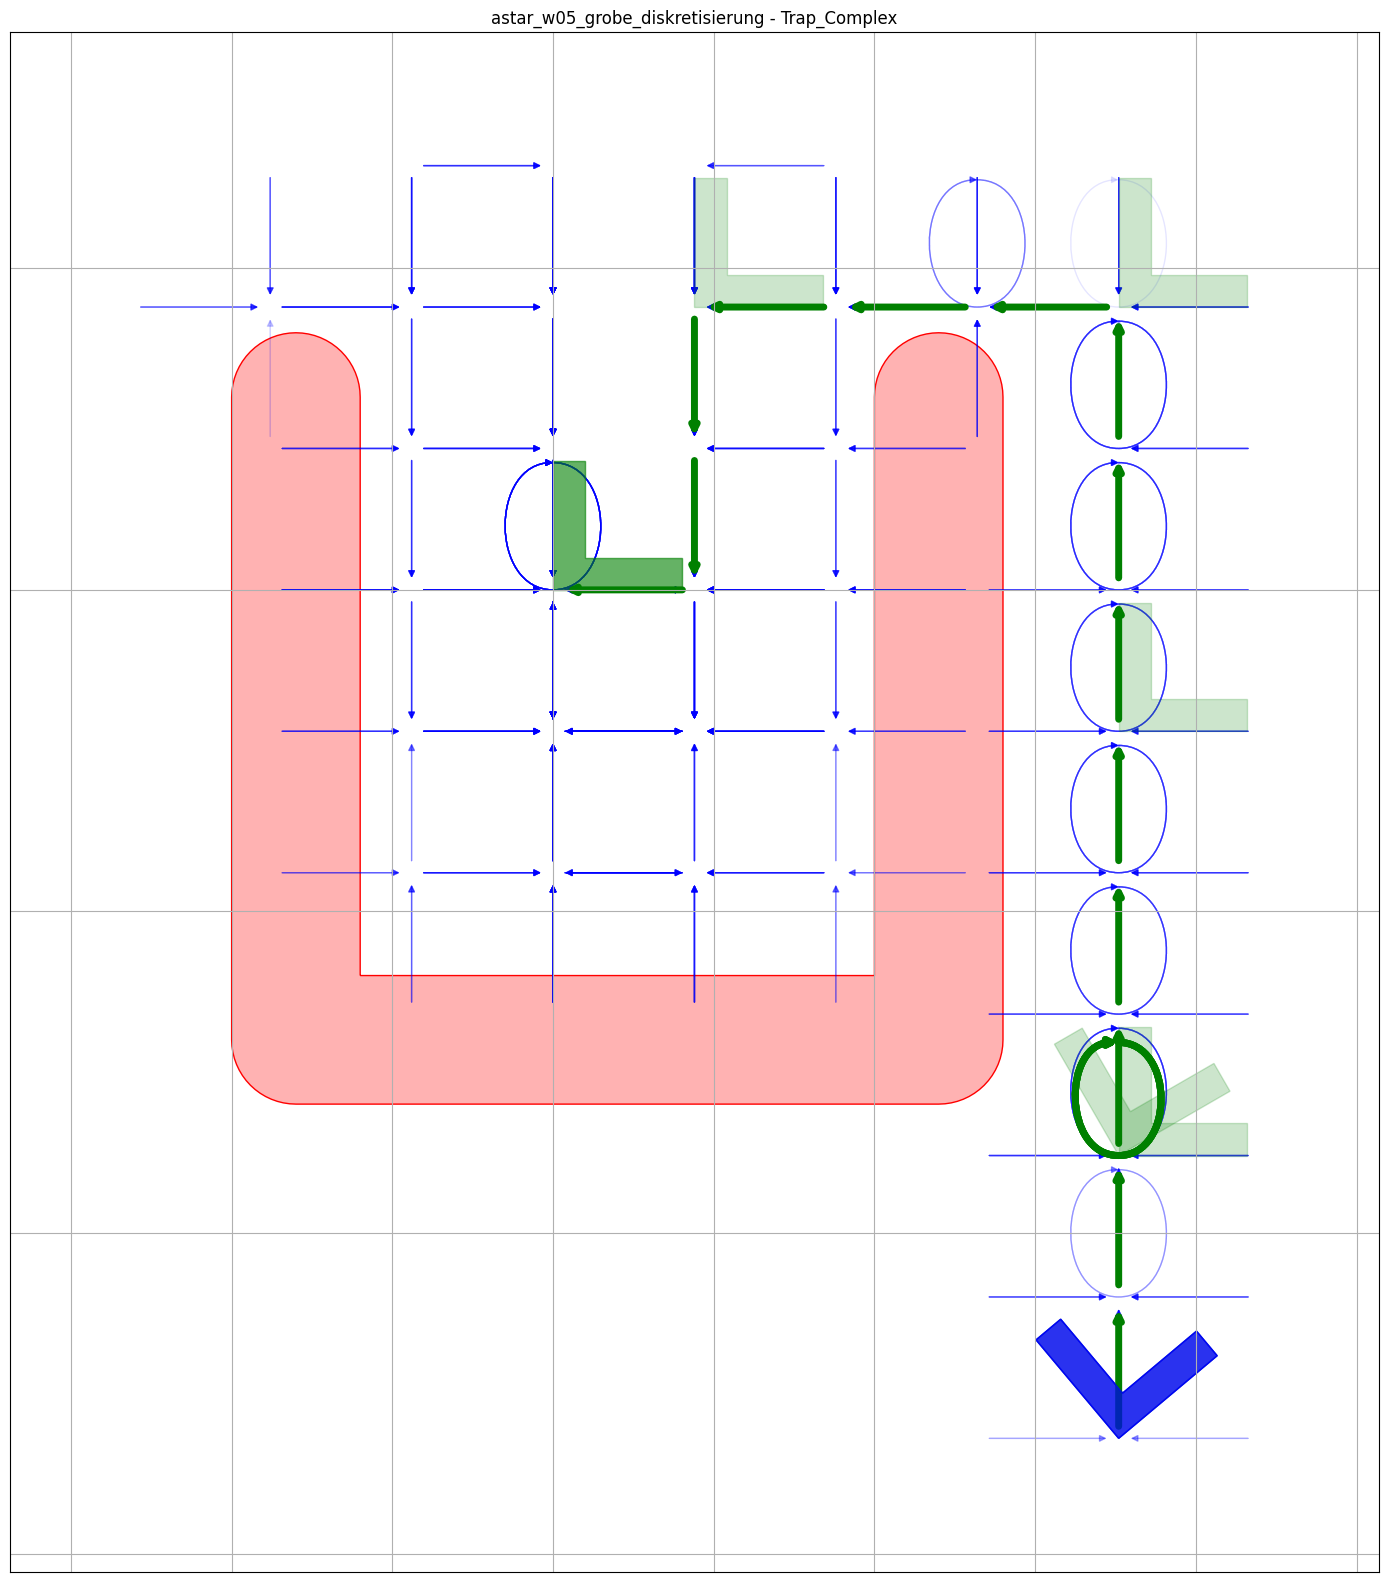

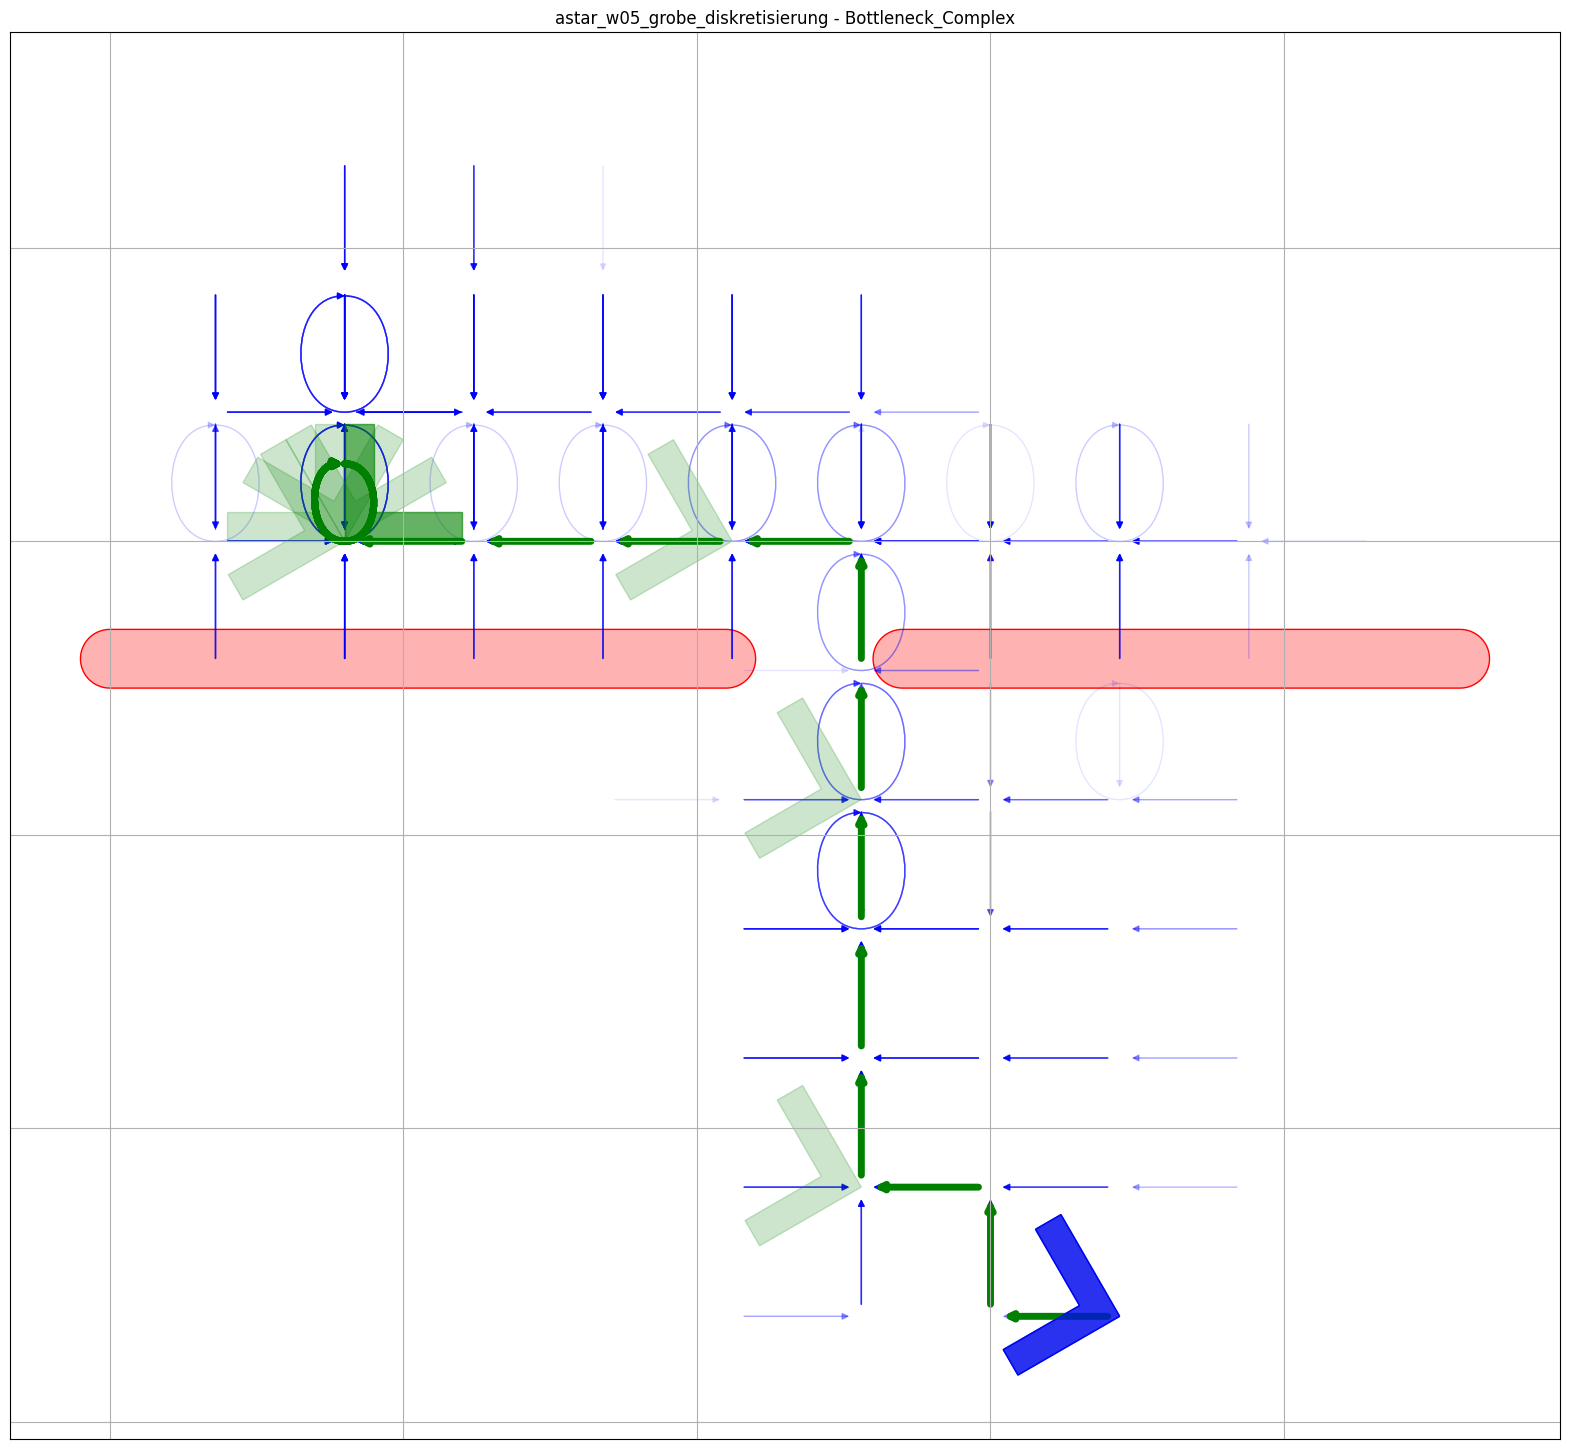

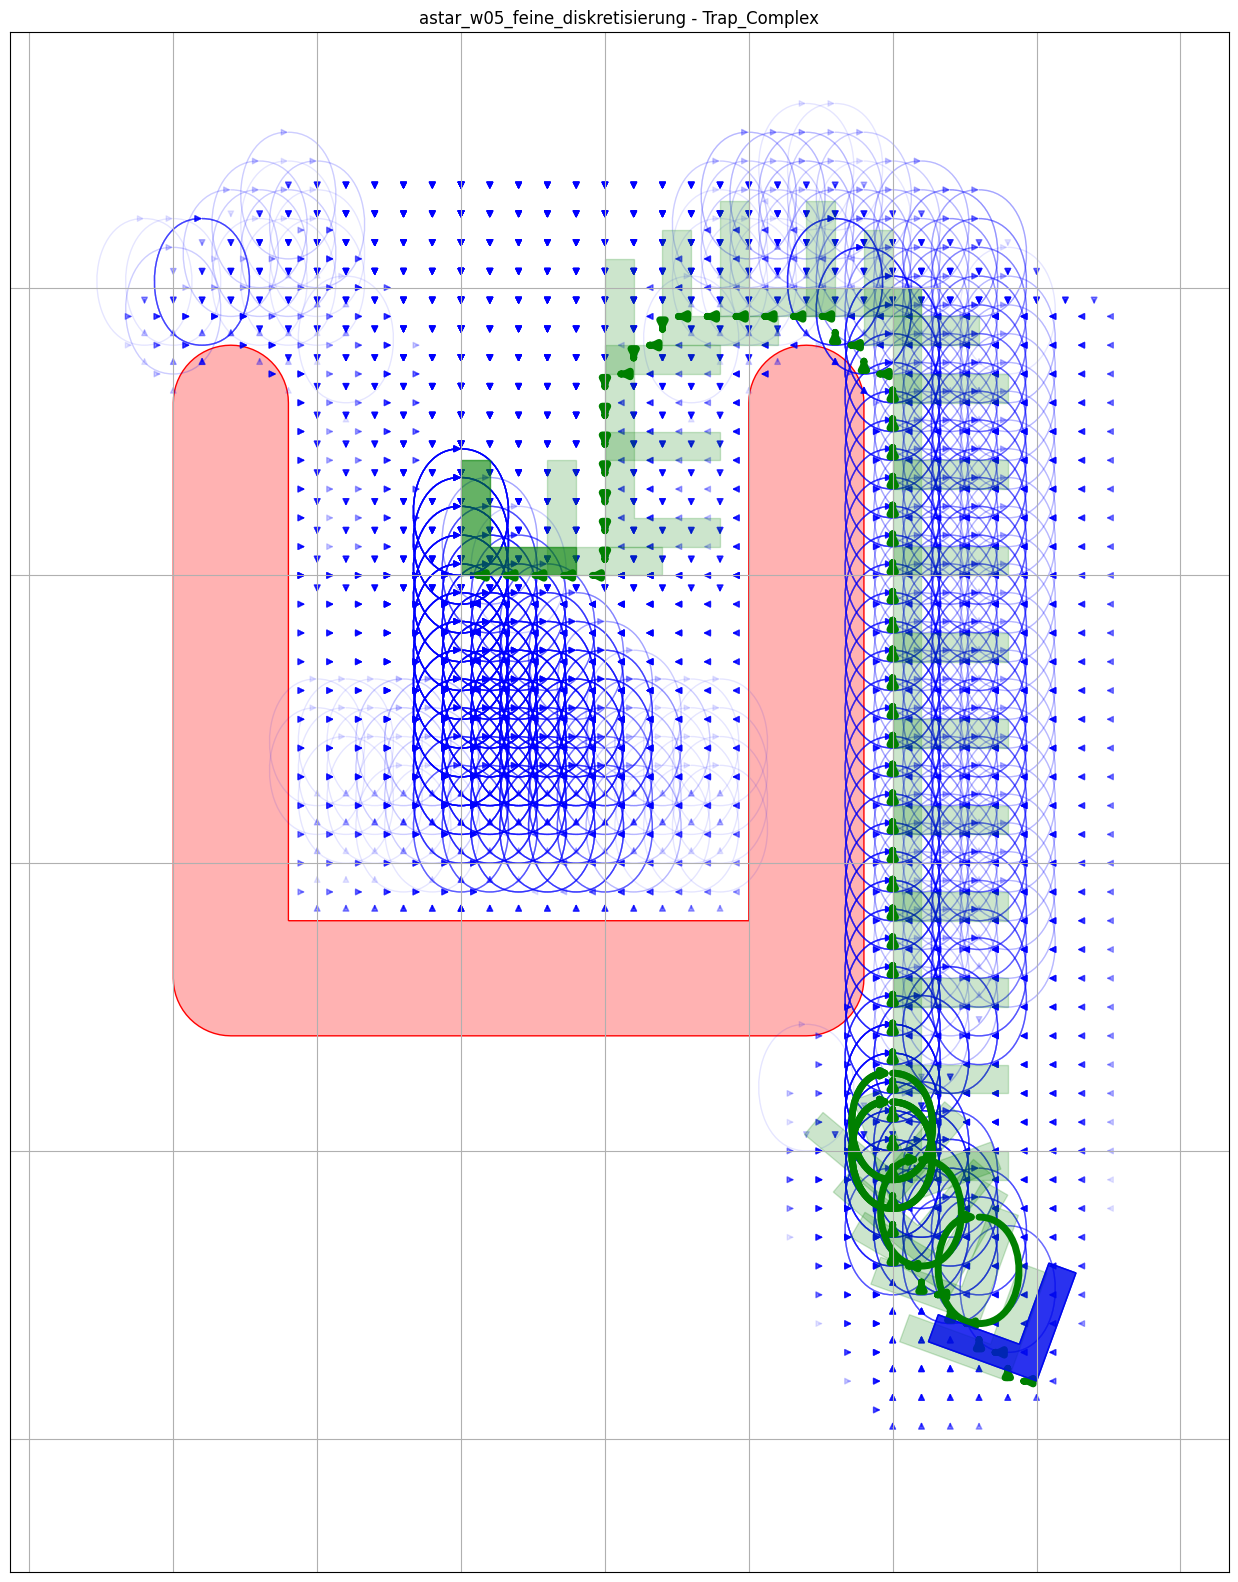

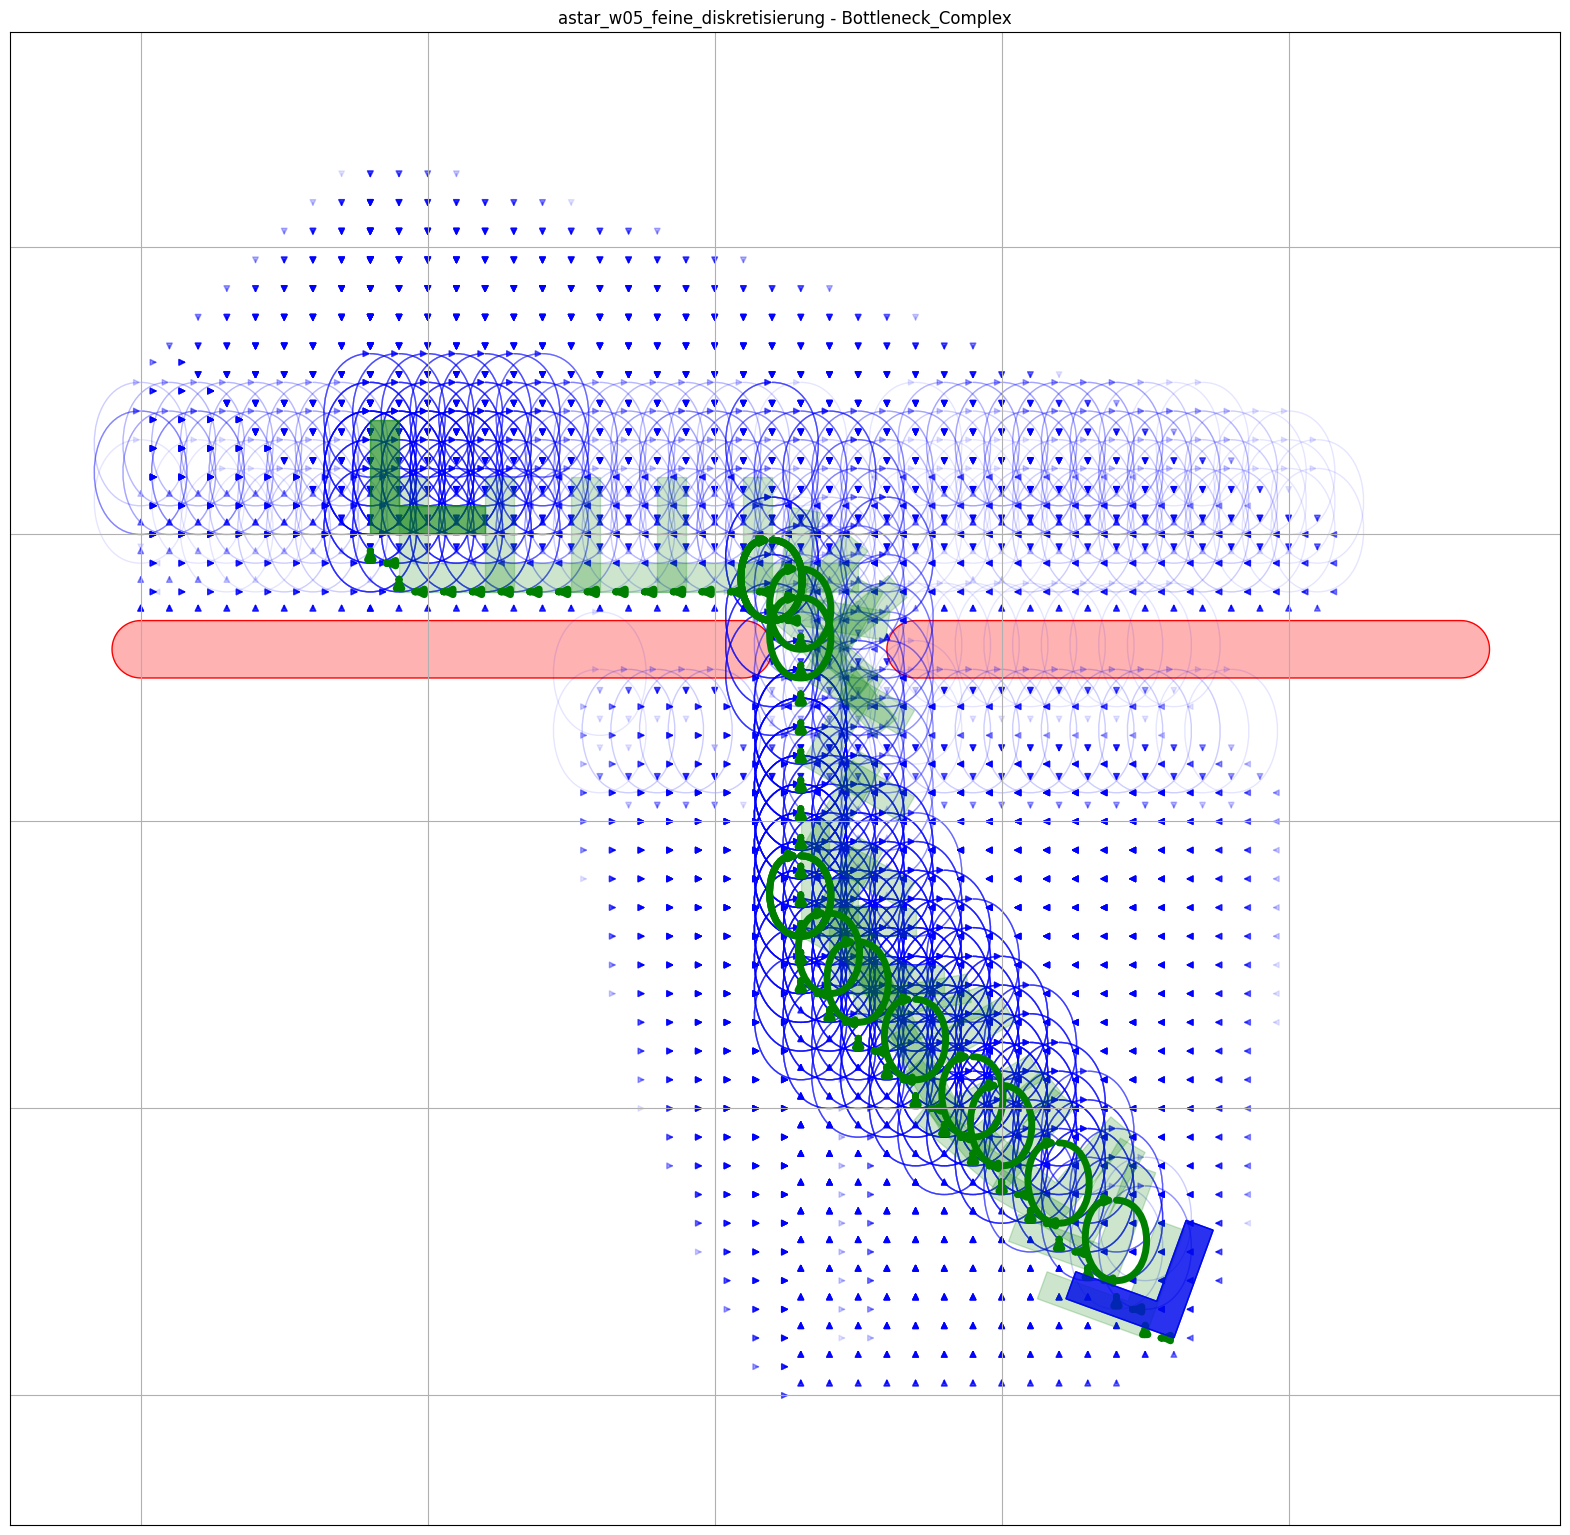

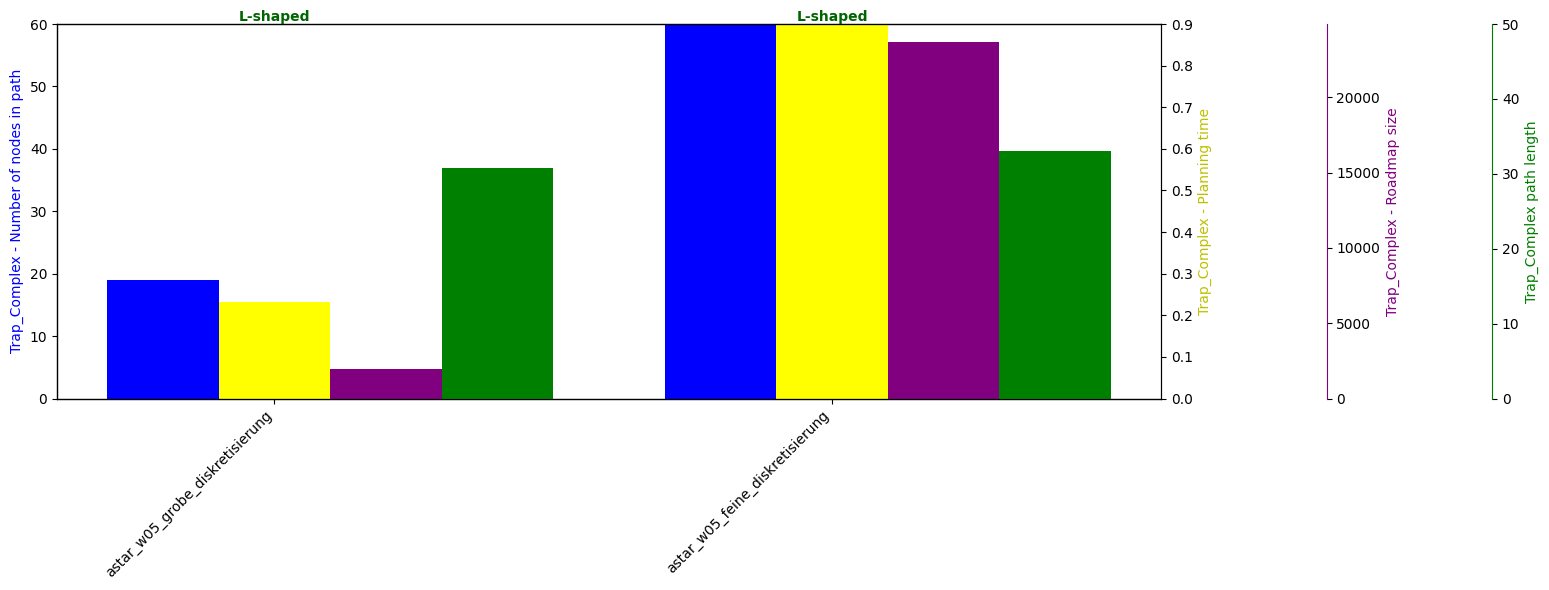

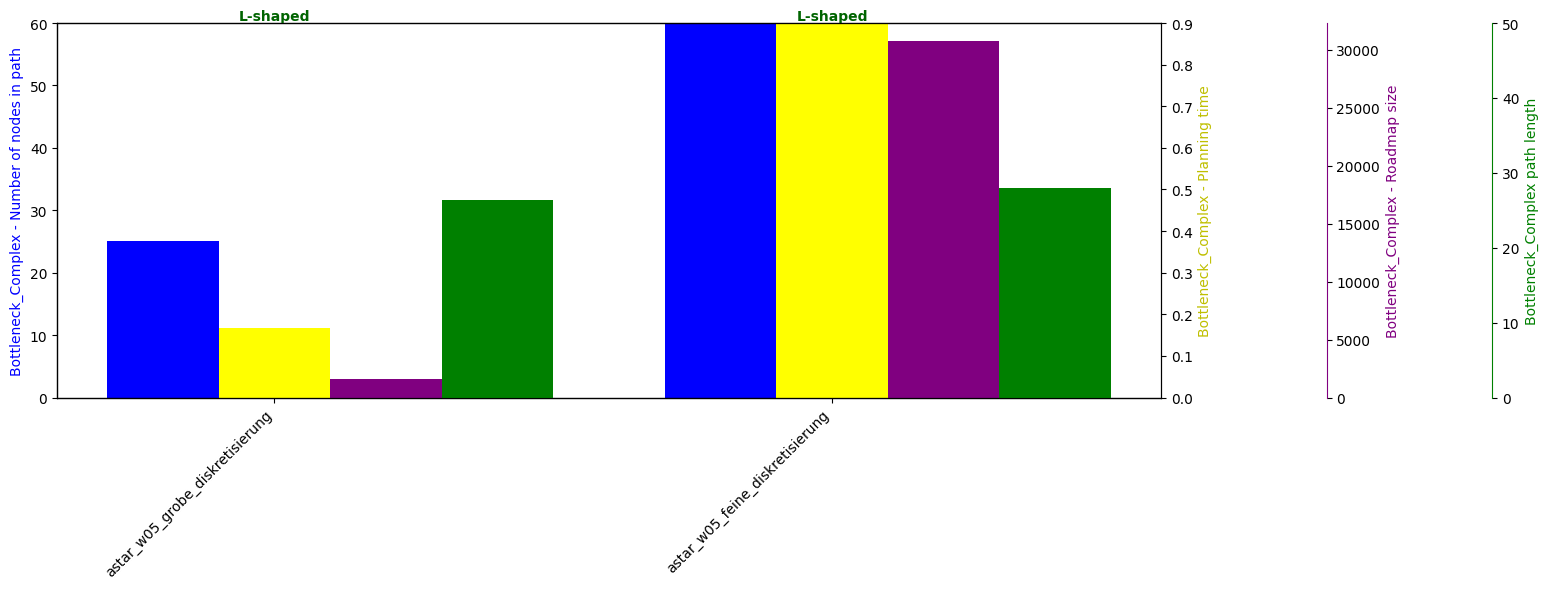

In [9]:
resultList = list()
class ResultCollection (object):
    
    def __init__(self, plannerFactoryName, planner, benchmark, solution, perfDataFrame):
        self.plannerFactoryName = plannerFactoryName
        self.planner = planner
        self.benchmark = benchmark
        self.solution = solution
        self.perfDataFrame = perfDataFrame

import IPTestSuite2 as ts
from shapely.geometry import Point, Polygon, LineString
from shapely import plotting

fullBenchList = ts.benchList

for benchmark in fullBenchList:
    print(benchmark.name)



import matplotlib.animation as animation
from IPython.display import HTML, display
import copy
import numpy as np
import matplotlib.pyplot as plt

# Hilfsfunktion (unverändert, aber wir behandeln den Rückgabewert jetzt besser)
def _interpolate_line(startPos, endPos, step_l):
    steps = []
    line = np.array(endPos) - np.array(startPos)
    line_l = np.linalg.norm(line)
    if line_l == 0:
        return [np.array(startPos)]
    step = line / line_l * step_l
    n_steps = int(np.floor(line_l / step_l))
    c_step = np.array(startPos, dtype=float)
    for i in range(n_steps):
        steps.append(copy.deepcopy(c_step))
        c_step = c_step + step
    if not np.allclose(c_step, np.array(endPos)):
        steps.append(np.array(endPos, dtype=float))
    return steps

def animate_solution_multi_downsampled(prm, environment, solution, visualizer=None, 
                                     workSpaceLimits=None, step_l=0.1, interval=50, 
                                     max_frames=200, figsize=(6,6), dpi=40, 
                                     pause_frames=40):
    
    # 1. Basic Checks
    if not solution or len(solution) < 2:
        raise ValueError('solution must contain at least two nodes')

    # 1. Récupération des positions pour l'interpolation du robot
    path_pos = [prm.graph.nodes[n]['pos'] for n in solution]
    
    # Interpolation (Mouvement fluide du point rouge)
    full_path = [path_pos[0]]
    for i in range(1, len(path_pos)):
        s, e = np.array(path_pos[i-1]), np.array(path_pos[i])
        dist = np.linalg.norm(e - s)
        if dist > 0:
            n_steps = int(np.floor(dist / step_l))
            for j in range(1, n_steps + 1):
                full_path.append(s + (e - s) * (j / (n_steps + 1)))
    full_path.append(path_pos[-1])

    # Downsampling
    if len(full_path) > max_frames:
        indices = np.linspace(0, len(full_path)-1, max_frames).astype(int)
        frames_data = [full_path[i] for i in indices]
    else:
        frames_data = full_path

    # 2. Setup Figure
    fig_local, ax = plt.subplots(figsize=figsize, dpi=dpi)
    limits = environment.getEnvironmentLimits()

    def _animate(current_pos):
        ax.cla() # On efface pour redessiner proprement
        
        # --- VISUALIZER OHNE ROBOTER-SHAPES ---
        # Deaktiviere temporär die drawRobot Methode, damit der Visualizer
        # die Diskretisierung zeichnet, aber nicht die grünen Roboter-Shapes
        original_drawRobot = environment.robot.drawRobot
        environment.robot.drawRobot = lambda ax, **kwargs: None  # Dummy-Funktion
        
        visualizer(prm, solution, ax=ax, nodeSize=100)
        
        # Stelle die ursprüngliche drawRobot Methode wieder her
        environment.robot.drawRobot = original_drawRobot
        
        # On redessine les obstacles par sécurité
        environment.drawObstacles(ax)
        
        # On remet les limites (parce que visualizer peut les changer)
        ax.set_xlim(limits[0])
        ax.set_ylim(limits[1])
        ax.set_title("A* Visualization & Animation")

        # --- MARKIERUNG VON START UND ZIEL ---
        # Startpunkt: Grüner Punkt mit 'S'
        start_pos = path_pos[0]
        ax.plot(start_pos[0], start_pos[1], 'o', color='#00dd00', 
                markersize=15, markeredgecolor='black', zorder=11)
        ax.text(start_pos[0], start_pos[1], 'S', ha='center', va='center',
                fontsize=12, fontweight='bold', color='black', zorder=12)
        
        # Zielpunkt: Roter Punkt mit 'G'
        goal_pos = path_pos[-1]
        ax.plot(goal_pos[0], goal_pos[1], 'o', color='#DD0000', 
                markersize=15, markeredgecolor='black', zorder=11)
        ax.text(goal_pos[0], goal_pos[1], 'G', ha='center', va='center',
                fontsize=12, fontweight='bold', color='white', zorder=12)

        # --- NUR DER ANIMIERTE ROTE ROBOTER ---
        environment.robot.setTo(current_pos)
        environment.robot.drawRobot(ax, color='red', alpha=0.9)

    print(f"Rendu de l'animation (Diskretisierung + nur roter Roboter)...")
    ani = animation.FuncAnimation(fig_local, _animate, frames=frames_data, interval=interval)
    
    html = HTML(ani.to_jshtml())
    display(html)
    plt.close()
    return ani

import networkx as nx

def lazyPRMVisualizeWorkspace(planner, solution = [] , ax=None, nodeSize = 300):
    """
    Angepasster Visualizer für LazyPRM im Workspace (nur x,y aus 3D-Konfigurationsraum)
    """
    graph = planner.graph.copy()
    collChecker = planner._collisionChecker
    collEdges = planner.collidingEdges
    nonCollEdges = planner.nonCollidingEdges
    
    # Extrahiere nur x,y aus (x, y, theta) Positionen
    pos_3d = nx.get_node_attributes(graph,'pos')
    pos = {node: (coords[0], coords[1]) for node, coords in pos_3d.items()}
    
    color = nx.get_node_attributes(graph,'color')

    collChecker.drawObstacles(ax)
    
    # draw graph
    nx.draw_networkx_nodes(graph, pos, ax = ax, nodelist=list(color.keys()), 
                          node_color=list(color.values()), node_size=nodeSize)
    nx.draw_networkx_edges(graph, pos, ax = ax)
    
    # draw all connected components, emphasize the largest one
    Gcc=(graph.subgraph(c) for c in nx.connected_components(graph))
    G0=next(Gcc)
    
    nx.draw_networkx_edges(G0, pos,
                          edge_color='b',
                          width=3.0, style='dashed',
                          alpha=0.5)
    
    if collEdges != []:
        collGraph = nx.Graph()
        collGraph.add_nodes_from(graph.nodes(data=True))
        for i in collEdges:
            collGraph.add_edge(i[0],i[1])
        nx.draw_networkx_edges(collGraph, pos, alpha=0.2, edge_color='r', width=5)
    
    if nonCollEdges != []:
        nonCollGraph = nx.Graph()
        nonCollGraph.add_nodes_from(graph.nodes(data=True))
        for i in nonCollEdges:
            nonCollGraph.add_edge(i[0],i[1])
        nx.draw_networkx_edges(nonCollGraph, pos, alpha=0.8, edge_color='yellow', width=5)
    
    # draw start and goal
    if "start" in graph.nodes(): 
        nx.draw_networkx_nodes(graph, pos, nodelist=["start"],
                              node_size=300,
                              node_color='#00dd00', ax = ax)
        nx.draw_networkx_labels(graph, pos, labels={"start": "S"}, ax = ax)

    if "goal" in graph.nodes():
        nx.draw_networkx_nodes(graph, pos, nodelist=["goal"],
                              node_size=300,
                              node_color='#DD0000', ax = ax)
        nx.draw_networkx_labels(graph, pos, labels={"goal": "G"}, ax = ax)

    if solution != []:
        Gsp = nx.subgraph(graph, solution)
        nx.draw_networkx_edges(Gsp, pos, alpha=0.8, edge_color='g', width=10)
    
    return


# for benchmark in fullBenchList:
#     fig_local = plt.figure(figsize=(7,7))
#     ax = fig_local.add_subplot(1,1,1)
#     title = benchmark.name
#     ax.set_title(title)
#     ax.set_xlim(benchmark.collisionChecker.getEnvironmentLimits()[0])
#     ax.set_ylim(benchmark.collisionChecker.getEnvironmentLimits()[1])
#     plotting.plot_points(Point(benchmark.startList[0]).buffer(.3), color="g", ax=ax)
#     plotting.plot_points(Point(benchmark.goalList[0]).buffer(.3), color="b", ax=ax)
#     #try:
#     benchmark.collisionChecker.drawObstacles(ax)
  
        
#     #except Exception as e:
#     #    print ("Error", e)
#     #    pass
#     plt.show()


resultList = list()
testList = fullBenchList

for key,producer in list(plannerFactory.items()):
    print(key, producer)
    for benchmark in testList:
        print ("Planning: " + key + " - " + benchmark.name)
        #planner = IPBasicPRM.BasicPRM(benchmark.collisionChecker)
        planner = producer[0](benchmark.collisionChecker)
        IPPerfMonitor.clearData()
        try:
            
            resultList.append(ResultCollection(key,
                                          planner, 
                                           benchmark, 
                                           planner.planPath(benchmark.startList,benchmark.goalList,producer[1]),
                                           IPPerfMonitor.dataFrame()
                                          ),
                        )
        except Exception as e:
        #    throw e
            print ("PLANNING ERROR ! PLANNING ERROR ! PLANNING ERROR ", e)
            pass

import matplotlib.pyplot as plt

for result in resultList:
    
    fig_local = plt.figure(figsize=(20,20))
    ax = fig_local.add_subplot(1,1,1)
    title = result.plannerFactoryName + " - " + result.benchmark.name
    if result.solution == []:
        title += " (No path found!)"
    #title += "\n Assumed complexity level " + str(result.benchmark.level)
    ax.set_title(title)
    try:
        # Temporär erweiter Ludwig Setze den Roboter an die Endposition, falls eine Lösung existiert
        if result.solution and len(result.solution) > 0:
            goal_node = result.solution[-1]
            if hasattr(result.planner, 'graph') and goal_node in result.planner.graph.nodes:
                goal_pos = result.planner.graph.nodes[goal_node]['pos']
                result.benchmark.collisionChecker.robot.setTo(goal_pos)
        
        #IPVISBasicsPRM.basicPRMVisualize(result.planner, result.solution, ax=ax, nodeSize=100))
        plannerFactory[result.plannerFactoryName][2](result.planner, result.solution, ax=ax, nodeSize=100)
        
        # Zeichne Roboter am Startpunkt (grün) und Endpunkt (blau)
        if result.solution and len(result.solution) > 0:
            if hasattr(result.planner, 'graph'):
                # Startroboter in grün
                start_node = result.solution[0]
                if start_node in result.planner.graph.nodes:
                    start_pos = result.planner.graph.nodes[start_node]['pos']
                    result.benchmark.collisionChecker.robot.setTo(start_pos)
                    result.benchmark.collisionChecker.robot.drawRobot(ax, color='green', alpha=0.5)
                
                # Endroboter in blau
                goal_node = result.solution[-1]
                if goal_node in result.planner.graph.nodes:
                    goal_pos = result.planner.graph.nodes[goal_node]['pos']
                    result.benchmark.collisionChecker.robot.setTo(goal_pos)
                    result.benchmark.collisionChecker.robot.drawRobot(ax, color='blue', alpha=0.7)
        
    except Exception as e:
        print ("Error", e)
        pass
    
    plt.show()

# for bench in testList:
#     for result in resultList:
#         if result.benchmark.name == bench.name:
#             # Prüfe ob Lösung existiert UND mindestens 2 Knoten hat
#             if result.solution is not None and len(result.solution) >= 2:
#                 print(f"Animation für: {result.plannerFactoryName} - {bench.name}")
#                 print(f"  Anzahl Knoten im Pfad: {len(result.solution)}")
#                 try:
#                     animate_solution_multi_downsampled(
#                         result.planner, bench.collisionChecker, result.solution,
#                         visualizer=plannerFactory[result.plannerFactoryName][2],
#                         step_l=0.05, interval=60, max_frames=200, figsize=(20,20), dpi=40)
#                 except Exception as e:
#                     print(f"  FEHLER bei Animation: {e}")
#             else:
#                 if result.solution is None:
#                     print(f"Keine Animation für {result.plannerFactoryName} - {bench.name}: Keine Lösung gefunden")
#                 else:
#                     print(f"Keine Animation für {result.plannerFactoryName} - {bench.name}: Zu wenige Knoten ({len(result.solution)})")

def compute_path_lengths_multi(graph, solution, theta_in_radians=True):
    """
    Berechnet die Gesamtpfadläng pro Roboter in einem Graphen mit mehreren Robotern

    Das Knotenattribut 'pos' ist eine sequenz [x1,y1,theta1, x2,y2,theta2,...]
    Für unsere zwei Roboter sind es 6 Einträge pro Knoten.
    Die Funktion summiert die euklidischen Distanzen zwischen jedem Knotenpaar (Kanten) in der xy-Ebene für jeden Roboter auf.
    """
    import numpy as np
    import networkx as nx

    # Falls keine Lösung oder nur ein Knoten vorhanden ist, sofort Nullwerte zurückgeben
    if not solution or len(solution) < 2:
        return {
            'green': {'total': 0.0},
            'red': {'total': 0.0},
            'segments': 0
        }

    # Hole alle 'pos' Attribute aus dem Graph (dict: node -> config)
    pos_attr = nx.get_node_attributes(graph, 'pos')
    total_g = 0.0  # aufsummierte Distanz für grünen Roboter (Roboter 1)
    total_r = 0.0  # aufsummierte Distanz für roten Roboter (Roboter 2)
    segments = 0   # Anzahl der Segmente (Anzahl Kanten im Pfad)

    # Iteriere über alle aufeinanderfolgenden Knotenpaare der Lösung
    for i in range(len(solution) - 1):
        a = solution[i]; b = solution[i + 1]
        # Fehler, falls ein Knoten kein 'pos' Attribut hat (schützt vor inkonsistenten Graphen)
        if a not in pos_attr or b not in pos_attr:
            raise ValueError(f"Node {a} or {b} missing 'pos' attribute in graph")
        pa = np.array(pos_attr[a], dtype=float)  # Konfiguration an Knoten a
        pb = np.array(pos_attr[b], dtype=float)  # Konfiguration an Knoten b

        # Berechne Euklidische Distanz in der xy‑Ebene für Roboter 1 (grün)
        # pa[0:2] und pb[0:2] sind [x1,y1] für Roboter 1
        total_g += float(np.linalg.norm(pb[0:2] - pa[0:2]))

        # Berechne Euklidische Distanz in der xy‑Ebene für Roboter 2 (rot)
        # pa[3:5] und pb[3:5] sind [x2,y2] für Roboter 2
        total_r += float(np.linalg.norm(pb[3:5] - pa[3:5]))

        segments += 1  # ein weiteres Kanten-Segment wurde betrachtet

    # Rückgabe: pro Roboter nur die 'total' Länge (Rotationen werden hier bewusst nicht berücksichtigt)
    return {
        'green': {'total': total_g},
        'red': {'total': total_r},
        'segments': segments
    }


def get_robot_shape_description(benchmark):
    """Ermittelt eine Beschreibung der Roboterform basierend auf der Geometrie."""
    try:
        robot = benchmark.collisionChecker.robot
        if hasattr(robot, '_template'):
            # ShapeRobotWithOrientation - verwende Template Geometrie
            coords = list(robot._template.exterior.coords)
        elif hasattr(robot, 'geometry'):
            # ShapeRobot - verwende direkte Geometrie
            coords = list(robot.geometry.exterior.coords)
        else:
            return "Unknown"
        
        # Analysiere die Form basierend auf Eckpunkten
        num_vertices = len(coords) - 1  # Letzter Punkt = erster Punkt
        
        # Prüfe ob es ein Rechteck ist (4 Eckpunkte)
        if num_vertices == 4:
            # Prüfe Dimensionen
            xs = [c[0] for c in coords]
            ys = [c[1] for c in coords]
            width = max(xs) - min(xs)
            height = max(ys) - min(ys)
            
            if abs(width - 2.5) < 0.1 and abs(height - 1.0) < 0.1:
                return "Rectangle (2.5x1.0)"
            else:
                return f"Rectangle ({width:.1f}x{height:.1f})"
        
        # Prüfe ob es ein L-förmiger Roboter ist (6 Eckpunkte)
        elif num_vertices == 6:
            return "L-shaped"
        
        else:
            return f"Custom ({num_vertices} vertices)"
    except:
        return "Unknown"

import numpy as np
for bench in testList:
    title = bench.name
    
    # Roboter-Form zur Beschreibung hinzufügen
    robot_shape = get_robot_shape_description(bench)
    
    pathLength = dict()
    planningTime = dict()
    roadmapSize  = dict()
    res=dict()

    try:
        for result in resultList:
            if result.benchmark.name == bench.name:
                #print result.benchmark.name  + " - " +  result.plannerFactoryName, len(result.solution)
                pathLength[result.plannerFactoryName] = len(result.solution)
                planningTime[result.plannerFactoryName] = result.perfDataFrame.groupby(["name"]).sum(numeric_only=True)["time"]["planPath"]
                roadmapSize[result.plannerFactoryName] = result.planner.graph.size()
                res[result.plannerFactoryName] = compute_path_lengths_multi(result.planner.graph, result.solution, theta_in_radians=True)

        fig, ax = plt.subplots(figsize=(16, 6))  # Breitere Figur

        width = 0.2

        ax.bar(np.arange(len(pathLength.keys())), pathLength.values(),width, color="blue")
        ax.set_ylabel(title + " - Number of nodes in path", color="blue")
        ax.set_ylim(0,60)
        ax.set_xticks(np.arange(len(pathLength.keys())) + width)
        ax.set_xticklabels(pathLength.keys(), rotation=45, ha='right')  # Rotierte Labels

        ax2 = ax.twinx()
        bar = ax2.bar(np.arange(len(pathLength.keys()))+width, planningTime.values(),width, color="red")
        ax2.set_ylabel(title + " - Planning time", color="y")
        ax2.set_ylim(0,0.9)

        # Add coloring and patterns on axis two
        hatches = ['x' if length==0 else '' for length in pathLength.values()]
        color   = ['red' if length==0 else 'yellow' for length in pathLength.values()]
        for i,thisbar in enumerate(bar.patches):
            thisbar.set_facecolor(color[i])
            thisbar.set_hatch(hatches[i])

        # Multiple axes 
        ax3 = ax.twinx()
        ax3.bar(np.arange(len(pathLength.keys()))+2*width, roadmapSize.values(),width, color="purple")
        ax3.set_ylabel(title + " - Roadmap size",  color="purple")
        ax3.spines['right'].set_position(('axes', 1.15))
        ax3.spines['right'].set_color("purple")

        ax4 = ax.twinx()
        ax4.bar(np.arange(len(pathLength.keys()))+3*width, [res[planner].get('green', {}).get('total', 0) for planner in pathLength.keys()], width, color="green")
        ax4.set_ylabel(title + " path length", color="green")
        ax4.spines['right'].set_position(('axes', 1.3))
        ax4.spines['right'].set_color("green")
        ax4.set_ylim(0,50)
        
        # Roboterform über den Balken anzeigen
        # Berechne die maximale Höhe für die Positionierung
        max_y = max(list(roadmapSize.values()) + [0]) if roadmapSize else 0
        
        # Text mittig über allen Balkengruppen platzieren
        for i in range(len(pathLength.keys())):
            ax3.text(i + width, max_y * 1.05, f"{robot_shape}", 
                    ha='center', va='bottom', fontsize=10, fontweight='bold',
                    rotation=0, color='darkgreen')
        
        plt.tight_layout()  # Besseres Layout, verhindert abgeschnittene Labels
    except:
        pass

    plt.show()
    



# Vergleich unterschiedliches w (L-shape)

In [ ]:
plannerFactory = dict()

 #========================================
# #A* Variante 2: w=0.5,
# #========================================
astarConfig2 = dict()
astarConfig2["heuristic"] = 'euclidean' 
astarConfig2["w"] = 0.5
astarConfig2["num_steps"] = [20, 20, 36] 
plannerFactory["astar_w05"] = [IPAStar.AStar, astarConfig2, IPVISAStar.aStarVisualizeWspace]


# # ========================================
# # A* Variante 4: w=0.8, 
# # ========================================
astarConfig4 = dict()
astarConfig4["heuristic"] = 'euclidean' 
astarConfig4["w"] = 0.8
astarConfig4["num_steps"] = [20,20, 36]
plannerFactory["astar_w08"] = [IPAStar.AStar, astarConfig4, IPVISAStar.aStarVisualizeWspace]


Trap_Complex
Bottleneck_Complex
astar_w05 [<class 'IPAStar.AStar'>, {'heuristic': 'euclidean', 'w': 0.5, 'num_steps': [20, 20, 36]}, <function aStarVisualizeWspace at 0x000001D3EC335C60>]
Planning: astar_w05 - Trap_Complex
Planning: astar_w05 - Bottleneck_Complex
astar_w08 [<class 'IPAStar.AStar'>, {'heuristic': 'euclidean', 'w': 1.0, 'num_steps': [20, 20, 36]}, <function aStarVisualizeWspace at 0x000001D3EC335C60>]
Planning: astar_w08 - Trap_Complex
Planning: astar_w08 - Bottleneck_Complex


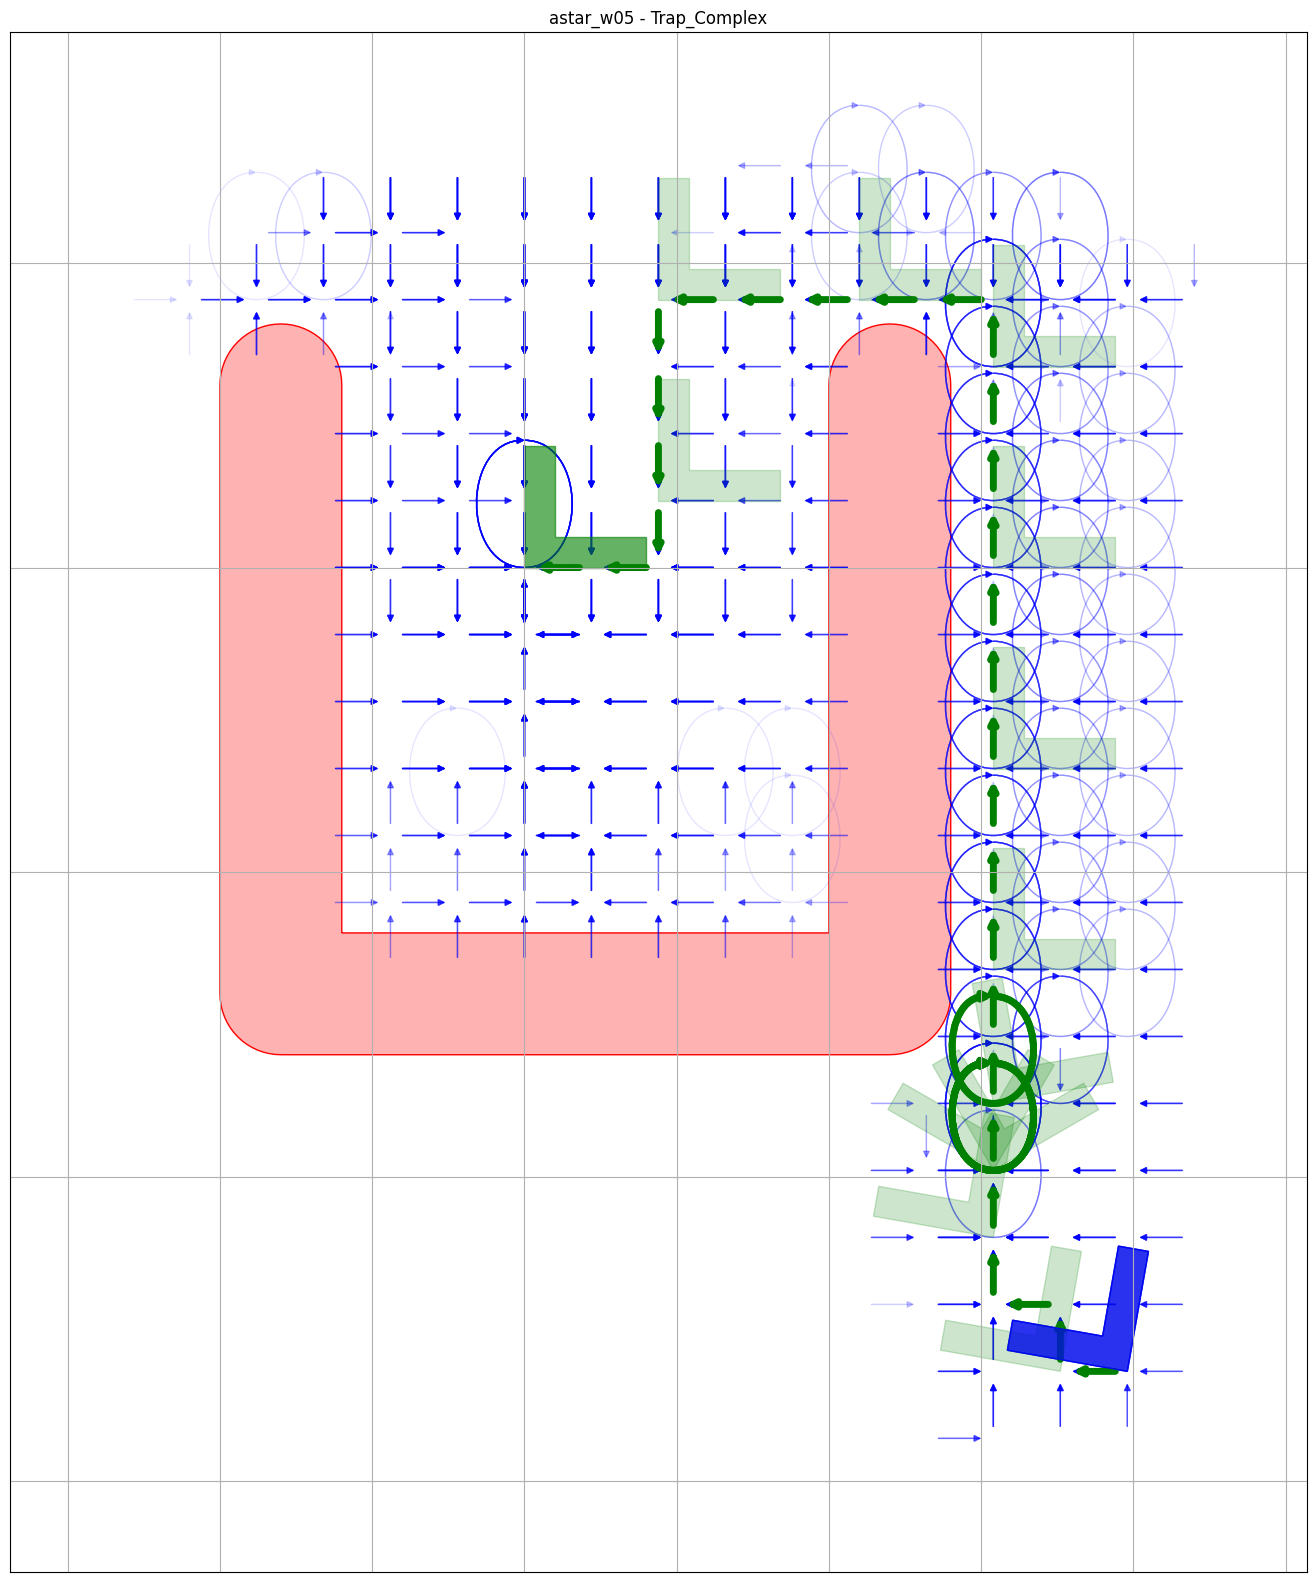

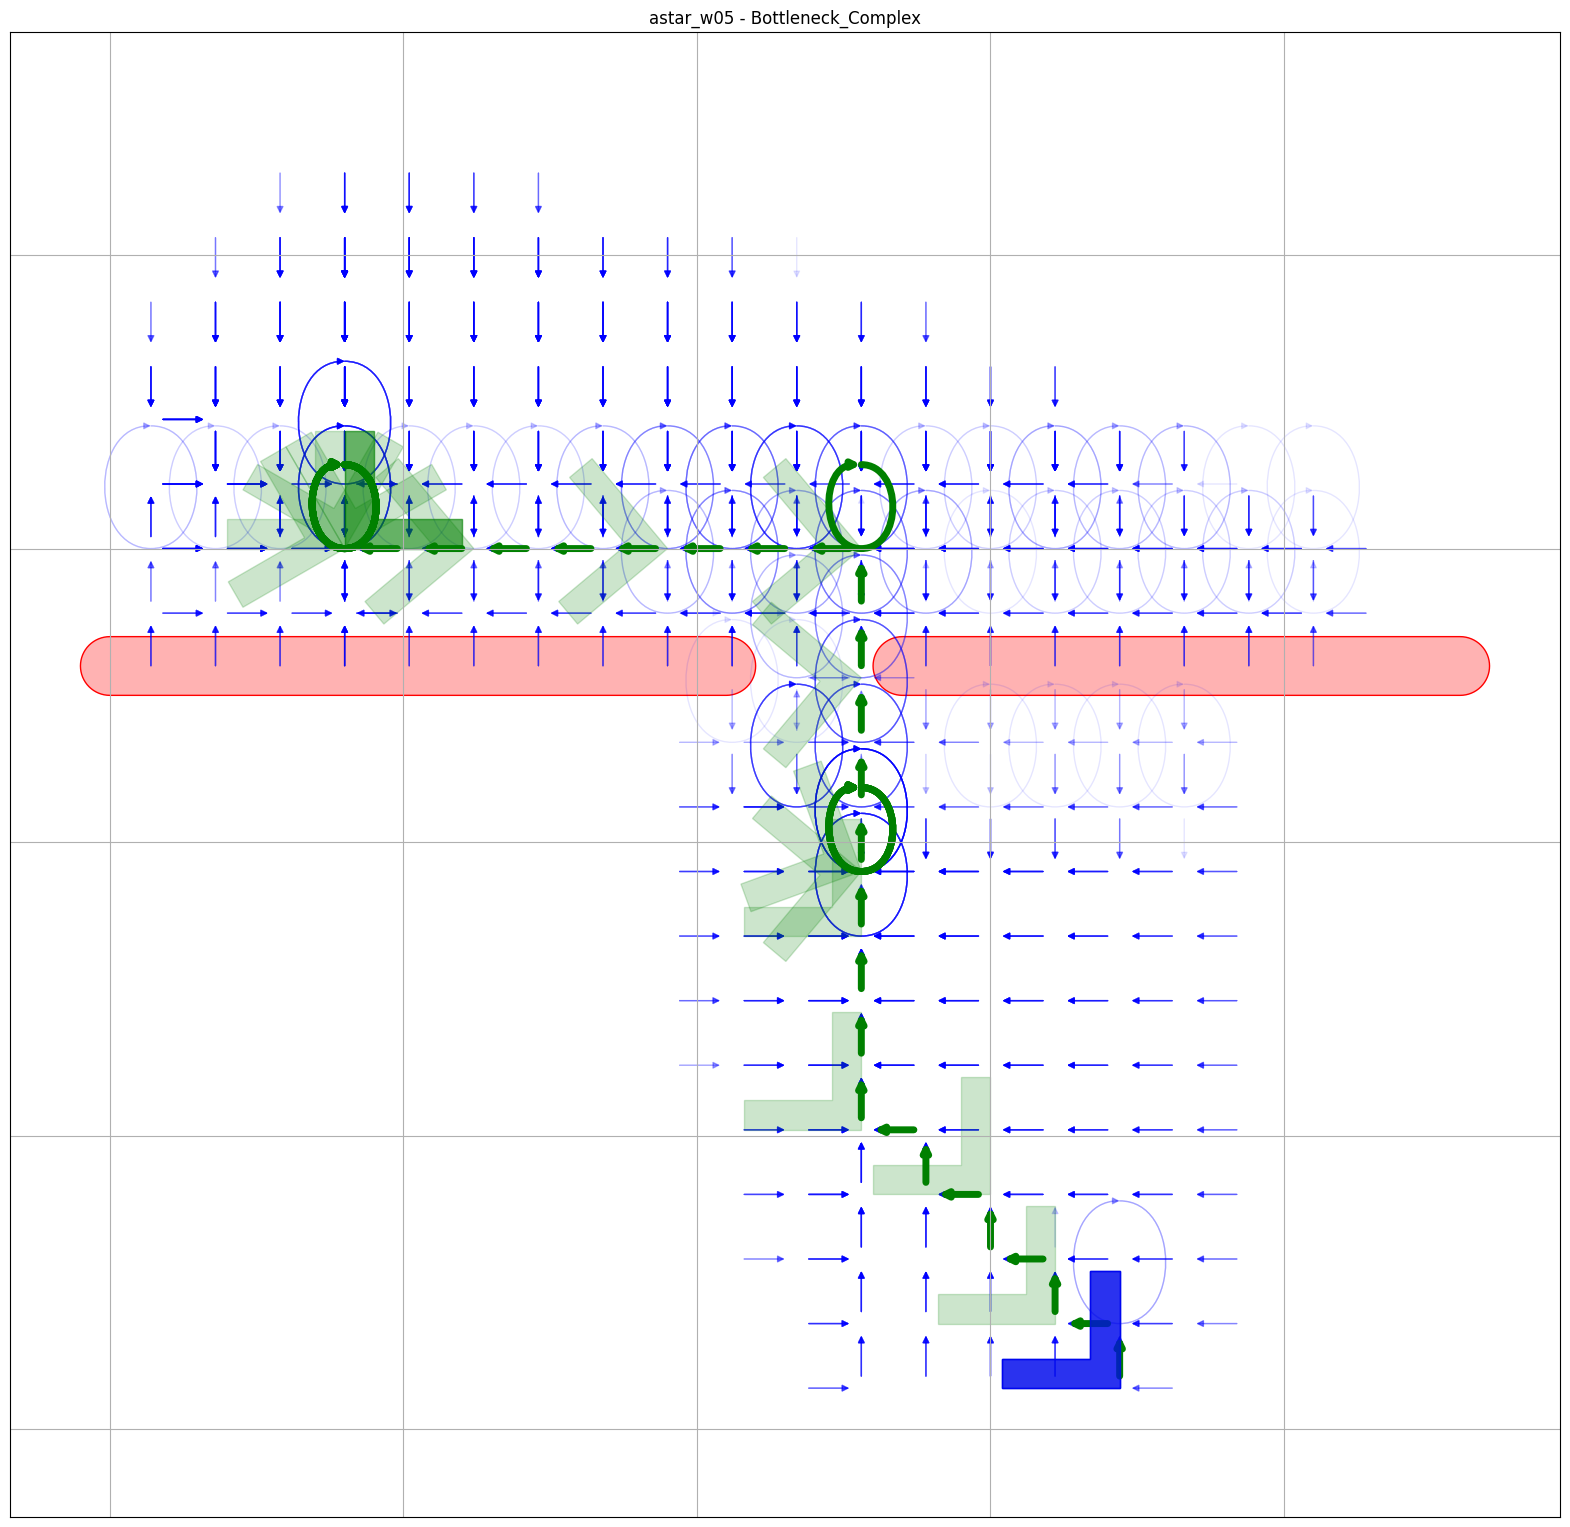

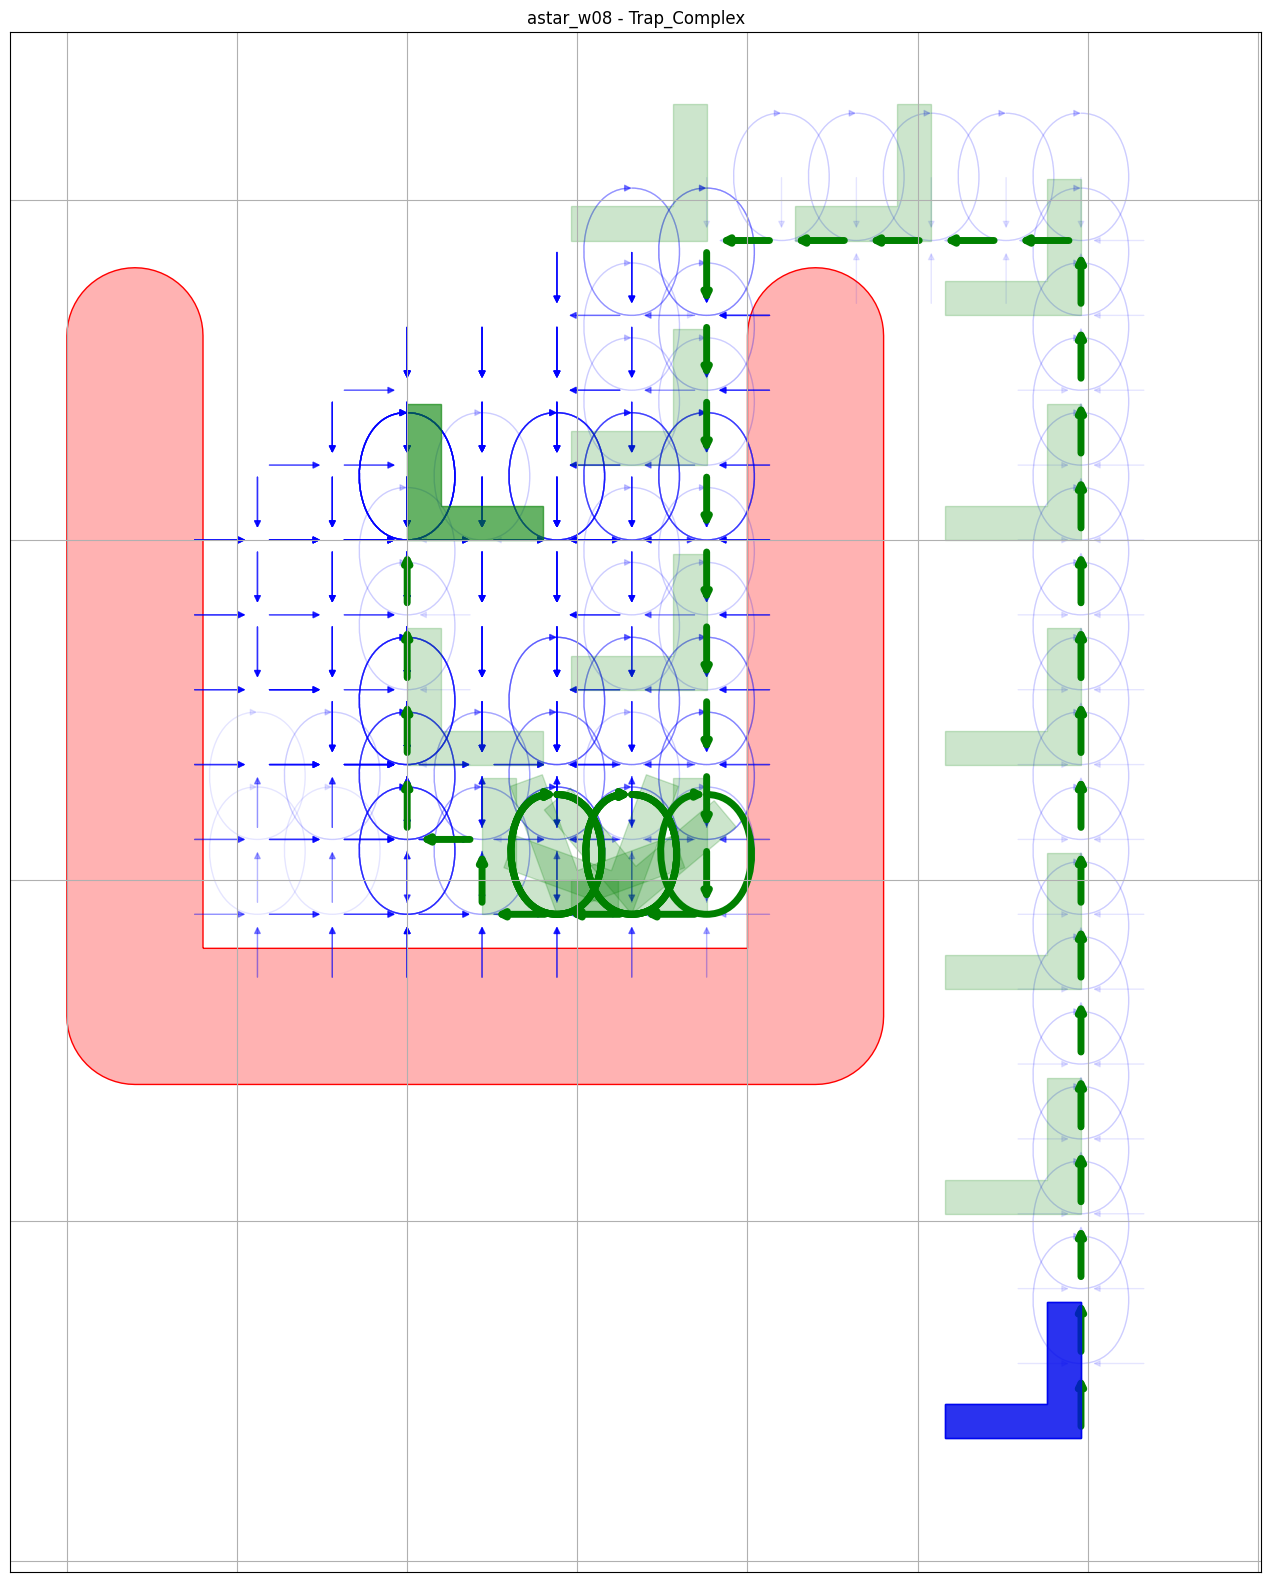

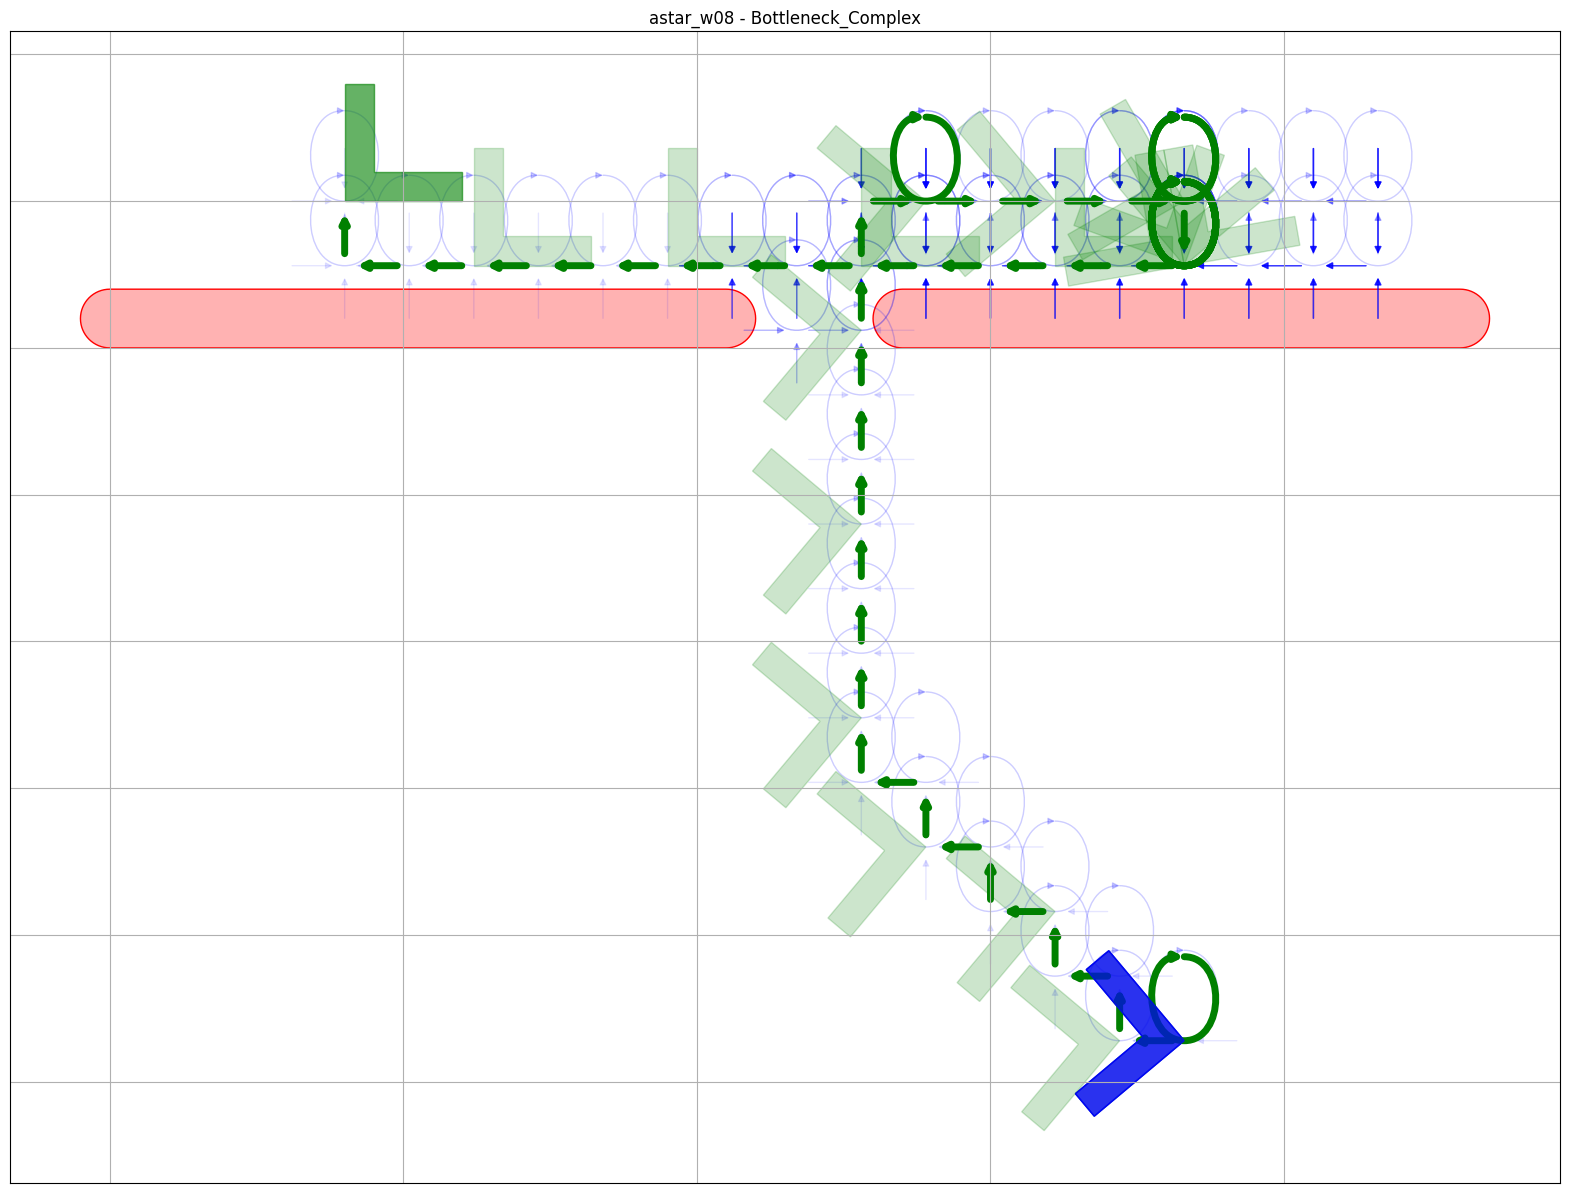

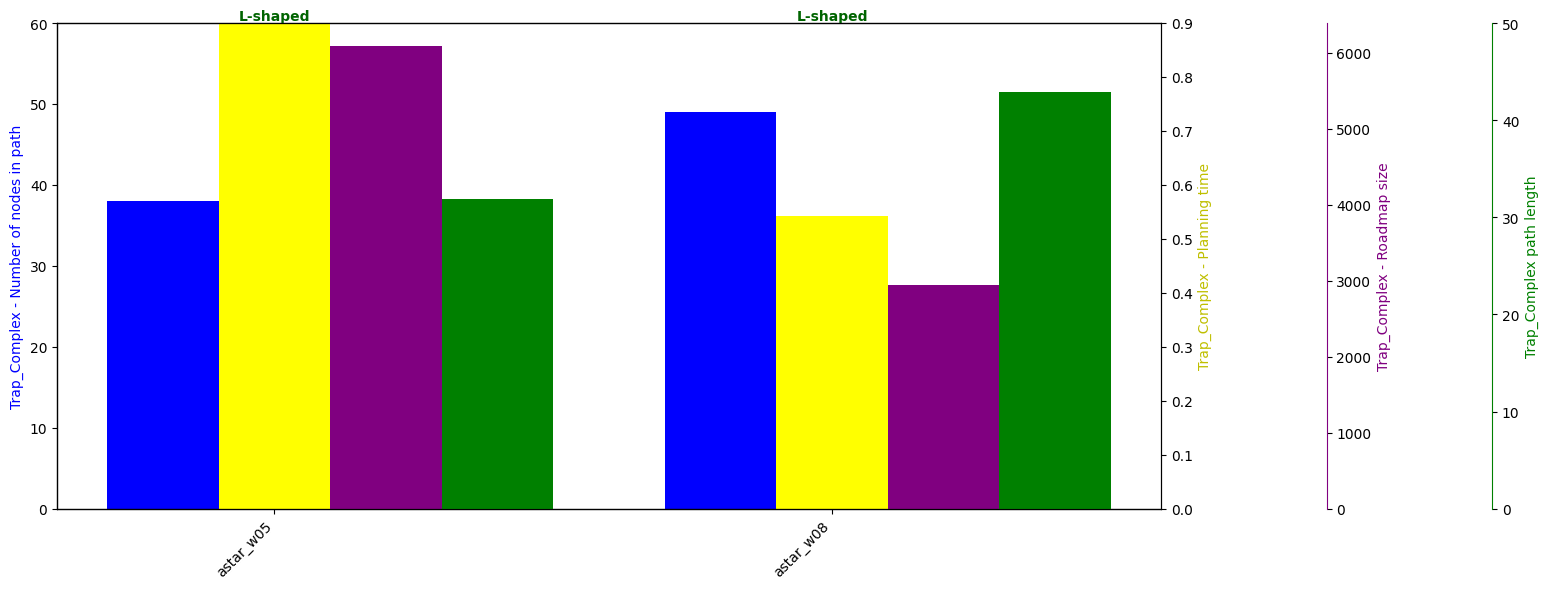

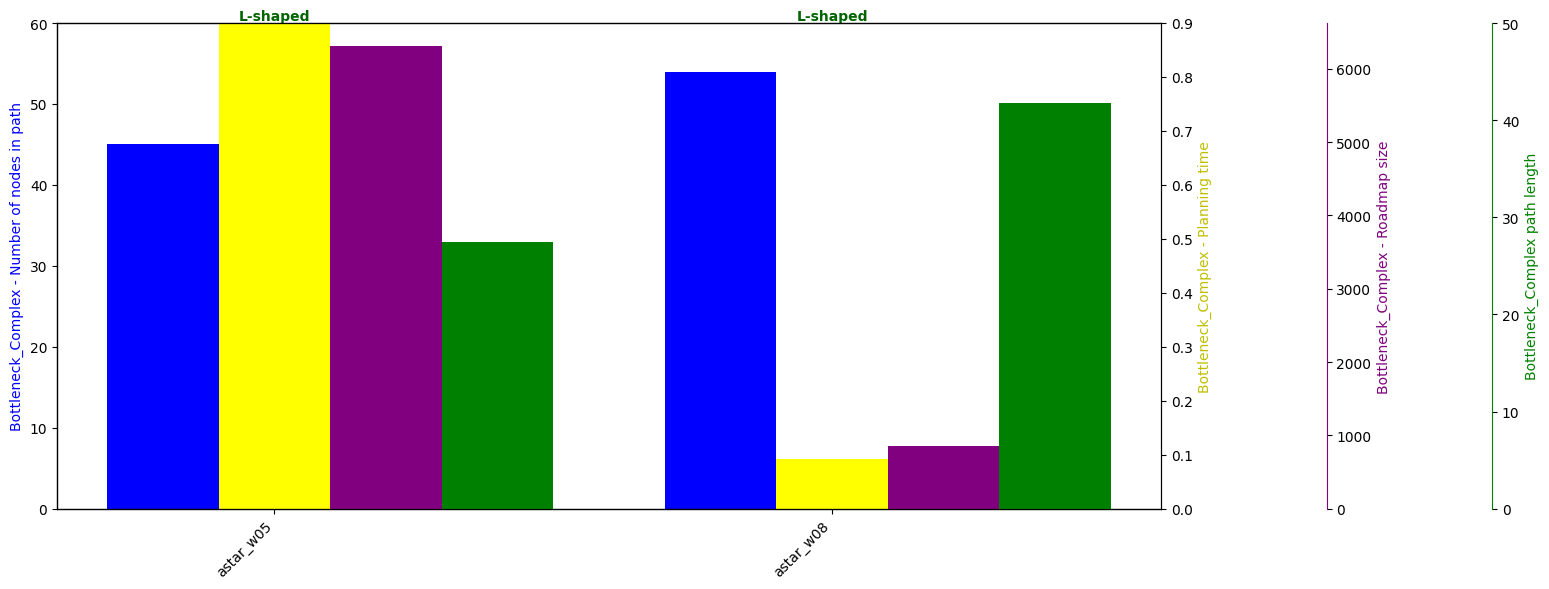

In [5]:
resultList = list()
class ResultCollection (object):
    
    def __init__(self, plannerFactoryName, planner, benchmark, solution, perfDataFrame):
        self.plannerFactoryName = plannerFactoryName
        self.planner = planner
        self.benchmark = benchmark
        self.solution = solution
        self.perfDataFrame = perfDataFrame

import IPTestSuite2 as ts
from shapely.geometry import Point, Polygon, LineString
from shapely import plotting

fullBenchList = ts.benchList

for benchmark in fullBenchList:
    print(benchmark.name)



import matplotlib.animation as animation
from IPython.display import HTML, display
import copy
import numpy as np
import matplotlib.pyplot as plt

# Hilfsfunktion (unverändert, aber wir behandeln den Rückgabewert jetzt besser)
def _interpolate_line(startPos, endPos, step_l):
    steps = []
    line = np.array(endPos) - np.array(startPos)
    line_l = np.linalg.norm(line)
    if line_l == 0:
        return [np.array(startPos)]
    step = line / line_l * step_l
    n_steps = int(np.floor(line_l / step_l))
    c_step = np.array(startPos, dtype=float)
    for i in range(n_steps):
        steps.append(copy.deepcopy(c_step))
        c_step = c_step + step
    if not np.allclose(c_step, np.array(endPos)):
        steps.append(np.array(endPos, dtype=float))
    return steps

def animate_solution_multi_downsampled(prm, environment, solution, visualizer=None, 
                                     workSpaceLimits=None, step_l=0.1, interval=50, 
                                     max_frames=200, figsize=(6,6), dpi=40, 
                                     pause_frames=40):
    
    # 1. Basic Checks
    if not solution or len(solution) < 2:
        raise ValueError('solution must contain at least two nodes')

    # 1. Récupération des positions pour l'interpolation du robot
    path_pos = [prm.graph.nodes[n]['pos'] for n in solution]
    
    # Interpolation (Mouvement fluide du point rouge)
    full_path = [path_pos[0]]
    for i in range(1, len(path_pos)):
        s, e = np.array(path_pos[i-1]), np.array(path_pos[i])
        dist = np.linalg.norm(e - s)
        if dist > 0:
            n_steps = int(np.floor(dist / step_l))
            for j in range(1, n_steps + 1):
                full_path.append(s + (e - s) * (j / (n_steps + 1)))
    full_path.append(path_pos[-1])

    # Downsampling
    if len(full_path) > max_frames:
        indices = np.linspace(0, len(full_path)-1, max_frames).astype(int)
        frames_data = [full_path[i] for i in indices]
    else:
        frames_data = full_path

    # 2. Setup Figure
    fig_local, ax = plt.subplots(figsize=figsize, dpi=dpi)
    limits = environment.getEnvironmentLimits()

    def _animate(current_pos):
        ax.cla() # On efface pour redessiner proprement
        
        # --- VISUALIZER OHNE ROBOTER-SHAPES ---
        # Deaktiviere temporär die drawRobot Methode, damit der Visualizer
        # die Diskretisierung zeichnet, aber nicht die grünen Roboter-Shapes
        original_drawRobot = environment.robot.drawRobot
        environment.robot.drawRobot = lambda ax, **kwargs: None  # Dummy-Funktion
        
        visualizer(prm, solution, ax=ax, nodeSize=100)
        
        # Stelle die ursprüngliche drawRobot Methode wieder her
        environment.robot.drawRobot = original_drawRobot
        
        # On redessine les obstacles par sécurité
        environment.drawObstacles(ax)
        
        # On remet les limites (parce que visualizer peut les changer)
        ax.set_xlim(limits[0])
        ax.set_ylim(limits[1])
        ax.set_title("A* Visualization & Animation")

        # --- MARKIERUNG VON START UND ZIEL ---
        # Startpunkt: Grüner Punkt mit 'S'
        start_pos = path_pos[0]
        ax.plot(start_pos[0], start_pos[1], 'o', color='#00dd00', 
                markersize=15, markeredgecolor='black', zorder=11)
        ax.text(start_pos[0], start_pos[1], 'S', ha='center', va='center',
                fontsize=12, fontweight='bold', color='black', zorder=12)
        
        # Zielpunkt: Roter Punkt mit 'G'
        goal_pos = path_pos[-1]
        ax.plot(goal_pos[0], goal_pos[1], 'o', color='#DD0000', 
                markersize=15, markeredgecolor='black', zorder=11)
        ax.text(goal_pos[0], goal_pos[1], 'G', ha='center', va='center',
                fontsize=12, fontweight='bold', color='white', zorder=12)

        # --- NUR DER ANIMIERTE ROTE ROBOTER ---
        environment.robot.setTo(current_pos)
        environment.robot.drawRobot(ax, color='red', alpha=0.9)

    print(f"Rendu de l'animation (Diskretisierung + nur roter Roboter)...")
    ani = animation.FuncAnimation(fig_local, _animate, frames=frames_data, interval=interval)
    
    html = HTML(ani.to_jshtml())
    display(html)
    plt.close()
    return ani

import networkx as nx

def lazyPRMVisualizeWorkspace(planner, solution = [] , ax=None, nodeSize = 300):
    """
    Angepasster Visualizer für LazyPRM im Workspace (nur x,y aus 3D-Konfigurationsraum)
    """
    graph = planner.graph.copy()
    collChecker = planner._collisionChecker
    collEdges = planner.collidingEdges
    nonCollEdges = planner.nonCollidingEdges
    
    # Extrahiere nur x,y aus (x, y, theta) Positionen
    pos_3d = nx.get_node_attributes(graph,'pos')
    pos = {node: (coords[0], coords[1]) for node, coords in pos_3d.items()}
    
    color = nx.get_node_attributes(graph,'color')

    collChecker.drawObstacles(ax)
    
    # draw graph
    nx.draw_networkx_nodes(graph, pos, ax = ax, nodelist=list(color.keys()), 
                          node_color=list(color.values()), node_size=nodeSize)
    nx.draw_networkx_edges(graph, pos, ax = ax)
    
    # draw all connected components, emphasize the largest one
    Gcc=(graph.subgraph(c) for c in nx.connected_components(graph))
    G0=next(Gcc)
    
    nx.draw_networkx_edges(G0, pos,
                          edge_color='b',
                          width=3.0, style='dashed',
                          alpha=0.5)
    
    if collEdges != []:
        collGraph = nx.Graph()
        collGraph.add_nodes_from(graph.nodes(data=True))
        for i in collEdges:
            collGraph.add_edge(i[0],i[1])
        nx.draw_networkx_edges(collGraph, pos, alpha=0.2, edge_color='r', width=5)
    
    if nonCollEdges != []:
        nonCollGraph = nx.Graph()
        nonCollGraph.add_nodes_from(graph.nodes(data=True))
        for i in nonCollEdges:
            nonCollGraph.add_edge(i[0],i[1])
        nx.draw_networkx_edges(nonCollGraph, pos, alpha=0.8, edge_color='yellow', width=5)
    
    # draw start and goal
    if "start" in graph.nodes(): 
        nx.draw_networkx_nodes(graph, pos, nodelist=["start"],
                              node_size=300,
                              node_color='#00dd00', ax = ax)
        nx.draw_networkx_labels(graph, pos, labels={"start": "S"}, ax = ax)

    if "goal" in graph.nodes():
        nx.draw_networkx_nodes(graph, pos, nodelist=["goal"],
                              node_size=300,
                              node_color='#DD0000', ax = ax)
        nx.draw_networkx_labels(graph, pos, labels={"goal": "G"}, ax = ax)

    if solution != []:
        Gsp = nx.subgraph(graph, solution)
        nx.draw_networkx_edges(Gsp, pos, alpha=0.8, edge_color='g', width=10)
    
    return


# for benchmark in fullBenchList:
#     fig_local = plt.figure(figsize=(7,7))
#     ax = fig_local.add_subplot(1,1,1)
#     title = benchmark.name
#     ax.set_title(title)
#     ax.set_xlim(benchmark.collisionChecker.getEnvironmentLimits()[0])
#     ax.set_ylim(benchmark.collisionChecker.getEnvironmentLimits()[1])
#     plotting.plot_points(Point(benchmark.startList[0]).buffer(.3), color="g", ax=ax)
#     plotting.plot_points(Point(benchmark.goalList[0]).buffer(.3), color="b", ax=ax)
#     #try:
#     benchmark.collisionChecker.drawObstacles(ax)
  
        
#     #except Exception as e:
#     #    print ("Error", e)
#     #    pass
#     plt.show()


resultList = list()
testList = fullBenchList

for key,producer in list(plannerFactory.items()):
    print(key, producer)
    for benchmark in testList:
        print ("Planning: " + key + " - " + benchmark.name)
        #planner = IPBasicPRM.BasicPRM(benchmark.collisionChecker)
        planner = producer[0](benchmark.collisionChecker)
        IPPerfMonitor.clearData()
        try:
            
            resultList.append(ResultCollection(key,
                                          planner, 
                                           benchmark, 
                                           planner.planPath(benchmark.startList,benchmark.goalList,producer[1]),
                                           IPPerfMonitor.dataFrame()
                                          ),
                        )
        except Exception as e:
        #    throw e
            print ("PLANNING ERROR ! PLANNING ERROR ! PLANNING ERROR ", e)
            pass

import matplotlib.pyplot as plt

for result in resultList:
    
    fig_local = plt.figure(figsize=(20,20))
    ax = fig_local.add_subplot(1,1,1)
    title = result.plannerFactoryName + " - " + result.benchmark.name
    if result.solution == []:
        title += " (No path found!)"
    #title += "\n Assumed complexity level " + str(result.benchmark.level)
    ax.set_title(title)
    try:
        # Temporär erweiter Ludwig Setze den Roboter an die Endposition, falls eine Lösung existiert
        if result.solution and len(result.solution) > 0:
            goal_node = result.solution[-1]
            if hasattr(result.planner, 'graph') and goal_node in result.planner.graph.nodes:
                goal_pos = result.planner.graph.nodes[goal_node]['pos']
                result.benchmark.collisionChecker.robot.setTo(goal_pos)
        
        #IPVISBasicsPRM.basicPRMVisualize(result.planner, result.solution, ax=ax, nodeSize=100))
        plannerFactory[result.plannerFactoryName][2](result.planner, result.solution, ax=ax, nodeSize=100)
        
        # Zeichne Roboter am Startpunkt (grün) und Endpunkt (blau)
        if result.solution and len(result.solution) > 0:
            if hasattr(result.planner, 'graph'):
                # Startroboter in grün
                start_node = result.solution[0]
                if start_node in result.planner.graph.nodes:
                    start_pos = result.planner.graph.nodes[start_node]['pos']
                    result.benchmark.collisionChecker.robot.setTo(start_pos)
                    result.benchmark.collisionChecker.robot.drawRobot(ax, color='green', alpha=0.5)
                
                # Endroboter in blau
                goal_node = result.solution[-1]
                if goal_node in result.planner.graph.nodes:
                    goal_pos = result.planner.graph.nodes[goal_node]['pos']
                    result.benchmark.collisionChecker.robot.setTo(goal_pos)
                    result.benchmark.collisionChecker.robot.drawRobot(ax, color='blue', alpha=0.7)
        
    except Exception as e:
        print ("Error", e)
        pass
    
    plt.show()

# for bench in testList:
#     for result in resultList:
#         if result.benchmark.name == bench.name:
#             # Prüfe ob Lösung existiert UND mindestens 2 Knoten hat
#             if result.solution is not None and len(result.solution) >= 2:
#                 print(f"Animation für: {result.plannerFactoryName} - {bench.name}")
#                 print(f"  Anzahl Knoten im Pfad: {len(result.solution)}")
#                 try:
#                     animate_solution_multi_downsampled(
#                         result.planner, bench.collisionChecker, result.solution,
#                         visualizer=plannerFactory[result.plannerFactoryName][2],
#                         step_l=0.05, interval=60, max_frames=200, figsize=(20,20), dpi=40)
#                 except Exception as e:
#                     print(f"  FEHLER bei Animation: {e}")
#             else:
#                 if result.solution is None:
#                     print(f"Keine Animation für {result.plannerFactoryName} - {bench.name}: Keine Lösung gefunden")
#                 else:
#                     print(f"Keine Animation für {result.plannerFactoryName} - {bench.name}: Zu wenige Knoten ({len(result.solution)})")

def compute_path_lengths_multi(graph, solution, theta_in_radians=True):
    """
    Berechnet die Gesamtpfadläng pro Roboter in einem Graphen mit mehreren Robotern

    Das Knotenattribut 'pos' ist eine sequenz [x1,y1,theta1, x2,y2,theta2,...]
    Für unsere zwei Roboter sind es 6 Einträge pro Knoten.
    Die Funktion summiert die euklidischen Distanzen zwischen jedem Knotenpaar (Kanten) in der xy-Ebene für jeden Roboter auf.
    """
    import numpy as np
    import networkx as nx

    # Falls keine Lösung oder nur ein Knoten vorhanden ist, sofort Nullwerte zurückgeben
    if not solution or len(solution) < 2:
        return {
            'green': {'total': 0.0},
            'red': {'total': 0.0},
            'segments': 0
        }

    # Hole alle 'pos' Attribute aus dem Graph (dict: node -> config)
    pos_attr = nx.get_node_attributes(graph, 'pos')
    total_g = 0.0  # aufsummierte Distanz für grünen Roboter (Roboter 1)
    total_r = 0.0  # aufsummierte Distanz für roten Roboter (Roboter 2)
    segments = 0   # Anzahl der Segmente (Anzahl Kanten im Pfad)

    # Iteriere über alle aufeinanderfolgenden Knotenpaare der Lösung
    for i in range(len(solution) - 1):
        a = solution[i]; b = solution[i + 1]
        # Fehler, falls ein Knoten kein 'pos' Attribut hat (schützt vor inkonsistenten Graphen)
        if a not in pos_attr or b not in pos_attr:
            raise ValueError(f"Node {a} or {b} missing 'pos' attribute in graph")
        pa = np.array(pos_attr[a], dtype=float)  # Konfiguration an Knoten a
        pb = np.array(pos_attr[b], dtype=float)  # Konfiguration an Knoten b

        # Berechne Euklidische Distanz in der xy‑Ebene für Roboter 1 (grün)
        # pa[0:2] und pb[0:2] sind [x1,y1] für Roboter 1
        total_g += float(np.linalg.norm(pb[0:2] - pa[0:2]))

        # Berechne Euklidische Distanz in der xy‑Ebene für Roboter 2 (rot)
        # pa[3:5] und pb[3:5] sind [x2,y2] für Roboter 2
        total_r += float(np.linalg.norm(pb[3:5] - pa[3:5]))

        segments += 1  # ein weiteres Kanten-Segment wurde betrachtet

    # Rückgabe: pro Roboter nur die 'total' Länge (Rotationen werden hier bewusst nicht berücksichtigt)
    return {
        'green': {'total': total_g},
        'red': {'total': total_r},
        'segments': segments
    }


def get_robot_shape_description(benchmark):
    """Ermittelt eine Beschreibung der Roboterform basierend auf der Geometrie."""
    try:
        robot = benchmark.collisionChecker.robot
        if hasattr(robot, '_template'):
            # ShapeRobotWithOrientation - verwende Template Geometrie
            coords = list(robot._template.exterior.coords)
        elif hasattr(robot, 'geometry'):
            # ShapeRobot - verwende direkte Geometrie
            coords = list(robot.geometry.exterior.coords)
        else:
            return "Unknown"
        
        # Analysiere die Form basierend auf Eckpunkten
        num_vertices = len(coords) - 1  # Letzter Punkt = erster Punkt
        
        # Prüfe ob es ein Rechteck ist (4 Eckpunkte)
        if num_vertices == 4:
            # Prüfe Dimensionen
            xs = [c[0] for c in coords]
            ys = [c[1] for c in coords]
            width = max(xs) - min(xs)
            height = max(ys) - min(ys)
            
            if abs(width - 2.5) < 0.1 and abs(height - 1.0) < 0.1:
                return "Rectangle (2.5x1.0)"
            else:
                return f"Rectangle ({width:.1f}x{height:.1f})"
        
        # Prüfe ob es ein L-förmiger Roboter ist (6 Eckpunkte)
        elif num_vertices == 6:
            return "L-shaped"
        
        else:
            return f"Custom ({num_vertices} vertices)"
    except:
        return "Unknown"

import numpy as np
for bench in testList:
    title = bench.name
    
    # Roboter-Form zur Beschreibung hinzufügen
    robot_shape = get_robot_shape_description(bench)
    
    pathLength = dict()
    planningTime = dict()
    roadmapSize  = dict()
    res=dict()

    try:
        for result in resultList:
            if result.benchmark.name == bench.name:
                #print result.benchmark.name  + " - " +  result.plannerFactoryName, len(result.solution)
                pathLength[result.plannerFactoryName] = len(result.solution)
                planningTime[result.plannerFactoryName] = result.perfDataFrame.groupby(["name"]).sum(numeric_only=True)["time"]["planPath"]
                roadmapSize[result.plannerFactoryName] = result.planner.graph.size()
                res[result.plannerFactoryName] = compute_path_lengths_multi(result.planner.graph, result.solution, theta_in_radians=True)

        fig, ax = plt.subplots(figsize=(16, 6))  # Breitere Figur

        width = 0.2

        ax.bar(np.arange(len(pathLength.keys())), pathLength.values(),width, color="blue")
        ax.set_ylabel(title + " - Number of nodes in path", color="blue")
        ax.set_ylim(0,60)
        ax.set_xticks(np.arange(len(pathLength.keys())) + width)
        ax.set_xticklabels(pathLength.keys(), rotation=45, ha='right')  # Rotierte Labels

        ax2 = ax.twinx()
        bar = ax2.bar(np.arange(len(pathLength.keys()))+width, planningTime.values(),width, color="red")
        ax2.set_ylabel(title + " - Planning time", color="y")
        ax2.set_ylim(0,0.9)

        # Add coloring and patterns on axis two
        hatches = ['x' if length==0 else '' for length in pathLength.values()]
        color   = ['red' if length==0 else 'yellow' for length in pathLength.values()]
        for i,thisbar in enumerate(bar.patches):
            thisbar.set_facecolor(color[i])
            thisbar.set_hatch(hatches[i])

        # Multiple axes 
        ax3 = ax.twinx()
        ax3.bar(np.arange(len(pathLength.keys()))+2*width, roadmapSize.values(),width, color="purple")
        ax3.set_ylabel(title + " - Roadmap size",  color="purple")
        ax3.spines['right'].set_position(('axes', 1.15))
        ax3.spines['right'].set_color("purple")

        ax4 = ax.twinx()
        ax4.bar(np.arange(len(pathLength.keys()))+3*width, [res[planner].get('green', {}).get('total', 0) for planner in pathLength.keys()], width, color="green")
        ax4.set_ylabel(title + " path length", color="green")
        ax4.spines['right'].set_position(('axes', 1.3))
        ax4.spines['right'].set_color("green")
        ax4.set_ylim(0,50)
        
        # Roboterform über den Balken anzeigen
        # Berechne die maximale Höhe für die Positionierung
        max_y = max(list(roadmapSize.values()) + [0]) if roadmapSize else 0
        
        # Text mittig über allen Balkengruppen platzieren
        for i in range(len(pathLength.keys())):
            ax3.text(i + width, max_y * 1.05, f"{robot_shape}", 
                    ha='center', va='bottom', fontsize=10, fontweight='bold',
                    rotation=0, color='darkgreen')
        
        plt.tight_layout()  # Besseres Layout, verhindert abgeschnittene Labels
    except:
        pass

    plt.show()
    



## Vergleich mit und ohne Kantenkollision (L-shape)

In [6]:
plannerFactory = dict()
# ========================================
# A* Variante 3: Mit Edge Collision Check
# ========================================
astarConfig3 = dict()
astarConfig3["heuristic"] = 'euclidean' 
astarConfig3["w"] = 0.5
astarConfig3["num_steps"] = [20, 20, 36]
astarConfig3["checkEdgeCollision"] = True  # MIT Kantenkollisionsprüfung
plannerFactory["with_edgeCheck"] = [IPAStar.AStar, astarConfig3, IPVISAStar.aStarVisualizeWspace]

# # ========================================
# # A* Variante 4: Ohne Edge Collision Check
# # ========================================
astarConfig4 = dict()
astarConfig4["heuristic"] = 'euclidean' 
astarConfig4["w"] = 0.5
astarConfig4["num_steps"] = [20, 20, 36]
astarConfig4["checkEdgeCollision"] = False  # OHNE Kantenkollisionsprüfung
plannerFactory["no_edgeCheck"] = [IPAStar.AStar, astarConfig4, IPVISAStar.aStarVisualizeWspace]

Trap_Complex
Bottleneck_Complex
with_edgeCheck [<class 'IPAStar.AStar'>, {'heuristic': 'euclidean', 'w': 0.5, 'num_steps': [20, 20, 36], 'checkEdgeCollision': True}, <function aStarVisualizeWspace at 0x000001D3EC335C60>]
Planning: with_edgeCheck - Trap_Complex
Planning: with_edgeCheck - Bottleneck_Complex
no_edgeCheck [<class 'IPAStar.AStar'>, {'heuristic': 'euclidean', 'w': 0.5, 'num_steps': [20, 20, 36], 'checkEdgeCollision': False}, <function aStarVisualizeWspace at 0x000001D3EC335C60>]
Planning: no_edgeCheck - Trap_Complex
Planning: no_edgeCheck - Bottleneck_Complex


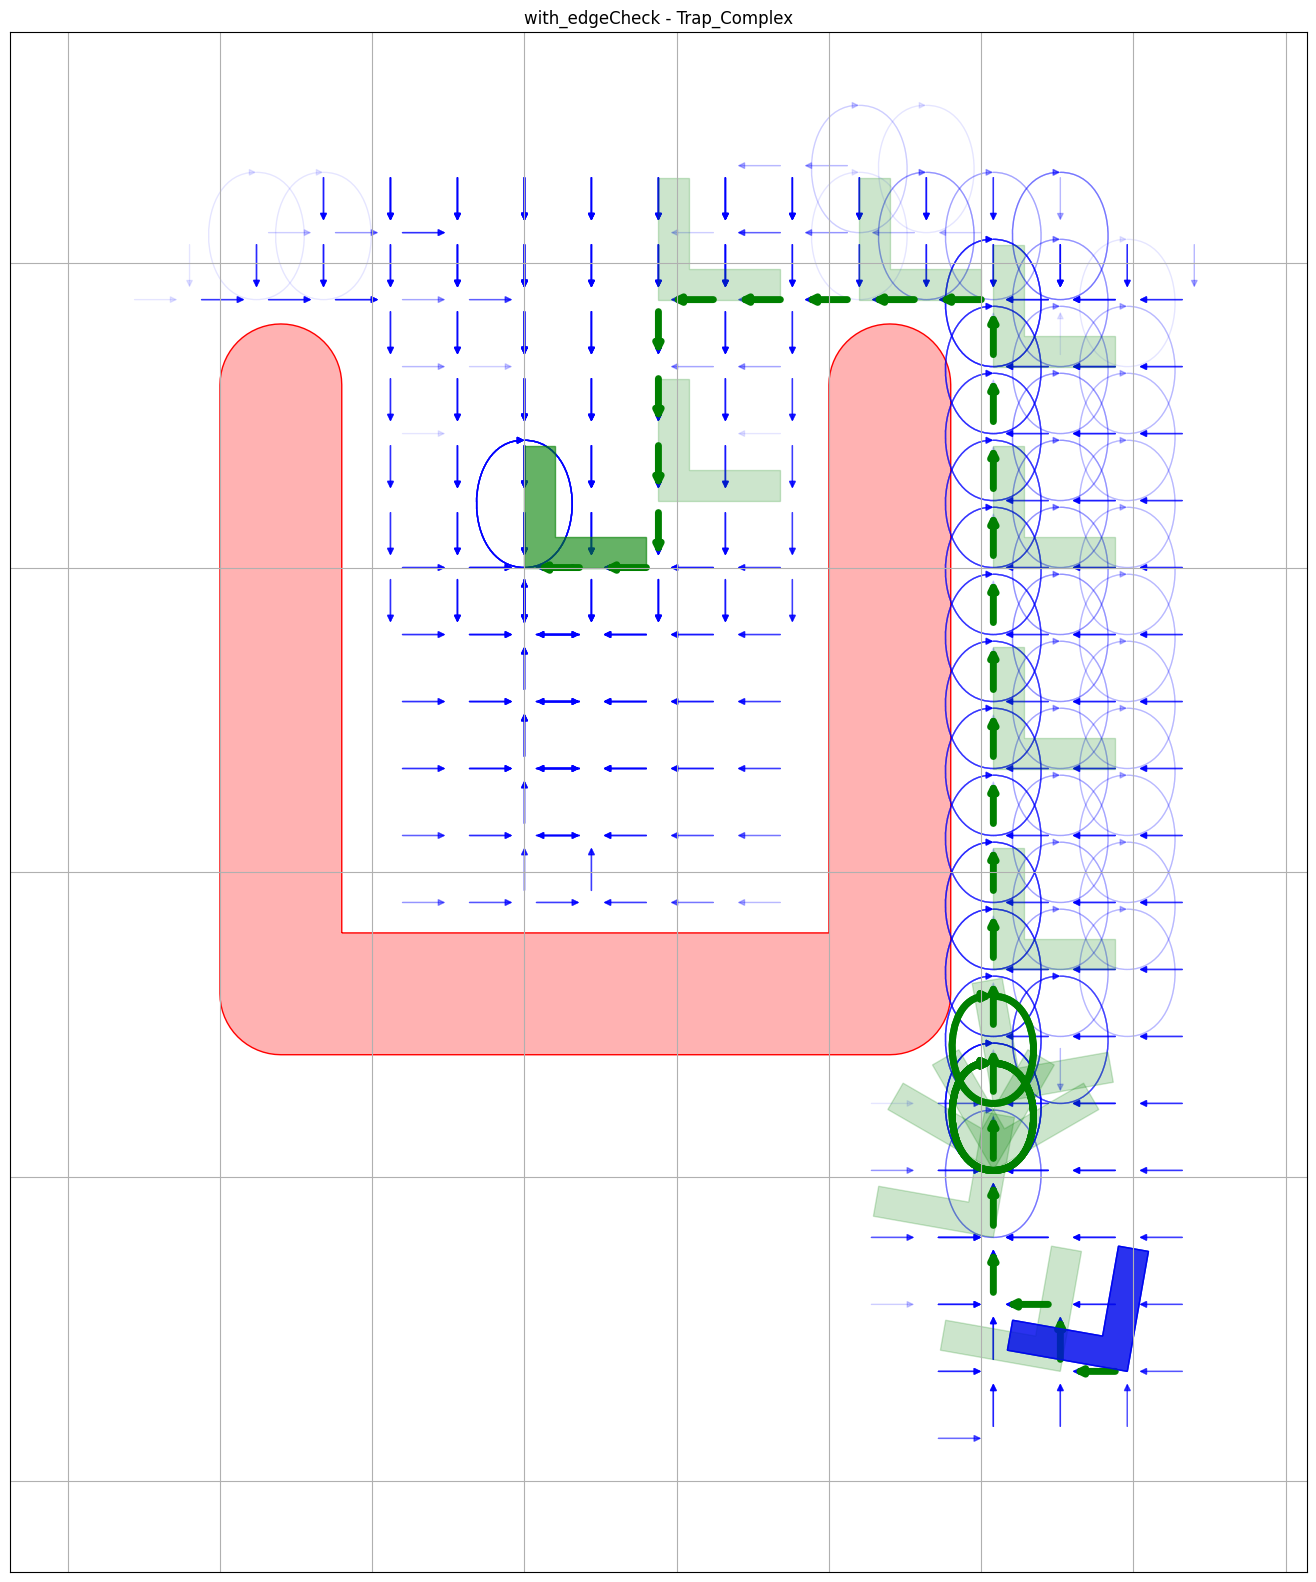

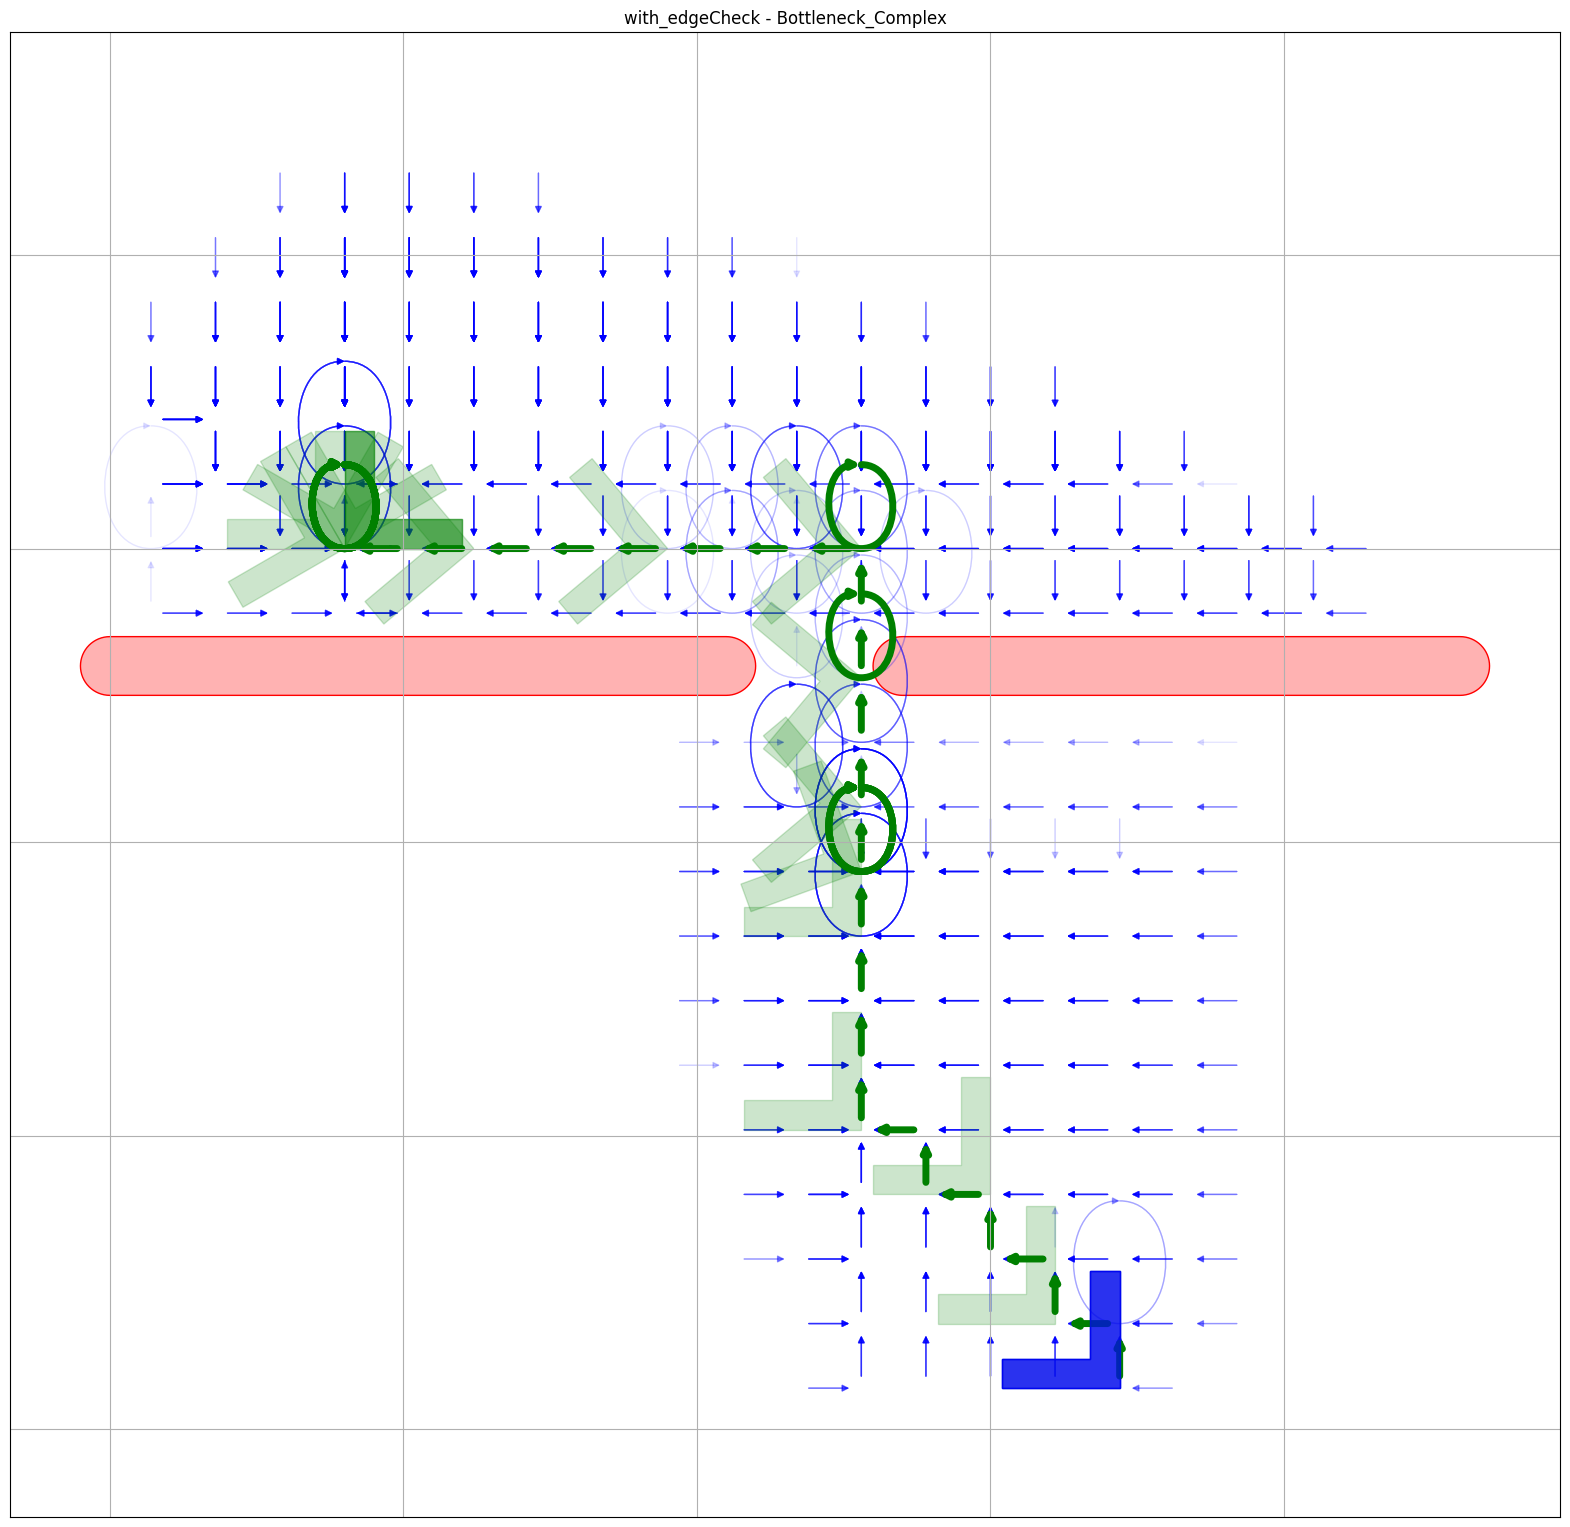

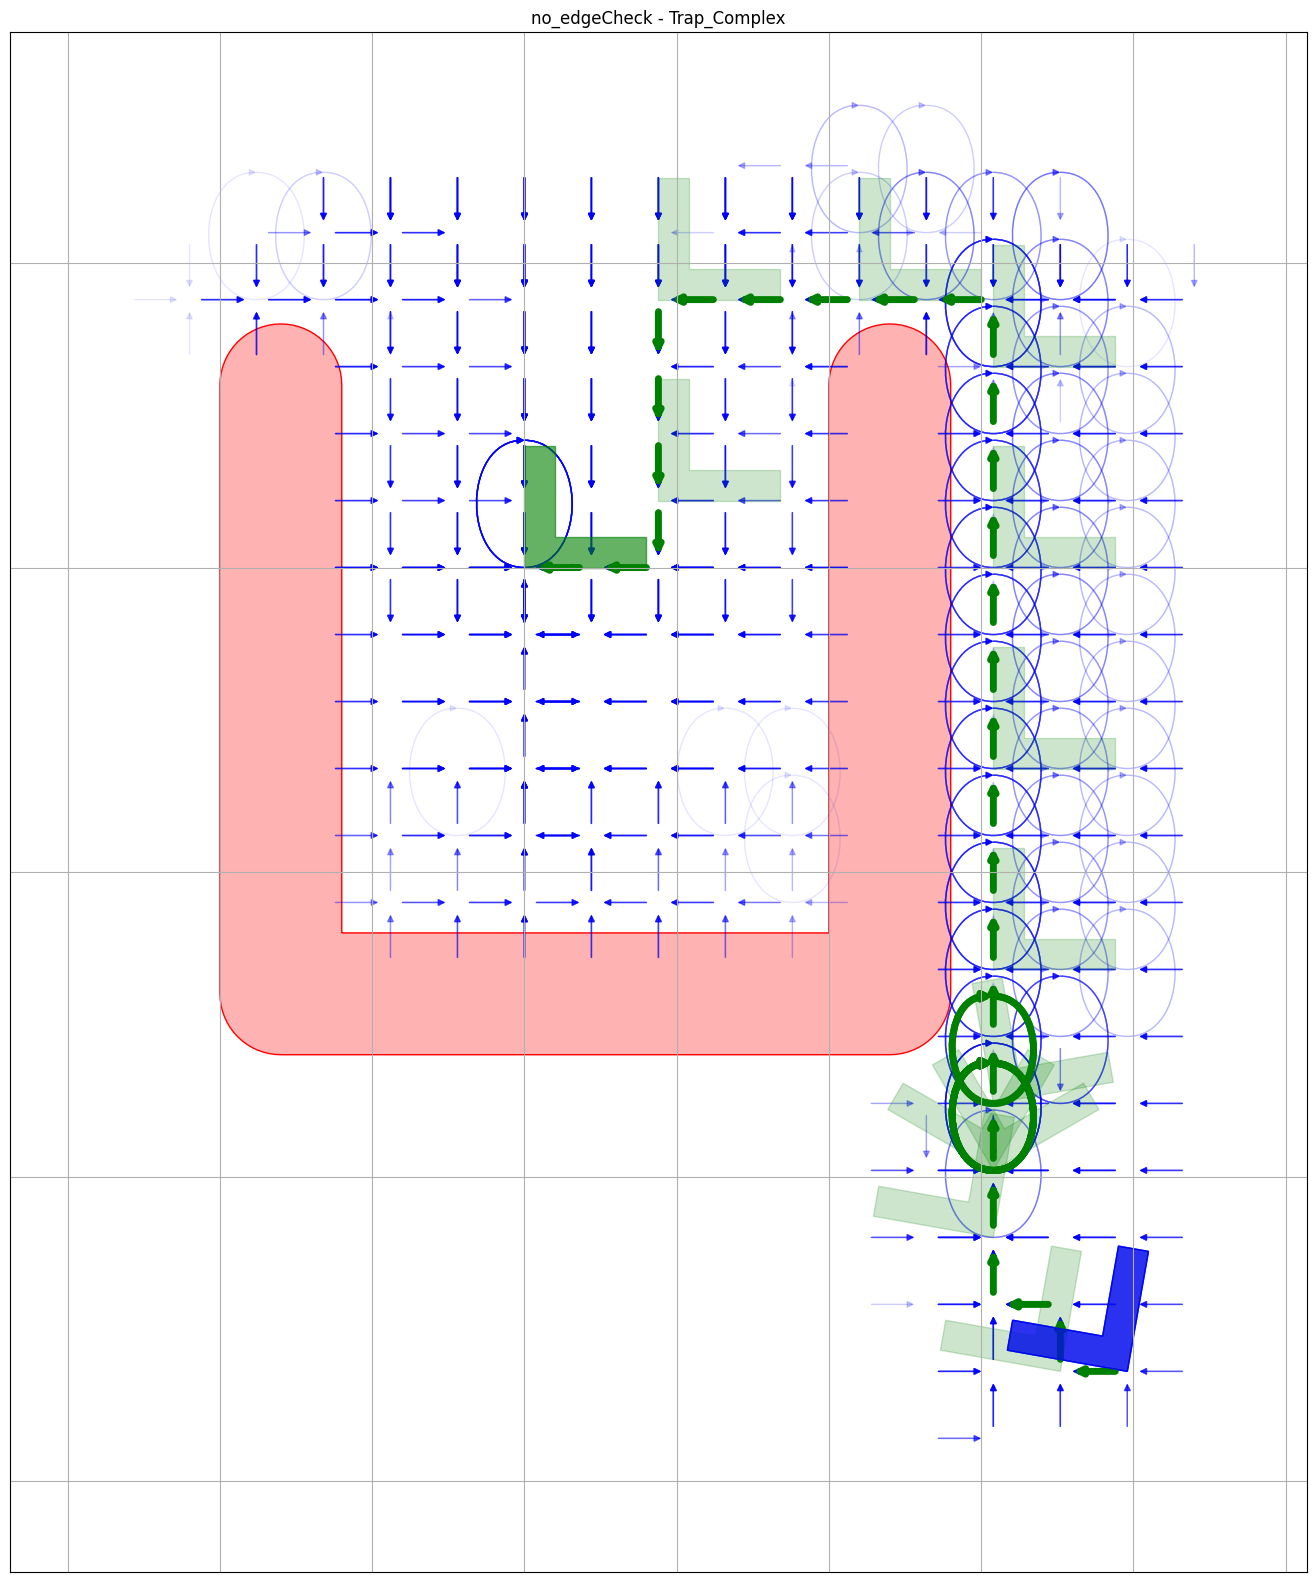

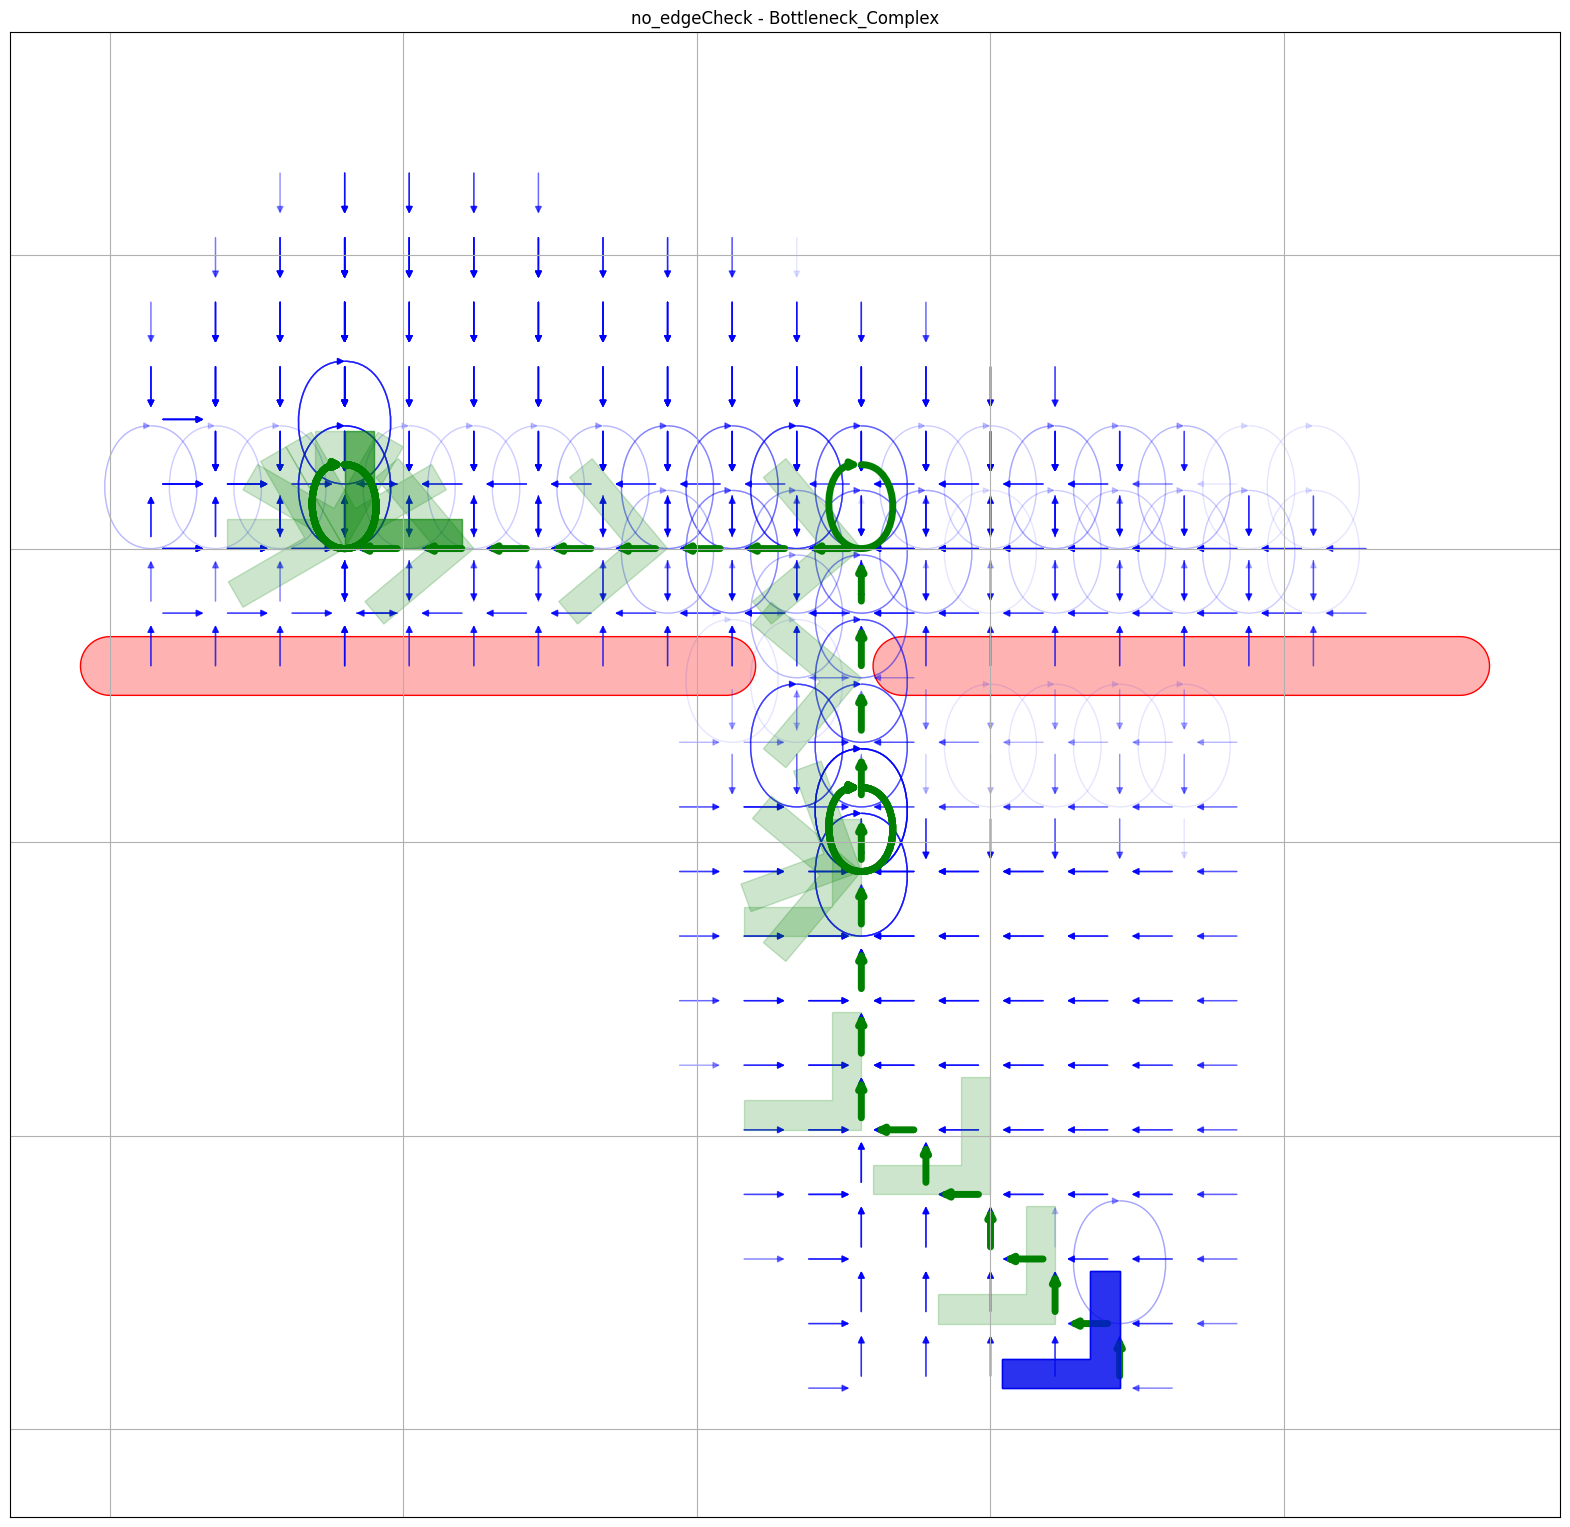

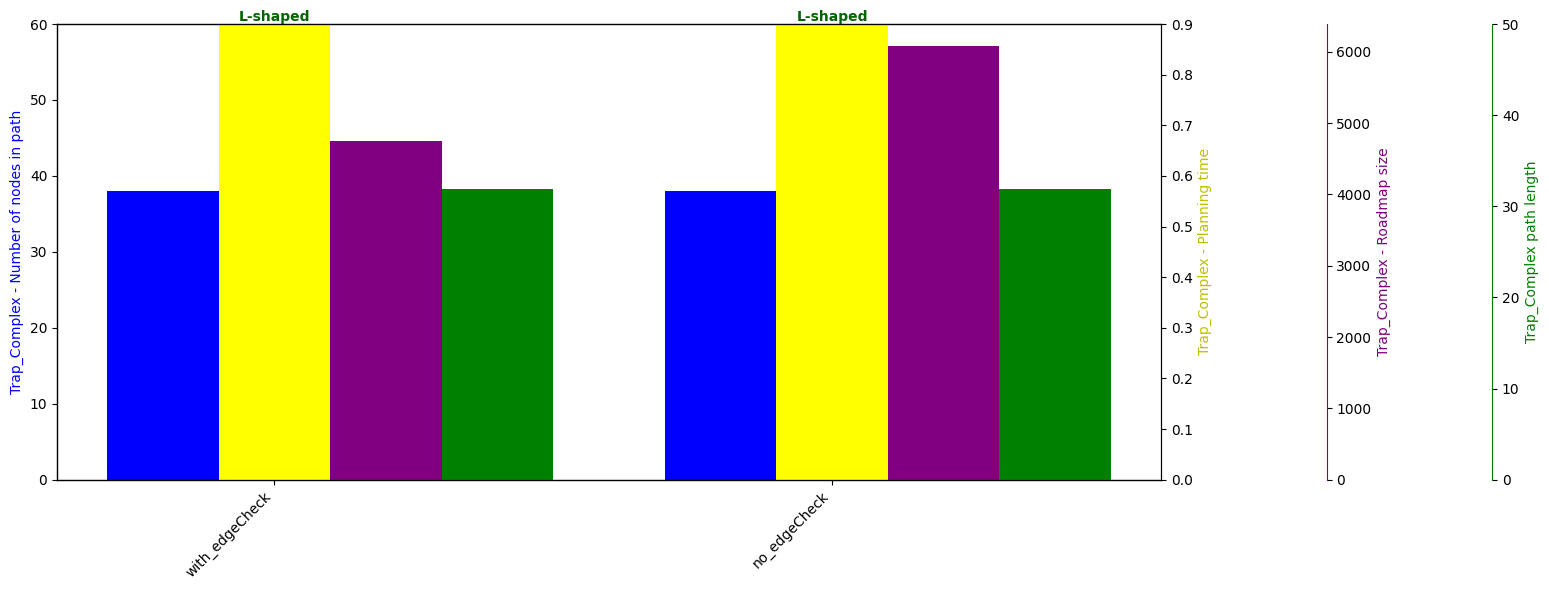

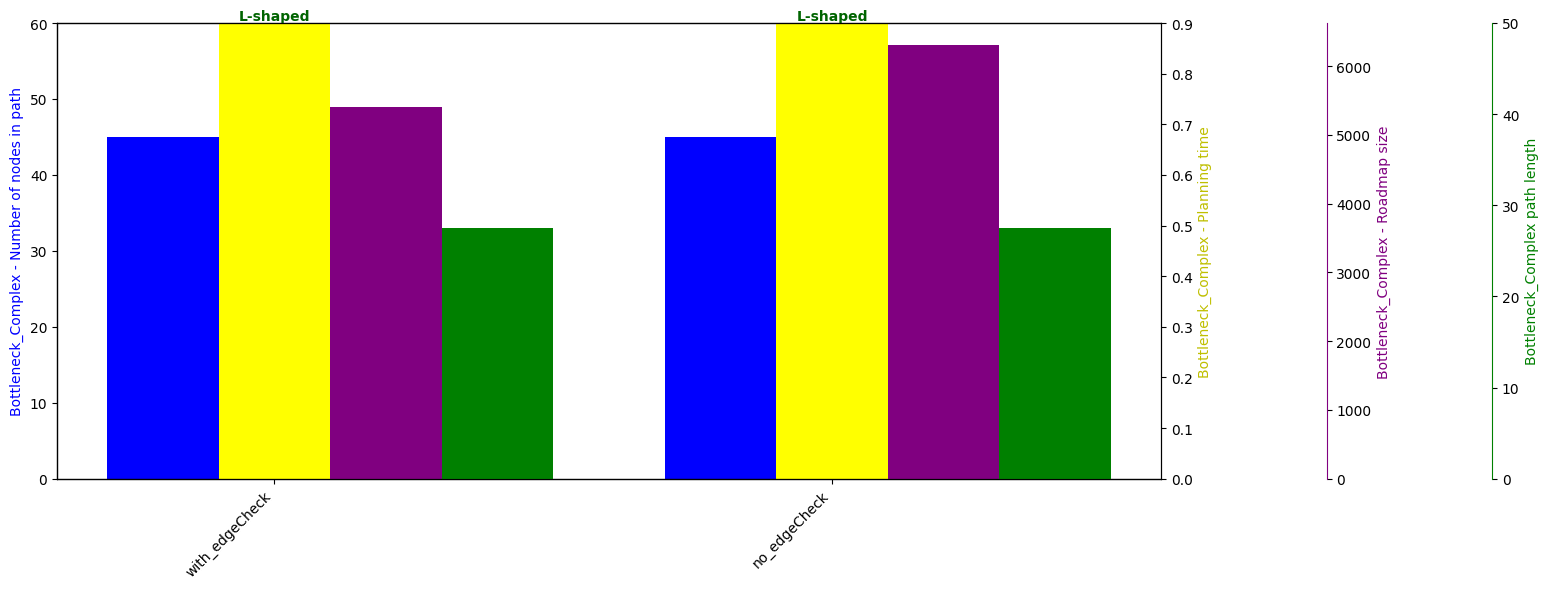

In [7]:
resultList = list()
class ResultCollection (object):
    
    def __init__(self, plannerFactoryName, planner, benchmark, solution, perfDataFrame):
        self.plannerFactoryName = plannerFactoryName
        self.planner = planner
        self.benchmark = benchmark
        self.solution = solution
        self.perfDataFrame = perfDataFrame

import IPTestSuite2 as ts
from shapely.geometry import Point, Polygon, LineString
from shapely import plotting

fullBenchList = ts.benchList

for benchmark in fullBenchList:
    print(benchmark.name)



import matplotlib.animation as animation
from IPython.display import HTML, display
import copy
import numpy as np
import matplotlib.pyplot as plt

# Hilfsfunktion (unverändert, aber wir behandeln den Rückgabewert jetzt besser)
def _interpolate_line(startPos, endPos, step_l):
    steps = []
    line = np.array(endPos) - np.array(startPos)
    line_l = np.linalg.norm(line)
    if line_l == 0:
        return [np.array(startPos)]
    step = line / line_l * step_l
    n_steps = int(np.floor(line_l / step_l))
    c_step = np.array(startPos, dtype=float)
    for i in range(n_steps):
        steps.append(copy.deepcopy(c_step))
        c_step = c_step + step
    if not np.allclose(c_step, np.array(endPos)):
        steps.append(np.array(endPos, dtype=float))
    return steps

def animate_solution_multi_downsampled(prm, environment, solution, visualizer=None, 
                                     workSpaceLimits=None, step_l=0.1, interval=50, 
                                     max_frames=200, figsize=(6,6), dpi=40, 
                                     pause_frames=40):
    
    # 1. Basic Checks
    if not solution or len(solution) < 2:
        raise ValueError('solution must contain at least two nodes')

    # 1. Récupération des positions pour l'interpolation du robot
    path_pos = [prm.graph.nodes[n]['pos'] for n in solution]
    
    # Interpolation (Mouvement fluide du point rouge)
    full_path = [path_pos[0]]
    for i in range(1, len(path_pos)):
        s, e = np.array(path_pos[i-1]), np.array(path_pos[i])
        dist = np.linalg.norm(e - s)
        if dist > 0:
            n_steps = int(np.floor(dist / step_l))
            for j in range(1, n_steps + 1):
                full_path.append(s + (e - s) * (j / (n_steps + 1)))
    full_path.append(path_pos[-1])

    # Downsampling
    if len(full_path) > max_frames:
        indices = np.linspace(0, len(full_path)-1, max_frames).astype(int)
        frames_data = [full_path[i] for i in indices]
    else:
        frames_data = full_path

    # 2. Setup Figure
    fig_local, ax = plt.subplots(figsize=figsize, dpi=dpi)
    limits = environment.getEnvironmentLimits()

    def _animate(current_pos):
        ax.cla() # On efface pour redessiner proprement
        
        # --- VISUALIZER OHNE ROBOTER-SHAPES ---
        # Deaktiviere temporär die drawRobot Methode, damit der Visualizer
        # die Diskretisierung zeichnet, aber nicht die grünen Roboter-Shapes
        original_drawRobot = environment.robot.drawRobot
        environment.robot.drawRobot = lambda ax, **kwargs: None  # Dummy-Funktion
        
        visualizer(prm, solution, ax=ax, nodeSize=100)
        
        # Stelle die ursprüngliche drawRobot Methode wieder her
        environment.robot.drawRobot = original_drawRobot
        
        # On redessine les obstacles par sécurité
        environment.drawObstacles(ax)
        
        # On remet les limites (parce que visualizer peut les changer)
        ax.set_xlim(limits[0])
        ax.set_ylim(limits[1])
        ax.set_title("A* Visualization & Animation")

        # --- MARKIERUNG VON START UND ZIEL ---
        # Startpunkt: Grüner Punkt mit 'S'
        start_pos = path_pos[0]
        ax.plot(start_pos[0], start_pos[1], 'o', color='#00dd00', 
                markersize=15, markeredgecolor='black', zorder=11)
        ax.text(start_pos[0], start_pos[1], 'S', ha='center', va='center',
                fontsize=12, fontweight='bold', color='black', zorder=12)
        
        # Zielpunkt: Roter Punkt mit 'G'
        goal_pos = path_pos[-1]
        ax.plot(goal_pos[0], goal_pos[1], 'o', color='#DD0000', 
                markersize=15, markeredgecolor='black', zorder=11)
        ax.text(goal_pos[0], goal_pos[1], 'G', ha='center', va='center',
                fontsize=12, fontweight='bold', color='white', zorder=12)

        # --- NUR DER ANIMIERTE ROTE ROBOTER ---
        environment.robot.setTo(current_pos)
        environment.robot.drawRobot(ax, color='red', alpha=0.9)

    print(f"Rendu de l'animation (Diskretisierung + nur roter Roboter)...")
    ani = animation.FuncAnimation(fig_local, _animate, frames=frames_data, interval=interval)
    
    html = HTML(ani.to_jshtml())
    display(html)
    plt.close()
    return ani

import networkx as nx

def lazyPRMVisualizeWorkspace(planner, solution = [] , ax=None, nodeSize = 300):
    """
    Angepasster Visualizer für LazyPRM im Workspace (nur x,y aus 3D-Konfigurationsraum)
    """
    graph = planner.graph.copy()
    collChecker = planner._collisionChecker
    collEdges = planner.collidingEdges
    nonCollEdges = planner.nonCollidingEdges
    
    # Extrahiere nur x,y aus (x, y, theta) Positionen
    pos_3d = nx.get_node_attributes(graph,'pos')
    pos = {node: (coords[0], coords[1]) for node, coords in pos_3d.items()}
    
    color = nx.get_node_attributes(graph,'color')

    collChecker.drawObstacles(ax)
    
    # draw graph
    nx.draw_networkx_nodes(graph, pos, ax = ax, nodelist=list(color.keys()), 
                          node_color=list(color.values()), node_size=nodeSize)
    nx.draw_networkx_edges(graph, pos, ax = ax)
    
    # draw all connected components, emphasize the largest one
    Gcc=(graph.subgraph(c) for c in nx.connected_components(graph))
    G0=next(Gcc)
    
    nx.draw_networkx_edges(G0, pos,
                          edge_color='b',
                          width=3.0, style='dashed',
                          alpha=0.5)
    
    if collEdges != []:
        collGraph = nx.Graph()
        collGraph.add_nodes_from(graph.nodes(data=True))
        for i in collEdges:
            collGraph.add_edge(i[0],i[1])
        nx.draw_networkx_edges(collGraph, pos, alpha=0.2, edge_color='r', width=5)
    
    if nonCollEdges != []:
        nonCollGraph = nx.Graph()
        nonCollGraph.add_nodes_from(graph.nodes(data=True))
        for i in nonCollEdges:
            nonCollGraph.add_edge(i[0],i[1])
        nx.draw_networkx_edges(nonCollGraph, pos, alpha=0.8, edge_color='yellow', width=5)
    
    # draw start and goal
    if "start" in graph.nodes(): 
        nx.draw_networkx_nodes(graph, pos, nodelist=["start"],
                              node_size=300,
                              node_color='#00dd00', ax = ax)
        nx.draw_networkx_labels(graph, pos, labels={"start": "S"}, ax = ax)

    if "goal" in graph.nodes():
        nx.draw_networkx_nodes(graph, pos, nodelist=["goal"],
                              node_size=300,
                              node_color='#DD0000', ax = ax)
        nx.draw_networkx_labels(graph, pos, labels={"goal": "G"}, ax = ax)

    if solution != []:
        Gsp = nx.subgraph(graph, solution)
        nx.draw_networkx_edges(Gsp, pos, alpha=0.8, edge_color='g', width=10)
    
    return


# for benchmark in fullBenchList:
#     fig_local = plt.figure(figsize=(7,7))
#     ax = fig_local.add_subplot(1,1,1)
#     title = benchmark.name
#     ax.set_title(title)
#     ax.set_xlim(benchmark.collisionChecker.getEnvironmentLimits()[0])
#     ax.set_ylim(benchmark.collisionChecker.getEnvironmentLimits()[1])
#     plotting.plot_points(Point(benchmark.startList[0]).buffer(.3), color="g", ax=ax)
#     plotting.plot_points(Point(benchmark.goalList[0]).buffer(.3), color="b", ax=ax)
#     #try:
#     benchmark.collisionChecker.drawObstacles(ax)
  
        
#     #except Exception as e:
#     #    print ("Error", e)
#     #    pass
#     plt.show()


resultList = list()
testList = fullBenchList

for key,producer in list(plannerFactory.items()):
    print(key, producer)
    for benchmark in testList:
        print ("Planning: " + key + " - " + benchmark.name)
        #planner = IPBasicPRM.BasicPRM(benchmark.collisionChecker)
        planner = producer[0](benchmark.collisionChecker)
        IPPerfMonitor.clearData()
        try:
            
            resultList.append(ResultCollection(key,
                                          planner, 
                                           benchmark, 
                                           planner.planPath(benchmark.startList,benchmark.goalList,producer[1]),
                                           IPPerfMonitor.dataFrame()
                                          ),
                        )
        except Exception as e:
        #    throw e
            print ("PLANNING ERROR ! PLANNING ERROR ! PLANNING ERROR ", e)
            pass

import matplotlib.pyplot as plt

for result in resultList:
    
    fig_local = plt.figure(figsize=(20,20))
    ax = fig_local.add_subplot(1,1,1)
    title = result.plannerFactoryName + " - " + result.benchmark.name
    if result.solution == []:
        title += " (No path found!)"
    #title += "\n Assumed complexity level " + str(result.benchmark.level)
    ax.set_title(title)
    try:
        # Temporär erweiter Ludwig Setze den Roboter an die Endposition, falls eine Lösung existiert
        if result.solution and len(result.solution) > 0:
            goal_node = result.solution[-1]
            if hasattr(result.planner, 'graph') and goal_node in result.planner.graph.nodes:
                goal_pos = result.planner.graph.nodes[goal_node]['pos']
                result.benchmark.collisionChecker.robot.setTo(goal_pos)
        
        #IPVISBasicsPRM.basicPRMVisualize(result.planner, result.solution, ax=ax, nodeSize=100))
        plannerFactory[result.plannerFactoryName][2](result.planner, result.solution, ax=ax, nodeSize=100)
        
        # Zeichne Roboter am Startpunkt (grün) und Endpunkt (blau)
        if result.solution and len(result.solution) > 0:
            if hasattr(result.planner, 'graph'):
                # Startroboter in grün
                start_node = result.solution[0]
                if start_node in result.planner.graph.nodes:
                    start_pos = result.planner.graph.nodes[start_node]['pos']
                    result.benchmark.collisionChecker.robot.setTo(start_pos)
                    result.benchmark.collisionChecker.robot.drawRobot(ax, color='green', alpha=0.5)
                
                # Endroboter in blau
                goal_node = result.solution[-1]
                if goal_node in result.planner.graph.nodes:
                    goal_pos = result.planner.graph.nodes[goal_node]['pos']
                    result.benchmark.collisionChecker.robot.setTo(goal_pos)
                    result.benchmark.collisionChecker.robot.drawRobot(ax, color='blue', alpha=0.7)
        
    except Exception as e:
        print ("Error", e)
        pass
    
    plt.show()

# for bench in testList:
#     for result in resultList:
#         if result.benchmark.name == bench.name:
#             # Prüfe ob Lösung existiert UND mindestens 2 Knoten hat
#             if result.solution is not None and len(result.solution) >= 2:
#                 print(f"Animation für: {result.plannerFactoryName} - {bench.name}")
#                 print(f"  Anzahl Knoten im Pfad: {len(result.solution)}")
#                 try:
#                     animate_solution_multi_downsampled(
#                         result.planner, bench.collisionChecker, result.solution,
#                         visualizer=plannerFactory[result.plannerFactoryName][2],
#                         step_l=0.05, interval=60, max_frames=200, figsize=(20,20), dpi=40)
#                 except Exception as e:
#                     print(f"  FEHLER bei Animation: {e}")
#             else:
#                 if result.solution is None:
#                     print(f"Keine Animation für {result.plannerFactoryName} - {bench.name}: Keine Lösung gefunden")
#                 else:
#                     print(f"Keine Animation für {result.plannerFactoryName} - {bench.name}: Zu wenige Knoten ({len(result.solution)})")

def compute_path_lengths_multi(graph, solution, theta_in_radians=True):
    """
    Berechnet die Gesamtpfadläng pro Roboter in einem Graphen mit mehreren Robotern

    Das Knotenattribut 'pos' ist eine sequenz [x1,y1,theta1, x2,y2,theta2,...]
    Für unsere zwei Roboter sind es 6 Einträge pro Knoten.
    Die Funktion summiert die euklidischen Distanzen zwischen jedem Knotenpaar (Kanten) in der xy-Ebene für jeden Roboter auf.
    """
    import numpy as np
    import networkx as nx

    # Falls keine Lösung oder nur ein Knoten vorhanden ist, sofort Nullwerte zurückgeben
    if not solution or len(solution) < 2:
        return {
            'green': {'total': 0.0},
            'red': {'total': 0.0},
            'segments': 0
        }

    # Hole alle 'pos' Attribute aus dem Graph (dict: node -> config)
    pos_attr = nx.get_node_attributes(graph, 'pos')
    total_g = 0.0  # aufsummierte Distanz für grünen Roboter (Roboter 1)
    total_r = 0.0  # aufsummierte Distanz für roten Roboter (Roboter 2)
    segments = 0   # Anzahl der Segmente (Anzahl Kanten im Pfad)

    # Iteriere über alle aufeinanderfolgenden Knotenpaare der Lösung
    for i in range(len(solution) - 1):
        a = solution[i]; b = solution[i + 1]
        # Fehler, falls ein Knoten kein 'pos' Attribut hat (schützt vor inkonsistenten Graphen)
        if a not in pos_attr or b not in pos_attr:
            raise ValueError(f"Node {a} or {b} missing 'pos' attribute in graph")
        pa = np.array(pos_attr[a], dtype=float)  # Konfiguration an Knoten a
        pb = np.array(pos_attr[b], dtype=float)  # Konfiguration an Knoten b

        # Berechne Euklidische Distanz in der xy‑Ebene für Roboter 1 (grün)
        # pa[0:2] und pb[0:2] sind [x1,y1] für Roboter 1
        total_g += float(np.linalg.norm(pb[0:2] - pa[0:2]))

        # Berechne Euklidische Distanz in der xy‑Ebene für Roboter 2 (rot)
        # pa[3:5] und pb[3:5] sind [x2,y2] für Roboter 2
        total_r += float(np.linalg.norm(pb[3:5] - pa[3:5]))

        segments += 1  # ein weiteres Kanten-Segment wurde betrachtet

    # Rückgabe: pro Roboter nur die 'total' Länge (Rotationen werden hier bewusst nicht berücksichtigt)
    return {
        'green': {'total': total_g},
        'red': {'total': total_r},
        'segments': segments
    }




def get_robot_shape_description(benchmark):
    """Ermittelt eine Beschreibung der Roboterform basierend auf der Geometrie."""
    try:
        robot = benchmark.collisionChecker.robot
        if hasattr(robot, '_template'):
            # ShapeRobotWithOrientation - verwende Template Geometrie
            coords = list(robot._template.exterior.coords)
        elif hasattr(robot, 'geometry'):
            # ShapeRobot - verwende direkte Geometrie
            coords = list(robot.geometry.exterior.coords)
        else:
            return "Unknown"
        
        # Analysiere die Form basierend auf Eckpunkten
        num_vertices = len(coords) - 1  # Letzter Punkt = erster Punkt
        
        # Prüfe ob es ein Rechteck ist (4 Eckpunkte)
        if num_vertices == 4:
            # Prüfe Dimensionen
            xs = [c[0] for c in coords]
            ys = [c[1] for c in coords]
            width = max(xs) - min(xs)
            height = max(ys) - min(ys)
            
            if abs(width - 2.5) < 0.1 and abs(height - 1.0) < 0.1:
                return "Rectangle (2.5x1.0)"
            else:
                return f"Rectangle ({width:.1f}x{height:.1f})"
        
        # Prüfe ob es ein L-förmiger Roboter ist (6 Eckpunkte)
        elif num_vertices == 6:
            return "L-shaped"
        
        else:
            return f"Custom ({num_vertices} vertices)"
    except:
        return "Unknown"

import numpy as np
for bench in testList:
    title = bench.name
    
    # Roboter-Form zur Beschreibung hinzufügen
    robot_shape = get_robot_shape_description(bench)
    
    pathLength = dict()
    planningTime = dict()
    roadmapSize  = dict()
    res=dict()

    try:
        for result in resultList:
            if result.benchmark.name == bench.name:
                #print result.benchmark.name  + " - " +  result.plannerFactoryName, len(result.solution)
                pathLength[result.plannerFactoryName] = len(result.solution)
                planningTime[result.plannerFactoryName] = result.perfDataFrame.groupby(["name"]).sum(numeric_only=True)["time"]["planPath"]
                roadmapSize[result.plannerFactoryName] = result.planner.graph.size()
                res[result.plannerFactoryName] = compute_path_lengths_multi(result.planner.graph, result.solution, theta_in_radians=True)

        fig, ax = plt.subplots(figsize=(16, 6))  # Breitere Figur

        width = 0.2

        ax.bar(np.arange(len(pathLength.keys())), pathLength.values(),width, color="blue")
        ax.set_ylabel(title + " - Number of nodes in path", color="blue")
        ax.set_ylim(0,60)
        ax.set_xticks(np.arange(len(pathLength.keys())) + width)
        ax.set_xticklabels(pathLength.keys(), rotation=45, ha='right')  # Rotierte Labels

        ax2 = ax.twinx()
        bar = ax2.bar(np.arange(len(pathLength.keys()))+width, planningTime.values(),width, color="red")
        ax2.set_ylabel(title + " - Planning time", color="y")
        ax2.set_ylim(0,0.9)

        # Add coloring and patterns on axis two
        hatches = ['x' if length==0 else '' for length in pathLength.values()]
        color   = ['red' if length==0 else 'yellow' for length in pathLength.values()]
        for i,thisbar in enumerate(bar.patches):
            thisbar.set_facecolor(color[i])
            thisbar.set_hatch(hatches[i])

        # Multiple axes 
        ax3 = ax.twinx()
        ax3.bar(np.arange(len(pathLength.keys()))+2*width, roadmapSize.values(),width, color="purple")
        ax3.set_ylabel(title + " - Roadmap size",  color="purple")
        ax3.spines['right'].set_position(('axes', 1.15))
        ax3.spines['right'].set_color("purple")

        ax4 = ax.twinx()
        ax4.bar(np.arange(len(pathLength.keys()))+3*width, [res[planner].get('green', {}).get('total', 0) for planner in pathLength.keys()], width, color="green")
        ax4.set_ylabel(title + " path length", color="green")
        ax4.spines['right'].set_position(('axes', 1.3))
        ax4.spines['right'].set_color("green")
        ax4.set_ylim(0,50)
        
        # Roboterform über den Balken anzeigen
        # Berechne die maximale Höhe für die Positionierung
        max_y = max(list(roadmapSize.values()) + [0]) if roadmapSize else 0
        
        # Text mittig über allen Balkengruppen platzieren
        for i in range(len(pathLength.keys())):
            ax3.text(i + width, max_y * 1.05, f"{robot_shape}", 
                    ha='center', va='bottom', fontsize=10, fontweight='bold',
                    rotation=0, color='darkgreen')
        
        plt.tight_layout()  # Besseres Layout, verhindert abgeschnittene Labels
    except:
        pass

    plt.show()
    



# Vergleich mit und ohne Reopening (L-shape)

In [12]:
plannerFactory = dict()

# ========================================
# A* MIT Reopening
# ========================================
astarReopen_on = dict()
astarReopen_on["heuristic"] = 'euclidean' 
astarReopen_on["w"] = 0.6
astarReopen_on["num_steps"] = [20, 20, 36]
astarReopen_on["checkEdgeCollision"] = False
astarReopen_on["allowReopqening"] = True
plannerFactory["astar_w50_reopening_ON"] = [AStarReopeningNew.ReopenAStar, astarReopen_on, IPVISAStar.aStarVisualizeWspace]

# ========================================
# A* OHNE Reopening (zum Vergleich)
# ========================================
astarReopen_off = dict()
astarReopen_off["heuristic"] = 'euclidean' 
astarReopen_off["w"] = 0.6
astarReopen_off["num_steps"] = [20, 20, 36]
astarReopen_off["checkEdgeCollision"] = False
plannerFactory["astar_w50_reopening_OFF"] = [IPAStar.AStar, astarReopen_off, IPVISAStar.aStarVisualizeWspace]

Trap_Complex
Bottleneck_Complex
astar_w50_reopening_ON [<class 'AStarReopeningNew.ReopenAStar'>, {'heuristic': 'euclidean', 'w': 0.6, 'num_steps': [20, 20, 36], 'checkEdgeCollision': False, 'allowReopqening': True}, <function aStarVisualizeWspace at 0x000001D3EC335C60>]
Planning: astar_w50_reopening_ON - Trap_Complex
Planning: astar_w50_reopening_ON - Bottleneck_Complex
astar_w50_reopening_OFF [<class 'IPAStar.AStar'>, {'heuristic': 'euclidean', 'w': 0.6, 'num_steps': [20, 20, 36], 'checkEdgeCollision': False}, <function aStarVisualizeWspace at 0x000001D3EC335C60>]
Planning: astar_w50_reopening_OFF - Trap_Complex
Planning: astar_w50_reopening_OFF - Bottleneck_Complex


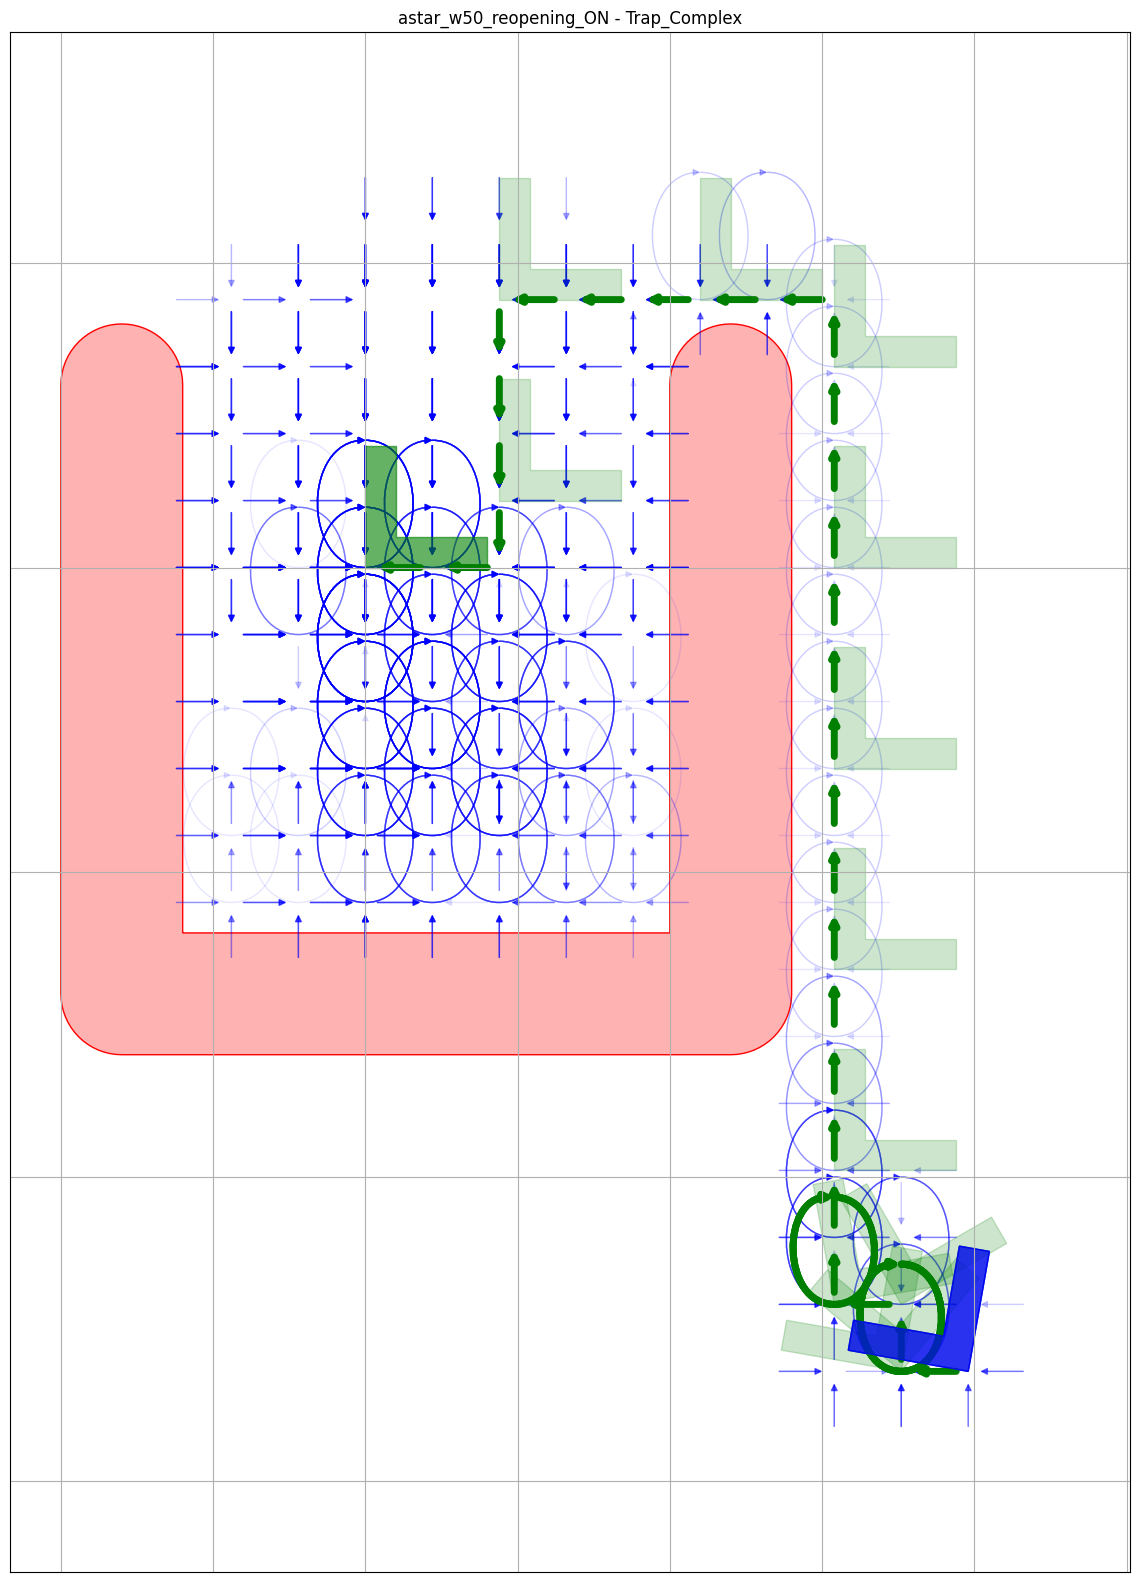

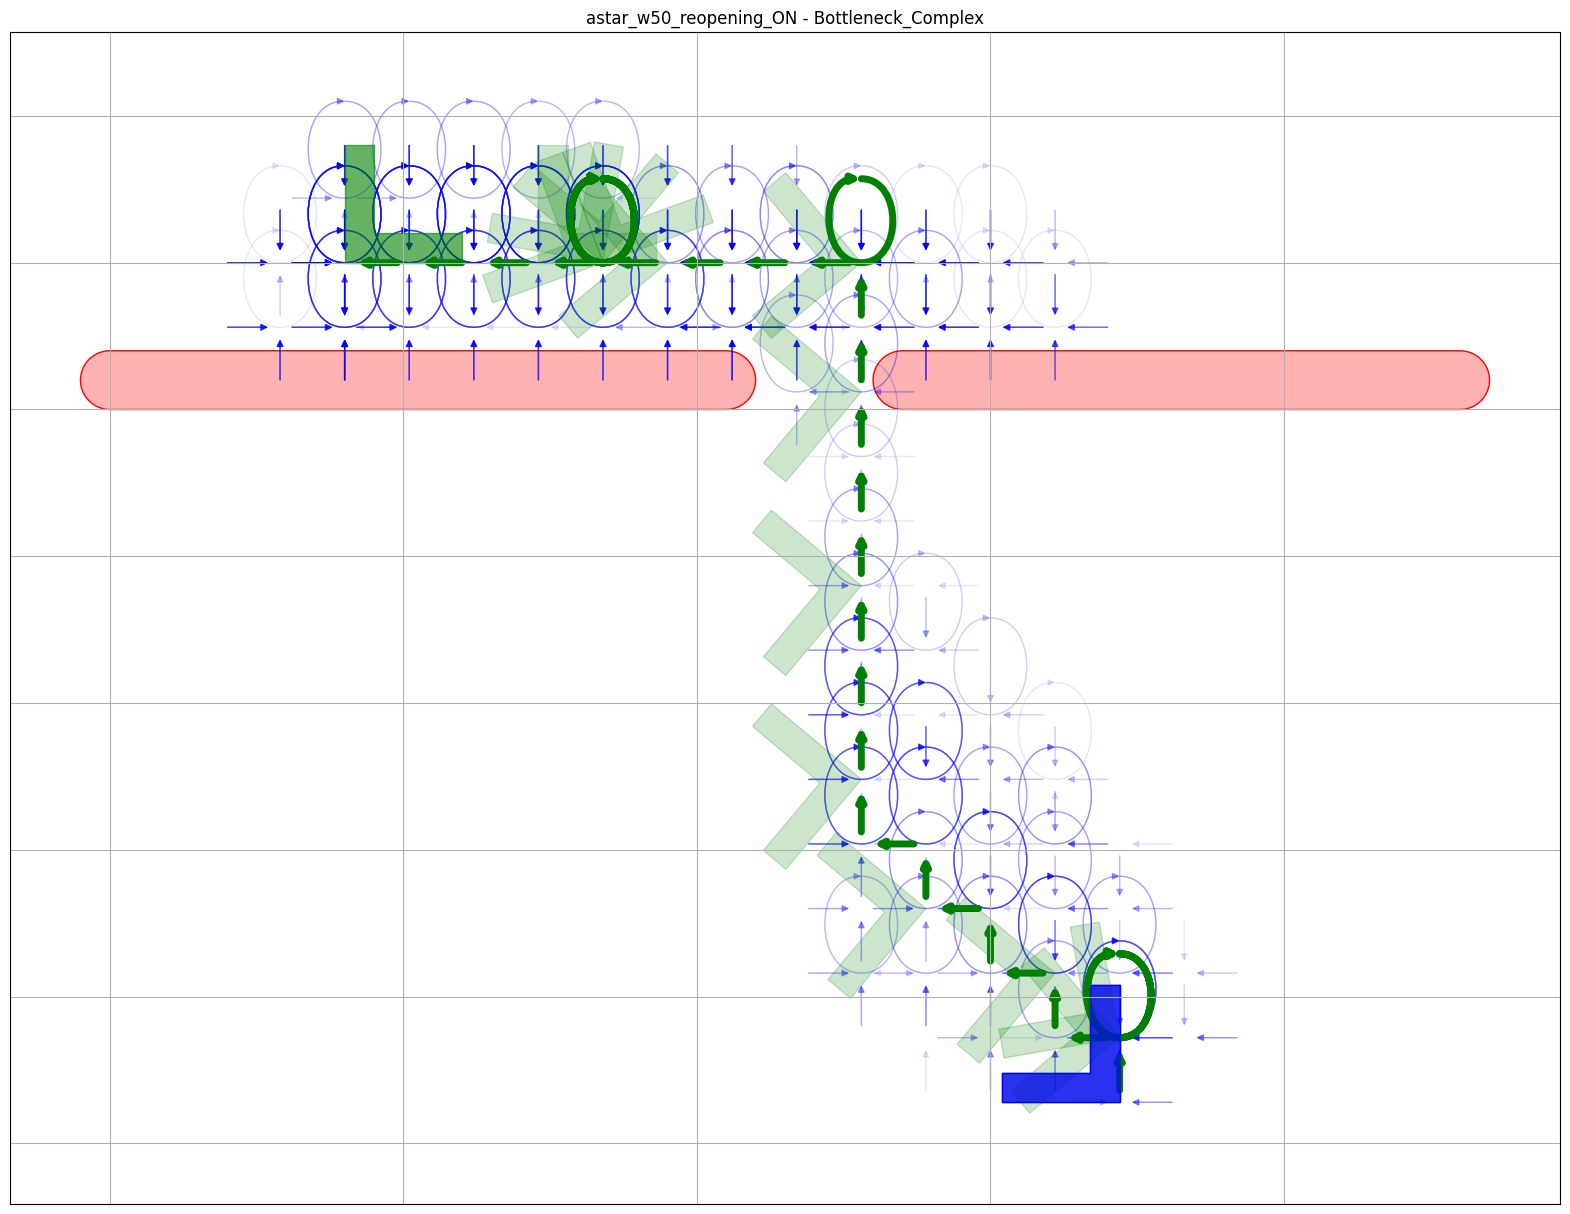

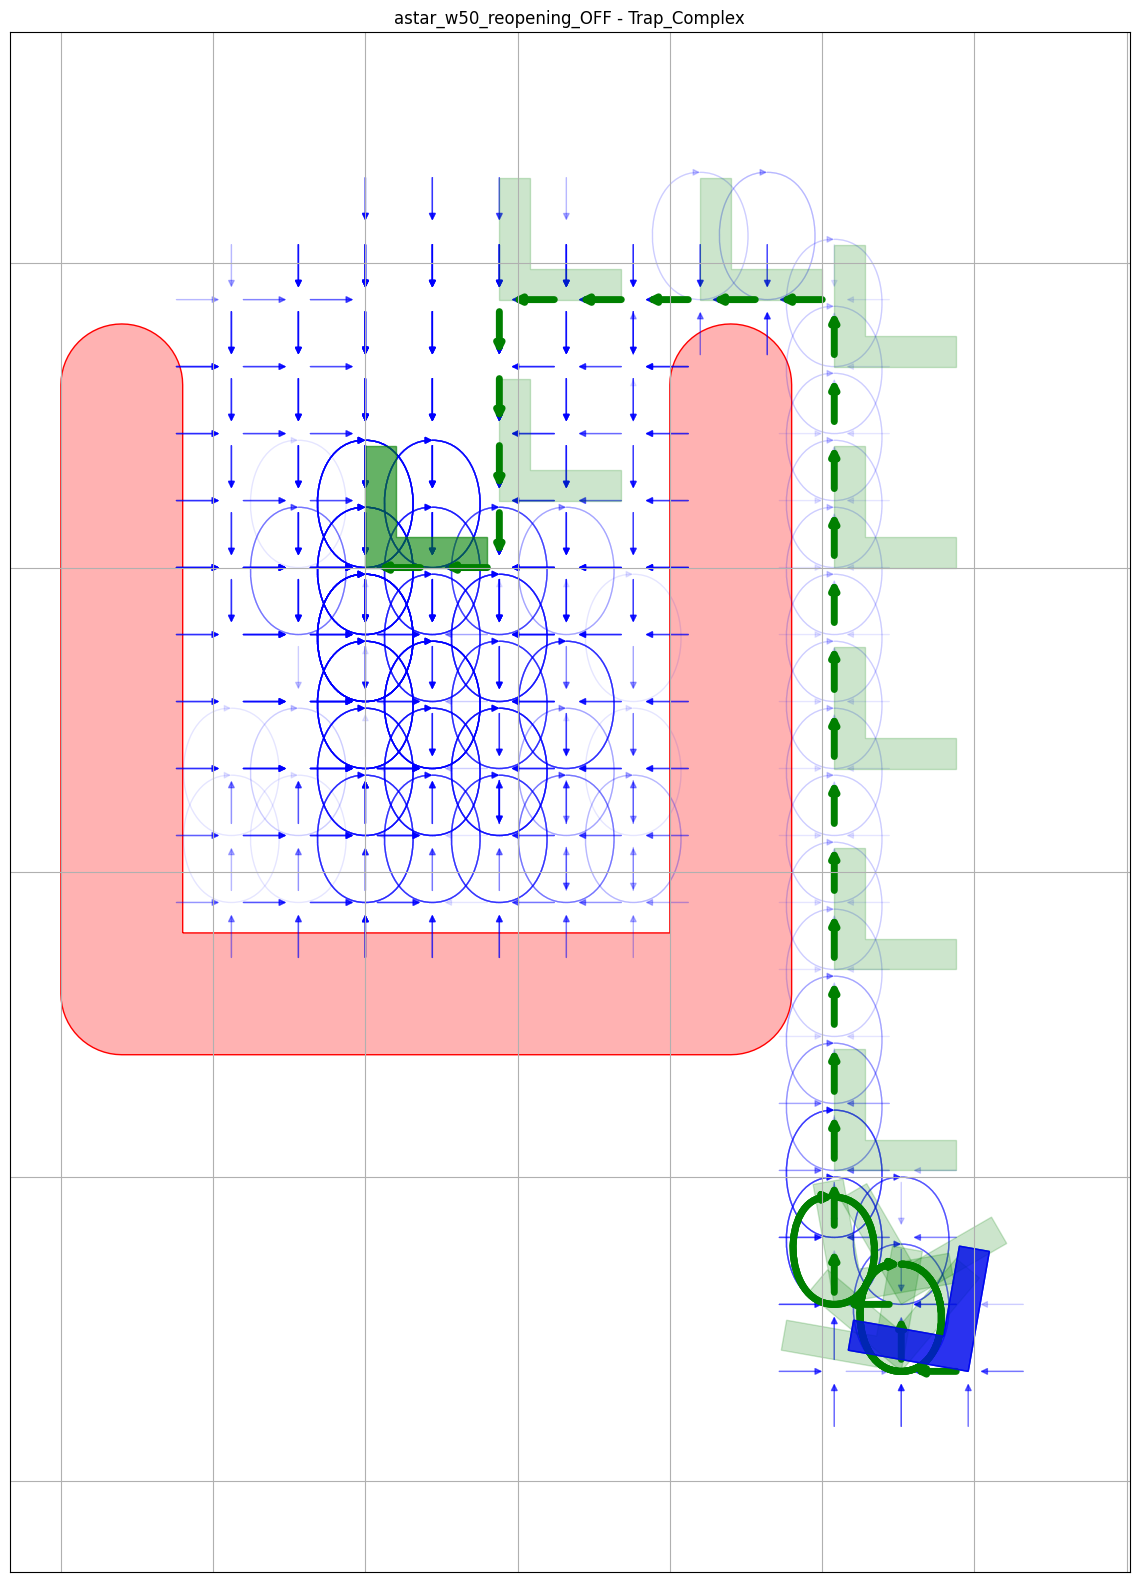

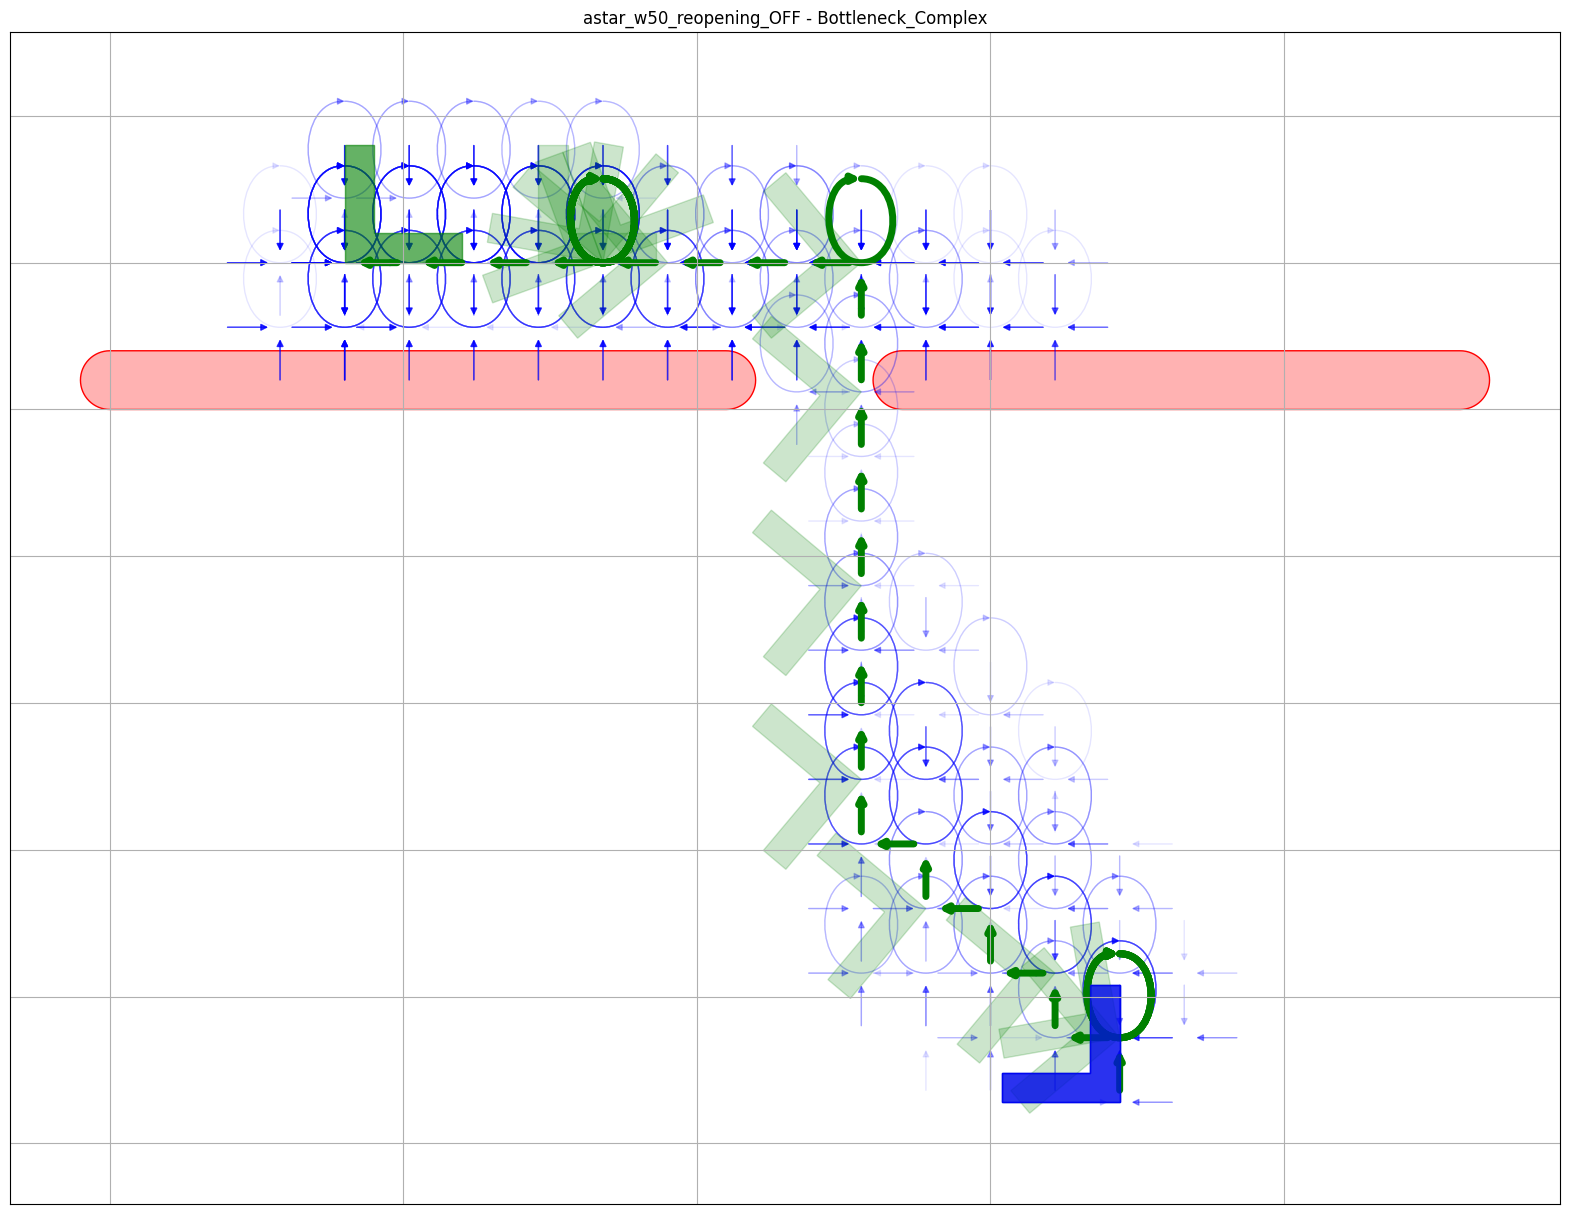

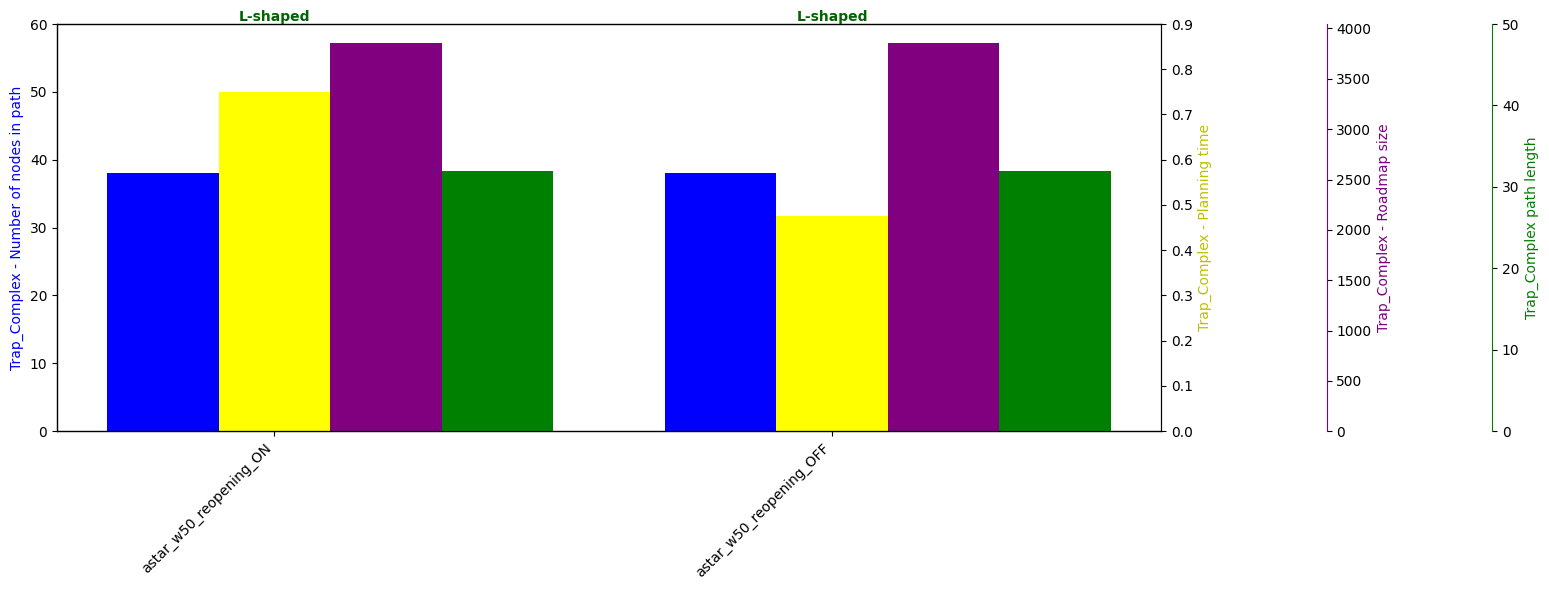

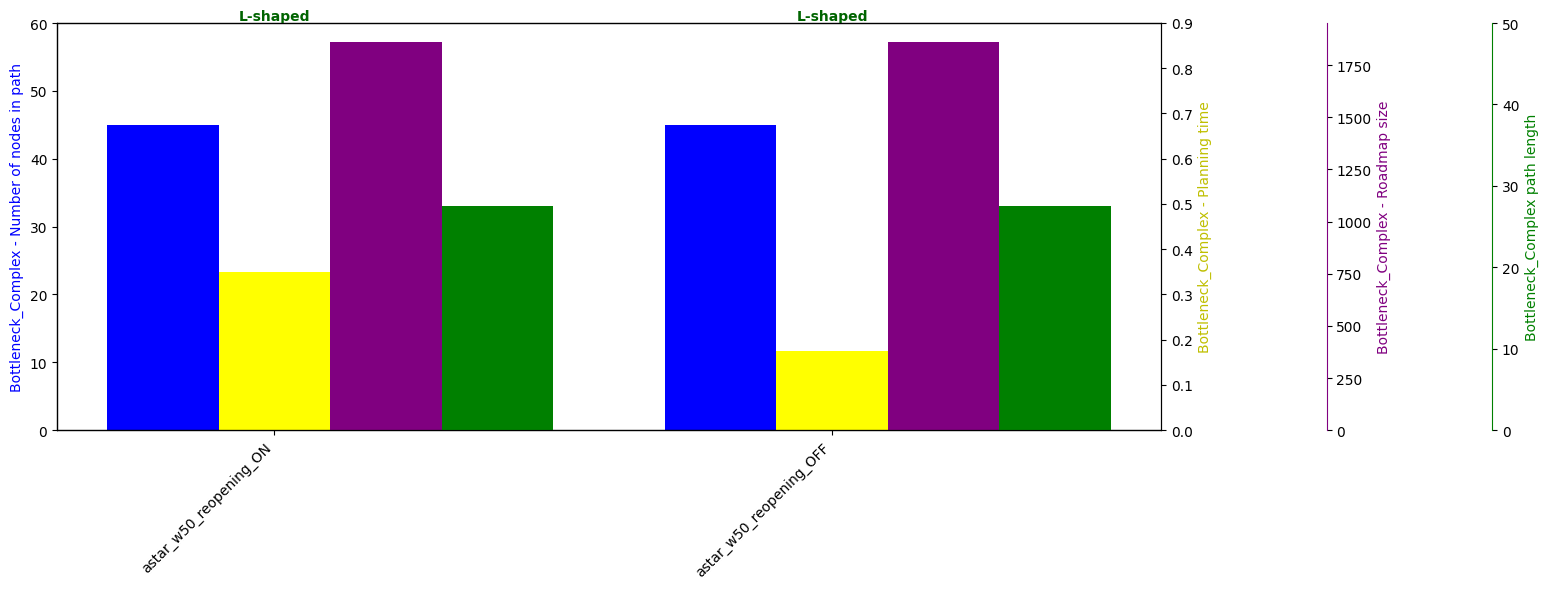

In [13]:
resultList = list()
class ResultCollection (object):
    
    def __init__(self, plannerFactoryName, planner, benchmark, solution, perfDataFrame):
        self.plannerFactoryName = plannerFactoryName
        self.planner = planner
        self.benchmark = benchmark
        self.solution = solution
        self.perfDataFrame = perfDataFrame

import IPTestSuite2 as ts
from shapely.geometry import Point, Polygon, LineString
from shapely import plotting

fullBenchList = ts.benchList

for benchmark in fullBenchList:
    print(benchmark.name)



import matplotlib.animation as animation
from IPython.display import HTML, display
import copy
import numpy as np
import matplotlib.pyplot as plt

# Hilfsfunktion (unverändert, aber wir behandeln den Rückgabewert jetzt besser)
def _interpolate_line(startPos, endPos, step_l):
    steps = []
    line = np.array(endPos) - np.array(startPos)
    line_l = np.linalg.norm(line)
    if line_l == 0:
        return [np.array(startPos)]
    step = line / line_l * step_l
    n_steps = int(np.floor(line_l / step_l))
    c_step = np.array(startPos, dtype=float)
    for i in range(n_steps):
        steps.append(copy.deepcopy(c_step))
        c_step = c_step + step
    if not np.allclose(c_step, np.array(endPos)):
        steps.append(np.array(endPos, dtype=float))
    return steps

def animate_solution_multi_downsampled(prm, environment, solution, visualizer=None, 
                                     workSpaceLimits=None, step_l=0.1, interval=50, 
                                     max_frames=200, figsize=(6,6), dpi=40, 
                                     pause_frames=40):
    
    # 1. Basic Checks
    if not solution or len(solution) < 2:
        raise ValueError('solution must contain at least two nodes')

    # 1. Récupération des positions pour l'interpolation du robot
    path_pos = [prm.graph.nodes[n]['pos'] for n in solution]
    
    # Interpolation (Mouvement fluide du point rouge)
    full_path = [path_pos[0]]
    for i in range(1, len(path_pos)):
        s, e = np.array(path_pos[i-1]), np.array(path_pos[i])
        dist = np.linalg.norm(e - s)
        if dist > 0:
            n_steps = int(np.floor(dist / step_l))
            for j in range(1, n_steps + 1):
                full_path.append(s + (e - s) * (j / (n_steps + 1)))
    full_path.append(path_pos[-1])

    # Downsampling
    if len(full_path) > max_frames:
        indices = np.linspace(0, len(full_path)-1, max_frames).astype(int)
        frames_data = [full_path[i] for i in indices]
    else:
        frames_data = full_path

    # 2. Setup Figure
    fig_local, ax = plt.subplots(figsize=figsize, dpi=dpi)
    limits = environment.getEnvironmentLimits()

    def _animate(current_pos):
        ax.cla() # On efface pour redessiner proprement
        
        # --- VISUALIZER OHNE ROBOTER-SHAPES ---
        # Deaktiviere temporär die drawRobot Methode, damit der Visualizer
        # die Diskretisierung zeichnet, aber nicht die grünen Roboter-Shapes
        original_drawRobot = environment.robot.drawRobot
        environment.robot.drawRobot = lambda ax, **kwargs: None  # Dummy-Funktion
        
        visualizer(prm, solution, ax=ax, nodeSize=100)
        
        # Stelle die ursprüngliche drawRobot Methode wieder her
        environment.robot.drawRobot = original_drawRobot
        
        # On redessine les obstacles par sécurité
        environment.drawObstacles(ax)
        
        # On remet les limites (parce que visualizer peut les changer)
        ax.set_xlim(limits[0])
        ax.set_ylim(limits[1])
        ax.set_title("A* Visualization & Animation")

        # --- MARKIERUNG VON START UND ZIEL ---
        # Startpunkt: Grüner Punkt mit 'S'
        start_pos = path_pos[0]
        ax.plot(start_pos[0], start_pos[1], 'o', color='#00dd00', 
                markersize=15, markeredgecolor='black', zorder=11)
        ax.text(start_pos[0], start_pos[1], 'S', ha='center', va='center',
                fontsize=12, fontweight='bold', color='black', zorder=12)
        
        # Zielpunkt: Roter Punkt mit 'G'
        goal_pos = path_pos[-1]
        ax.plot(goal_pos[0], goal_pos[1], 'o', color='#DD0000', 
                markersize=15, markeredgecolor='black', zorder=11)
        ax.text(goal_pos[0], goal_pos[1], 'G', ha='center', va='center',
                fontsize=12, fontweight='bold', color='white', zorder=12)

        # --- NUR DER ANIMIERTE ROTE ROBOTER ---
        environment.robot.setTo(current_pos)
        environment.robot.drawRobot(ax, color='red', alpha=0.9)

    print(f"Rendu de l'animation (Diskretisierung + nur roter Roboter)...")
    ani = animation.FuncAnimation(fig_local, _animate, frames=frames_data, interval=interval)
    
    html = HTML(ani.to_jshtml())
    display(html)
    plt.close()
    return ani

import networkx as nx

def lazyPRMVisualizeWorkspace(planner, solution = [] , ax=None, nodeSize = 300):
    """
    Angepasster Visualizer für LazyPRM im Workspace (nur x,y aus 3D-Konfigurationsraum)
    """
    graph = planner.graph.copy()
    collChecker = planner._collisionChecker
    collEdges = planner.collidingEdges
    nonCollEdges = planner.nonCollidingEdges
    
    # Extrahiere nur x,y aus (x, y, theta) Positionen
    pos_3d = nx.get_node_attributes(graph,'pos')
    pos = {node: (coords[0], coords[1]) for node, coords in pos_3d.items()}
    
    color = nx.get_node_attributes(graph,'color')

    collChecker.drawObstacles(ax)
    
    # draw graph
    nx.draw_networkx_nodes(graph, pos, ax = ax, nodelist=list(color.keys()), 
                          node_color=list(color.values()), node_size=nodeSize)
    nx.draw_networkx_edges(graph, pos, ax = ax)
    
    # draw all connected components, emphasize the largest one
    Gcc=(graph.subgraph(c) for c in nx.connected_components(graph))
    G0=next(Gcc)
    
    nx.draw_networkx_edges(G0, pos,
                          edge_color='b',
                          width=3.0, style='dashed',
                          alpha=0.5)
    
    if collEdges != []:
        collGraph = nx.Graph()
        collGraph.add_nodes_from(graph.nodes(data=True))
        for i in collEdges:
            collGraph.add_edge(i[0],i[1])
        nx.draw_networkx_edges(collGraph, pos, alpha=0.2, edge_color='r', width=5)
    
    if nonCollEdges != []:
        nonCollGraph = nx.Graph()
        nonCollGraph.add_nodes_from(graph.nodes(data=True))
        for i in nonCollEdges:
            nonCollGraph.add_edge(i[0],i[1])
        nx.draw_networkx_edges(nonCollGraph, pos, alpha=0.8, edge_color='yellow', width=5)
    
    # draw start and goal
    if "start" in graph.nodes(): 
        nx.draw_networkx_nodes(graph, pos, nodelist=["start"],
                              node_size=300,
                              node_color='#00dd00', ax = ax)
        nx.draw_networkx_labels(graph, pos, labels={"start": "S"}, ax = ax)

    if "goal" in graph.nodes():
        nx.draw_networkx_nodes(graph, pos, nodelist=["goal"],
                              node_size=300,
                              node_color='#DD0000', ax = ax)
        nx.draw_networkx_labels(graph, pos, labels={"goal": "G"}, ax = ax)

    if solution != []:
        Gsp = nx.subgraph(graph, solution)
        nx.draw_networkx_edges(Gsp, pos, alpha=0.8, edge_color='g', width=10)
    
    return


# for benchmark in fullBenchList:
#     fig_local = plt.figure(figsize=(7,7))
#     ax = fig_local.add_subplot(1,1,1)
#     title = benchmark.name
#     ax.set_title(title)
#     ax.set_xlim(benchmark.collisionChecker.getEnvironmentLimits()[0])
#     ax.set_ylim(benchmark.collisionChecker.getEnvironmentLimits()[1])
#     plotting.plot_points(Point(benchmark.startList[0]).buffer(.3), color="g", ax=ax)
#     plotting.plot_points(Point(benchmark.goalList[0]).buffer(.3), color="b", ax=ax)
#     #try:
#     benchmark.collisionChecker.drawObstacles(ax)
  
        
#     #except Exception as e:
#     #    print ("Error", e)
#     #    pass
#     plt.show()


resultList = list()
testList = fullBenchList

for key,producer in list(plannerFactory.items()):
    print(key, producer)
    for benchmark in testList:
        print ("Planning: " + key + " - " + benchmark.name)
        #planner = IPBasicPRM.BasicPRM(benchmark.collisionChecker)
        planner = producer[0](benchmark.collisionChecker)
        IPPerfMonitor.clearData()
        try:
            
            resultList.append(ResultCollection(key,
                                          planner, 
                                           benchmark, 
                                           planner.planPath(benchmark.startList,benchmark.goalList,producer[1]),
                                           IPPerfMonitor.dataFrame()
                                          ),
                        )
        except Exception as e:
        #    throw e
            print ("PLANNING ERROR ! PLANNING ERROR ! PLANNING ERROR ", e)
            pass

import matplotlib.pyplot as plt

for result in resultList:
    
    fig_local = plt.figure(figsize=(20,20))
    ax = fig_local.add_subplot(1,1,1)
    title = result.plannerFactoryName + " - " + result.benchmark.name
    if result.solution == []:
        title += " (No path found!)"
    #title += "\n Assumed complexity level " + str(result.benchmark.level)
    ax.set_title(title)
    try:
        # Temporär erweiter Ludwig Setze den Roboter an die Endposition, falls eine Lösung existiert
        if result.solution and len(result.solution) > 0:
            goal_node = result.solution[-1]
            if hasattr(result.planner, 'graph') and goal_node in result.planner.graph.nodes:
                goal_pos = result.planner.graph.nodes[goal_node]['pos']
                result.benchmark.collisionChecker.robot.setTo(goal_pos)
        
        #IPVISBasicsPRM.basicPRMVisualize(result.planner, result.solution, ax=ax, nodeSize=100))
        plannerFactory[result.plannerFactoryName][2](result.planner, result.solution, ax=ax, nodeSize=100)
        
        # Zeichne Roboter am Startpunkt (grün) und Endpunkt (blau)
        if result.solution and len(result.solution) > 0:
            if hasattr(result.planner, 'graph'):
                # Startroboter in grün
                start_node = result.solution[0]
                if start_node in result.planner.graph.nodes:
                    start_pos = result.planner.graph.nodes[start_node]['pos']
                    result.benchmark.collisionChecker.robot.setTo(start_pos)
                    result.benchmark.collisionChecker.robot.drawRobot(ax, color='green', alpha=0.5)
                
                # Endroboter in blau
                goal_node = result.solution[-1]
                if goal_node in result.planner.graph.nodes:
                    goal_pos = result.planner.graph.nodes[goal_node]['pos']
                    result.benchmark.collisionChecker.robot.setTo(goal_pos)
                    result.benchmark.collisionChecker.robot.drawRobot(ax, color='blue', alpha=0.7)
        
    except Exception as e:
        print ("Error", e)
        pass
    
    plt.show()

# for bench in testList:
#     for result in resultList:
#         if result.benchmark.name == bench.name:
#             # Prüfe ob Lösung existiert UND mindestens 2 Knoten hat
#             if result.solution is not None and len(result.solution) >= 2:
#                 print(f"Animation für: {result.plannerFactoryName} - {bench.name}")
#                 print(f"  Anzahl Knoten im Pfad: {len(result.solution)}")
#                 try:
#                     animate_solution_multi_downsampled(
#                         result.planner, bench.collisionChecker, result.solution,
#                         visualizer=plannerFactory[result.plannerFactoryName][2],
#                         step_l=0.05, interval=60, max_frames=200, figsize=(20,20), dpi=40)
#                 except Exception as e:
#                     print(f"  FEHLER bei Animation: {e}")
#             else:
#                 if result.solution is None:
#                     print(f"Keine Animation für {result.plannerFactoryName} - {bench.name}: Keine Lösung gefunden")
#                 else:
#                     print(f"Keine Animation für {result.plannerFactoryName} - {bench.name}: Zu wenige Knoten ({len(result.solution)})")

def compute_path_lengths_multi(graph, solution, theta_in_radians=True):
    """
    Berechnet die Gesamtpfadläng pro Roboter in einem Graphen mit mehreren Robotern

    Das Knotenattribut 'pos' ist eine sequenz [x1,y1,theta1, x2,y2,theta2,...]
    Für unsere zwei Roboter sind es 6 Einträge pro Knoten.
    Die Funktion summiert die euklidischen Distanzen zwischen jedem Knotenpaar (Kanten) in der xy-Ebene für jeden Roboter auf.
    """
    import numpy as np
    import networkx as nx

    # Falls keine Lösung oder nur ein Knoten vorhanden ist, sofort Nullwerte zurückgeben
    if not solution or len(solution) < 2:
        return {
            'green': {'total': 0.0},
            'red': {'total': 0.0},
            'segments': 0
        }

    # Hole alle 'pos' Attribute aus dem Graph (dict: node -> config)
    pos_attr = nx.get_node_attributes(graph, 'pos')
    total_g = 0.0  # aufsummierte Distanz für grünen Roboter (Roboter 1)
    total_r = 0.0  # aufsummierte Distanz für roten Roboter (Roboter 2)
    segments = 0   # Anzahl der Segmente (Anzahl Kanten im Pfad)

    # Iteriere über alle aufeinanderfolgenden Knotenpaare der Lösung
    for i in range(len(solution) - 1):
        a = solution[i]; b = solution[i + 1]
        # Fehler, falls ein Knoten kein 'pos' Attribut hat (schützt vor inkonsistenten Graphen)
        if a not in pos_attr or b not in pos_attr:
            raise ValueError(f"Node {a} or {b} missing 'pos' attribute in graph")
        pa = np.array(pos_attr[a], dtype=float)  # Konfiguration an Knoten a
        pb = np.array(pos_attr[b], dtype=float)  # Konfiguration an Knoten b

        # Berechne Euklidische Distanz in der xy‑Ebene für Roboter 1 (grün)
        # pa[0:2] und pb[0:2] sind [x1,y1] für Roboter 1
        total_g += float(np.linalg.norm(pb[0:2] - pa[0:2]))

        # Berechne Euklidische Distanz in der xy‑Ebene für Roboter 2 (rot)
        # pa[3:5] und pb[3:5] sind [x2,y2] für Roboter 2
        total_r += float(np.linalg.norm(pb[3:5] - pa[3:5]))

        segments += 1  # ein weiteres Kanten-Segment wurde betrachtet

    # Rückgabe: pro Roboter nur die 'total' Länge (Rotationen werden hier bewusst nicht berücksichtigt)
    return {
        'green': {'total': total_g},
        'red': {'total': total_r},
        'segments': segments
    }




def get_robot_shape_description(benchmark):
    """Ermittelt eine Beschreibung der Roboterform basierend auf der Geometrie."""
    try:
        robot = benchmark.collisionChecker.robot
        if hasattr(robot, '_template'):
            # ShapeRobotWithOrientation - verwende Template Geometrie
            coords = list(robot._template.exterior.coords)
        elif hasattr(robot, 'geometry'):
            # ShapeRobot - verwende direkte Geometrie
            coords = list(robot.geometry.exterior.coords)
        else:
            return "Unknown"
        
        # Analysiere die Form basierend auf Eckpunkten
        num_vertices = len(coords) - 1  # Letzter Punkt = erster Punkt
        
        # Prüfe ob es ein Rechteck ist (4 Eckpunkte)
        if num_vertices == 4:
            # Prüfe Dimensionen
            xs = [c[0] for c in coords]
            ys = [c[1] for c in coords]
            width = max(xs) - min(xs)
            height = max(ys) - min(ys)
            
            if abs(width - 2.5) < 0.1 and abs(height - 1.0) < 0.1:
                return "Rectangle (2.5x1.0)"
            else:
                return f"Rectangle ({width:.1f}x{height:.1f})"
        
        # Prüfe ob es ein L-förmiger Roboter ist (6 Eckpunkte)
        elif num_vertices == 6:
            return "L-shaped"
        
        else:
            return f"Custom ({num_vertices} vertices)"
    except:
        return "Unknown"

import numpy as np
for bench in testList:
    title = bench.name
    
    # Roboter-Form zur Beschreibung hinzufügen
    robot_shape = get_robot_shape_description(bench)
    
    pathLength = dict()
    planningTime = dict()
    roadmapSize  = dict()
    res=dict()

    try:
        for result in resultList:
            if result.benchmark.name == bench.name:
                #print result.benchmark.name  + " - " +  result.plannerFactoryName, len(result.solution)
                pathLength[result.plannerFactoryName] = len(result.solution)
                planningTime[result.plannerFactoryName] = result.perfDataFrame.groupby(["name"]).sum(numeric_only=True)["time"]["planPath"]
                roadmapSize[result.plannerFactoryName] = result.planner.graph.size()
                res[result.plannerFactoryName] = compute_path_lengths_multi(result.planner.graph, result.solution, theta_in_radians=True)

        fig, ax = plt.subplots(figsize=(16, 6))  # Breitere Figur

        width = 0.2

        ax.bar(np.arange(len(pathLength.keys())), pathLength.values(),width, color="blue")
        ax.set_ylabel(title + " - Number of nodes in path", color="blue")
        ax.set_ylim(0,60)
        ax.set_xticks(np.arange(len(pathLength.keys())) + width)
        ax.set_xticklabels(pathLength.keys(), rotation=45, ha='right')  # Rotierte Labels

        ax2 = ax.twinx()
        bar = ax2.bar(np.arange(len(pathLength.keys()))+width, planningTime.values(),width, color="red")
        ax2.set_ylabel(title + " - Planning time", color="y")
        ax2.set_ylim(0,0.9)

        # Add coloring and patterns on axis two
        hatches = ['x' if length==0 else '' for length in pathLength.values()]
        color   = ['red' if length==0 else 'yellow' for length in pathLength.values()]
        for i,thisbar in enumerate(bar.patches):
            thisbar.set_facecolor(color[i])
            thisbar.set_hatch(hatches[i])

        # Multiple axes 
        ax3 = ax.twinx()
        ax3.bar(np.arange(len(pathLength.keys()))+2*width, roadmapSize.values(),width, color="purple")
        ax3.set_ylabel(title + " - Roadmap size",  color="purple")
        ax3.spines['right'].set_position(('axes', 1.15))
        ax3.spines['right'].set_color("purple")

        ax4 = ax.twinx()
        ax4.bar(np.arange(len(pathLength.keys()))+3*width, [res[planner].get('green', {}).get('total', 0) for planner in pathLength.keys()], width, color="green")
        ax4.set_ylabel(title + " path length", color="green")
        ax4.spines['right'].set_position(('axes', 1.3))
        ax4.spines['right'].set_color("green")
        ax4.set_ylim(0,50)
        
        # Roboterform über den Balken anzeigen
        # Berechne die maximale Höhe für die Positionierung
        max_y = max(list(roadmapSize.values()) + [0]) if roadmapSize else 0
        
        # Text mittig über allen Balkengruppen platzieren
        for i in range(len(pathLength.keys())):
            ax3.text(i + width, max_y * 1.05, f"{robot_shape}", 
                    ha='center', va='bottom', fontsize=10, fontweight='bold',
                    rotation=0, color='darkgreen')
        
        plt.tight_layout()  # Besseres Layout, verhindert abgeschnittene Labels
    except:
        pass

    plt.show()
    



# Vergleich A* und LazyPRM (L-shape)

In [16]:
plannerFactory = dict()

#========================================
#Lazy PRM
#========================================
lazyConfig = dict()
lazyConfig["initialRoadmapSize"] = 10
lazyConfig["updateRoadmapSize"]  = 5 
lazyConfig["kNearest"] = 8
lazyConfig["maxIterations"] = 20
plannerFactory["lazyPRM"] = [IPLazyPRM.LazyPRM, lazyConfig, lazyPRMVisualizeWorkspace]

# #========================================
# #A* Variante 1: w=0.5, grobe Diskretisierung
# #========================================
astarConfig1 = dict()
astarConfig1["heuristic"] = 'euclidean' 
astarConfig1["w"] = 0.5
astarConfig1["num_steps"] = [10, 10, 36]  # grob
plannerFactory["astar_w05_grobe_diskretisierung"] = [IPAStar.AStar, astarConfig1, IPVISAStar.aStarVisualizeWspace]


Trap_Complex
Bottleneck_Complex
lazyPRM [<class 'IPLazyPRM.LazyPRM'>, {'initialRoadmapSize': 10, 'updateRoadmapSize': 5, 'kNearest': 8, 'maxIterations': 20}, <function lazyPRMVisualizeWorkspace at 0x000001D3F89F0180>]
Planning: lazyPRM - Trap_Complex
Planning: lazyPRM - Bottleneck_Complex
astar_w05_grobe_diskretisierung [<class 'IPAStar.AStar'>, {'heuristic': 'euclidean', 'w': 0.5, 'num_steps': [10, 10, 36]}, <function aStarVisualizeWspace at 0x000001D3EC335C60>]
Planning: astar_w05_grobe_diskretisierung - Trap_Complex
Planning: astar_w05_grobe_diskretisierung - Bottleneck_Complex


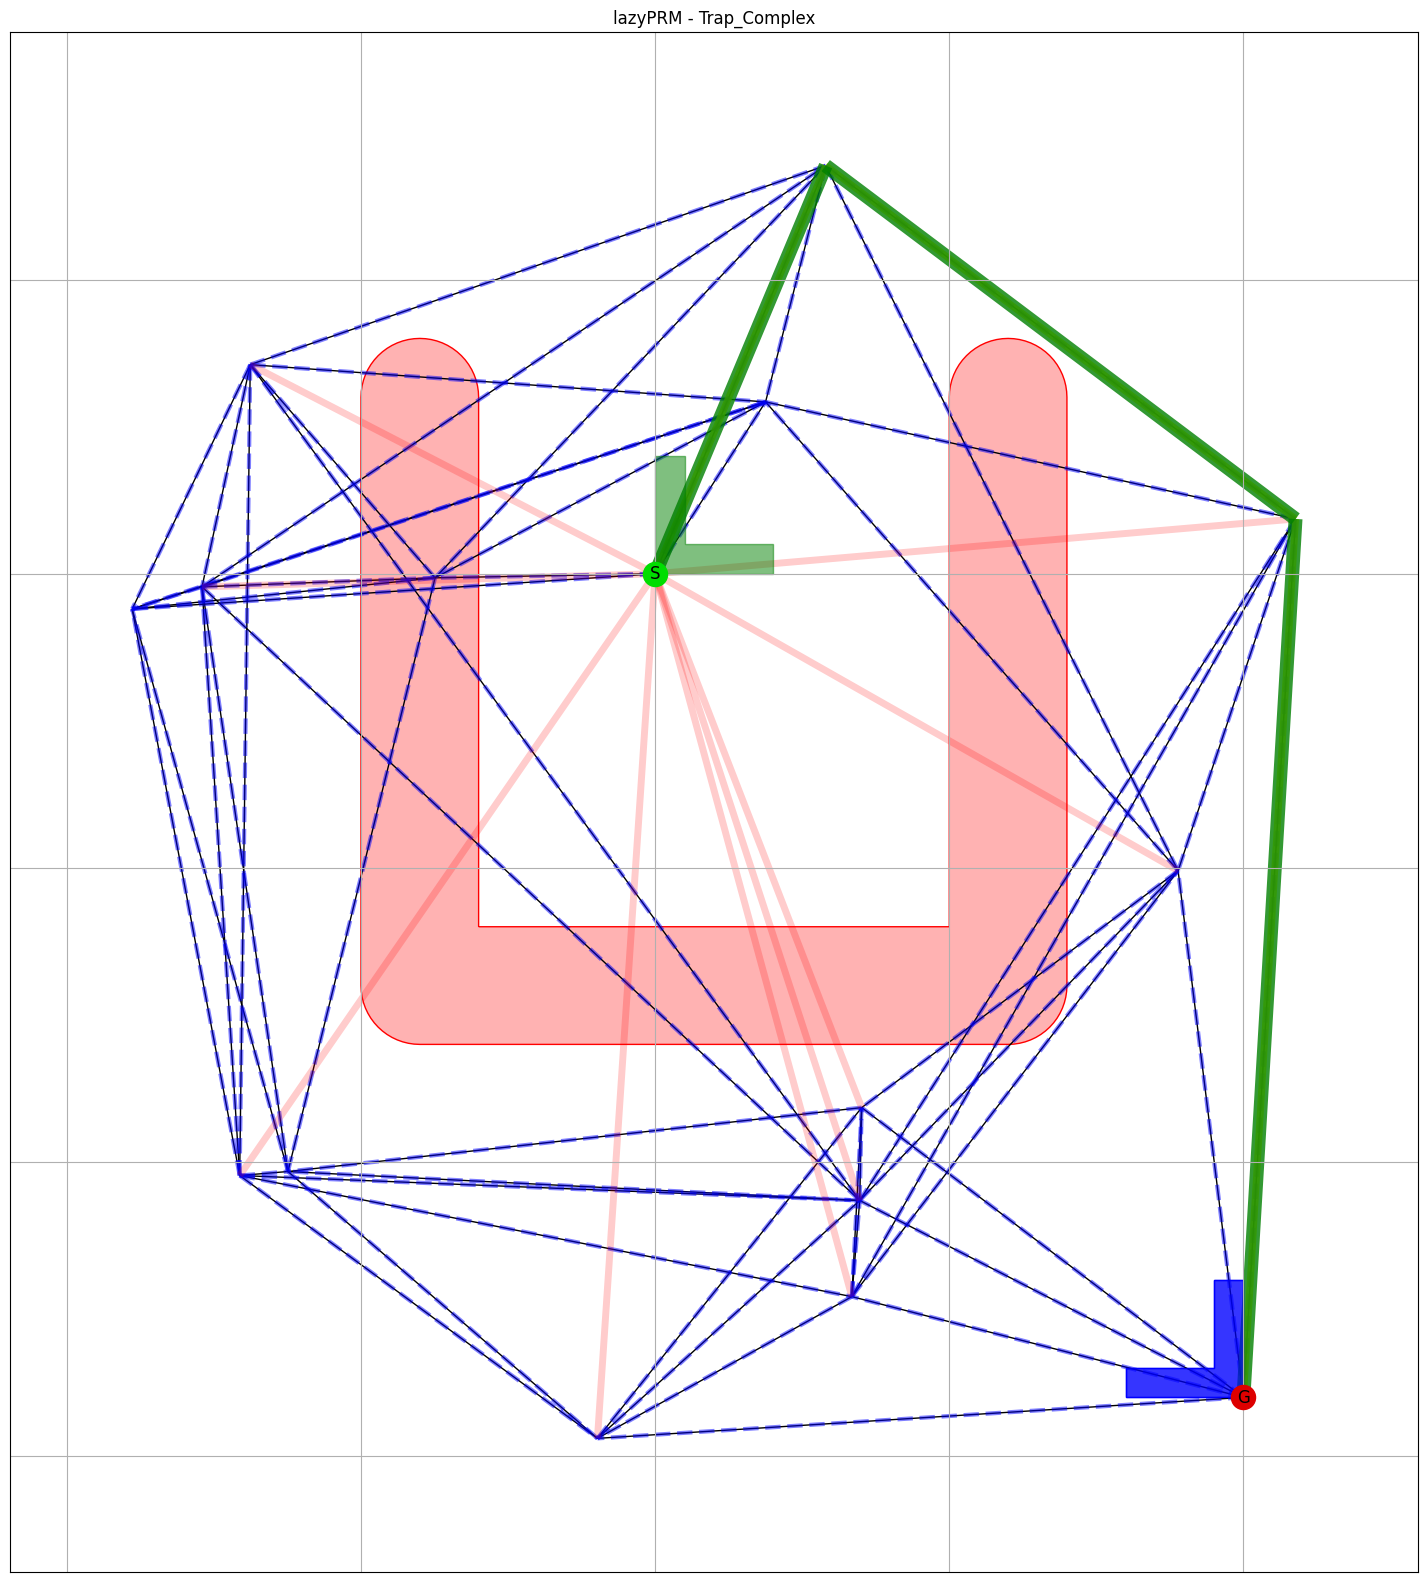

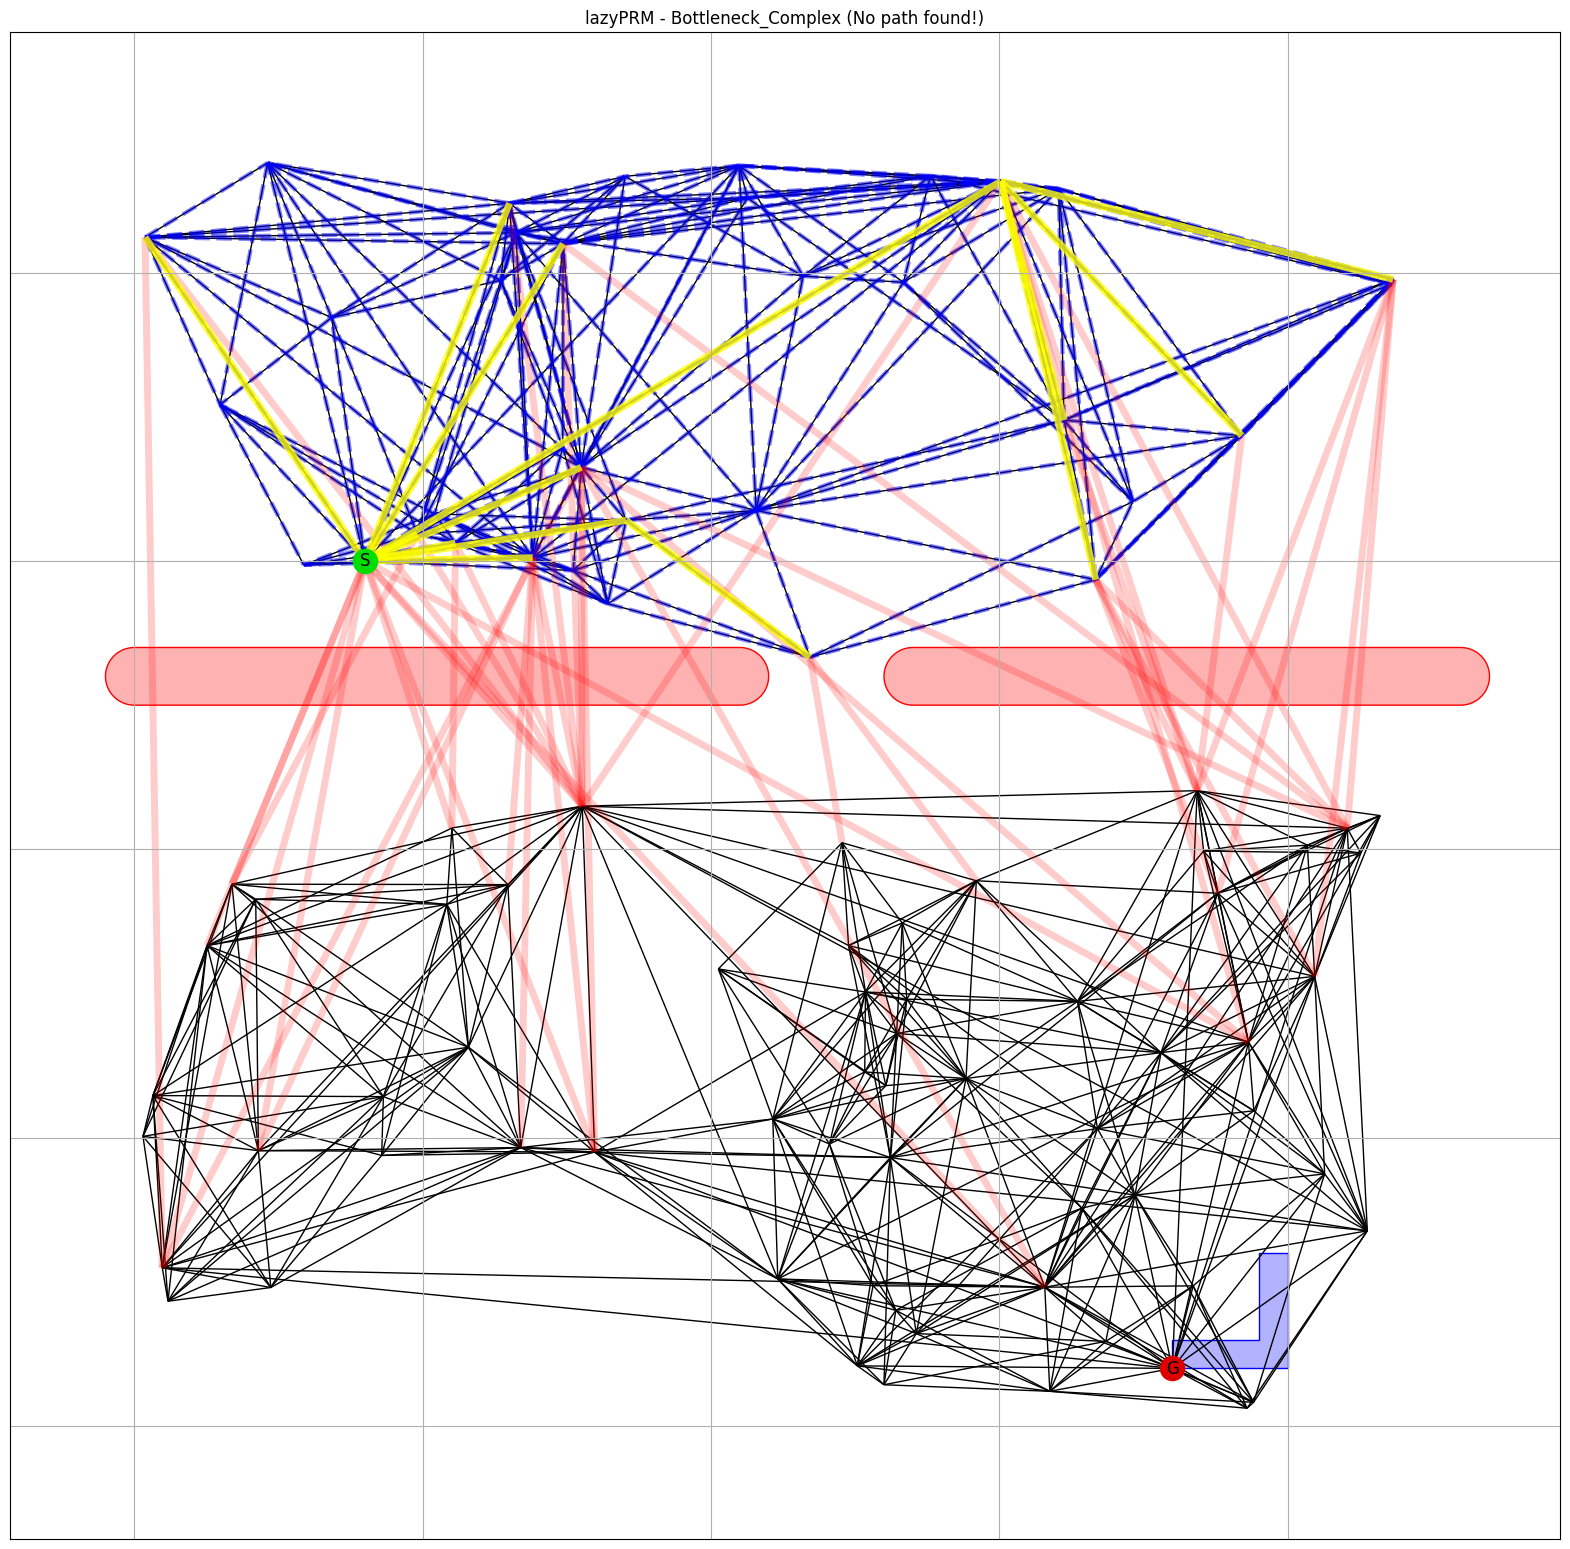

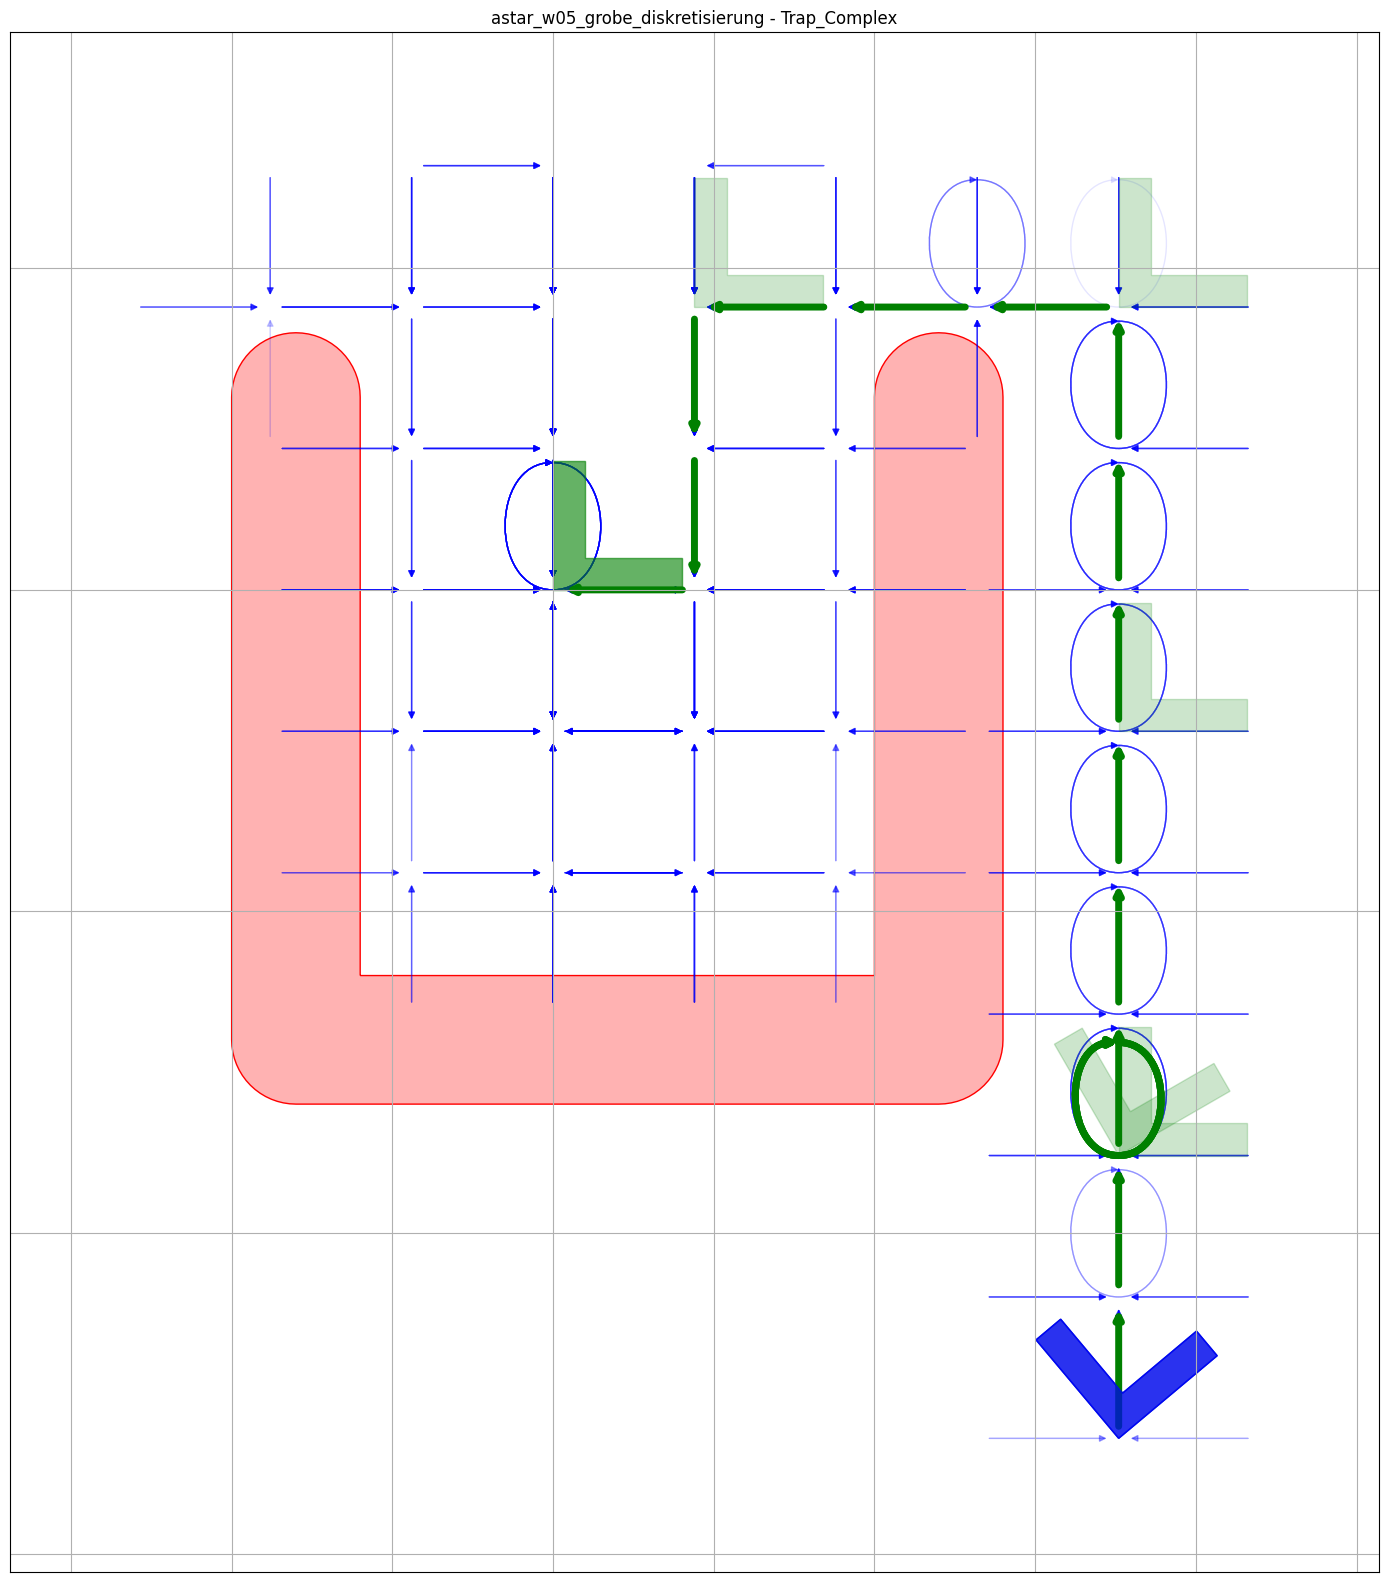

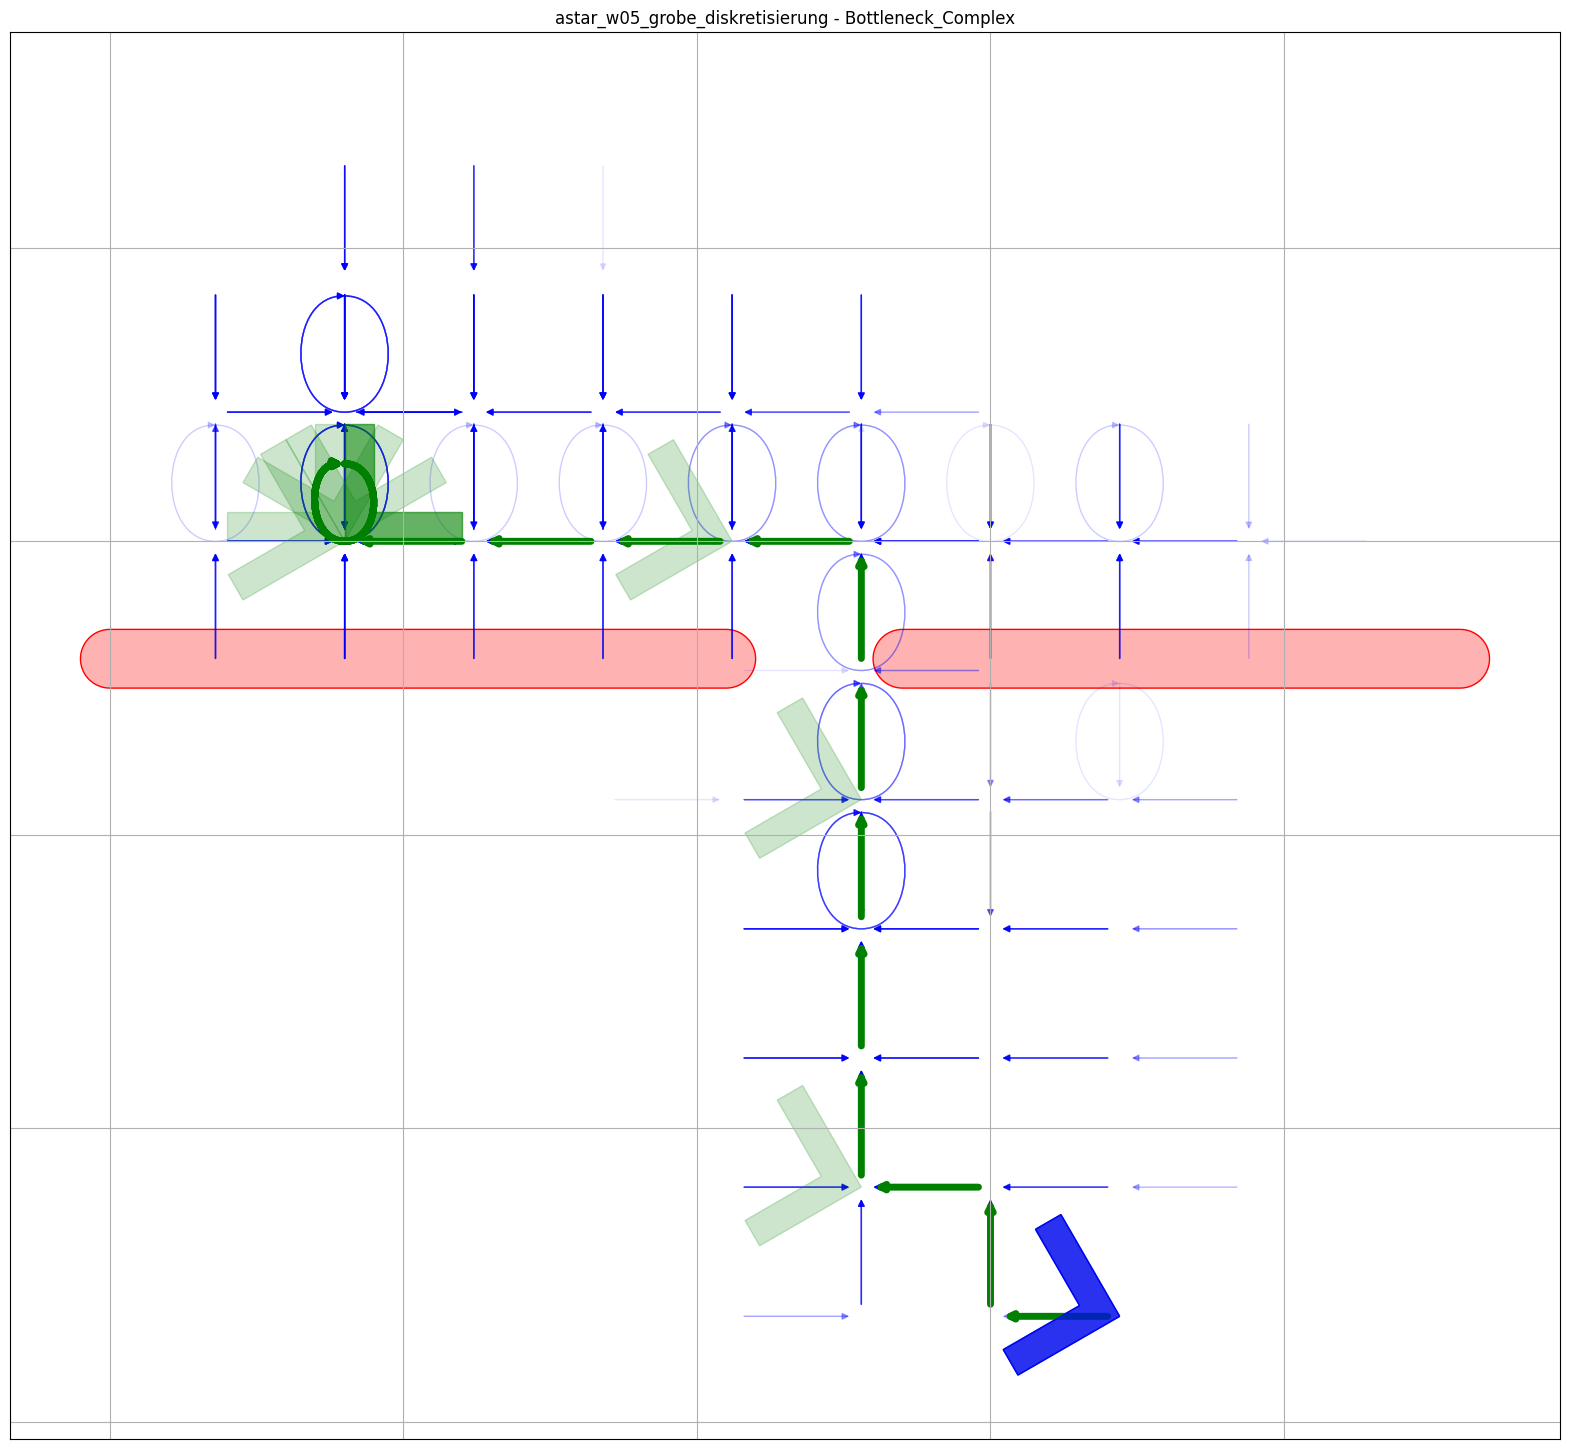

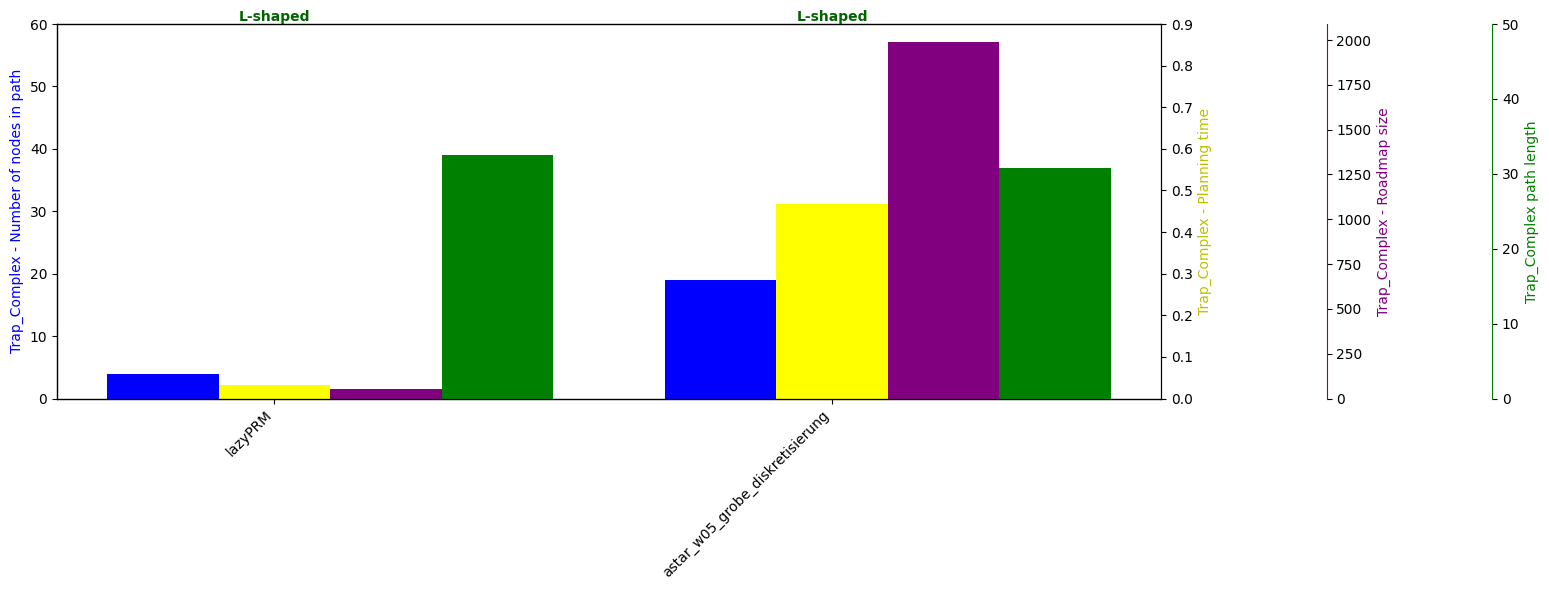

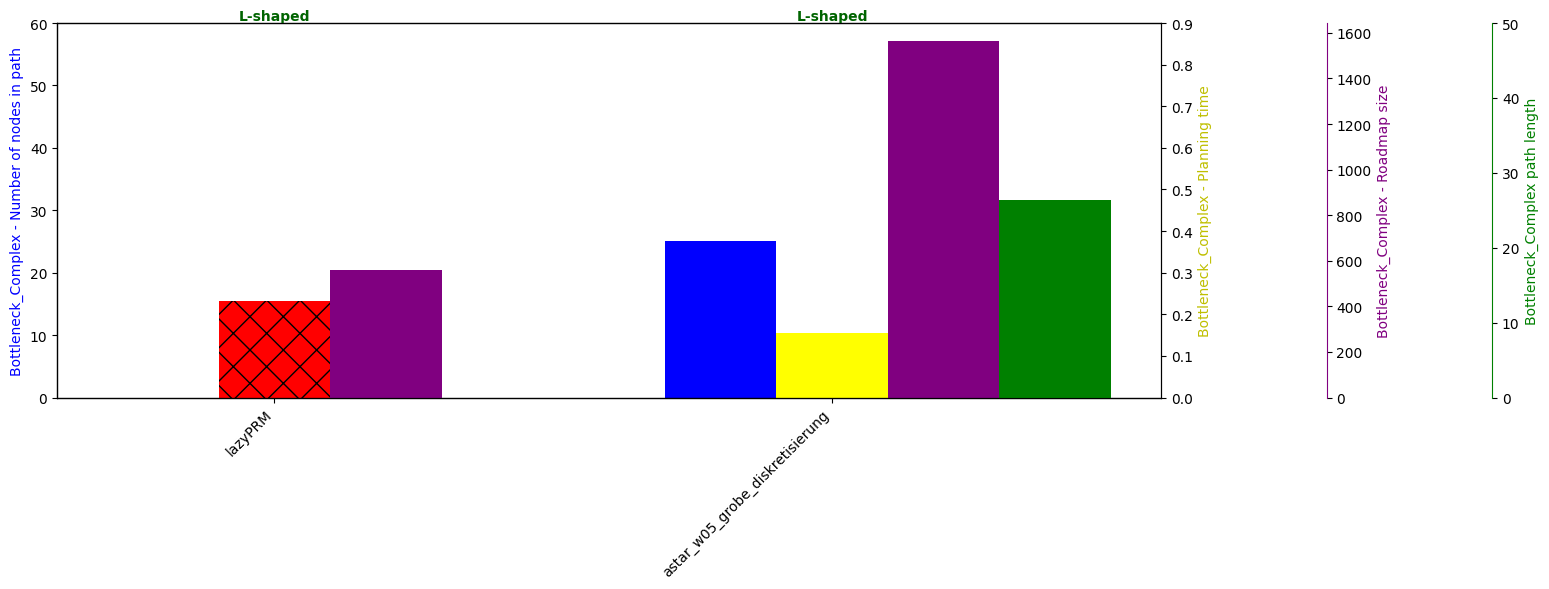

In [17]:
resultList = list()
class ResultCollection (object):
    
    def __init__(self, plannerFactoryName, planner, benchmark, solution, perfDataFrame):
        self.plannerFactoryName = plannerFactoryName
        self.planner = planner
        self.benchmark = benchmark
        self.solution = solution
        self.perfDataFrame = perfDataFrame

import IPTestSuite2 as ts
from shapely.geometry import Point, Polygon, LineString
from shapely import plotting

fullBenchList = ts.benchList

for benchmark in fullBenchList:
    print(benchmark.name)



import matplotlib.animation as animation
from IPython.display import HTML, display
import copy
import numpy as np
import matplotlib.pyplot as plt

# Hilfsfunktion (unverändert, aber wir behandeln den Rückgabewert jetzt besser)
def _interpolate_line(startPos, endPos, step_l):
    steps = []
    line = np.array(endPos) - np.array(startPos)
    line_l = np.linalg.norm(line)
    if line_l == 0:
        return [np.array(startPos)]
    step = line / line_l * step_l
    n_steps = int(np.floor(line_l / step_l))
    c_step = np.array(startPos, dtype=float)
    for i in range(n_steps):
        steps.append(copy.deepcopy(c_step))
        c_step = c_step + step
    if not np.allclose(c_step, np.array(endPos)):
        steps.append(np.array(endPos, dtype=float))
    return steps

def animate_solution_multi_downsampled(prm, environment, solution, visualizer=None, 
                                     workSpaceLimits=None, step_l=0.1, interval=50, 
                                     max_frames=200, figsize=(6,6), dpi=40, 
                                     pause_frames=40):
    
    # 1. Basic Checks
    if not solution or len(solution) < 2:
        raise ValueError('solution must contain at least two nodes')

    # 1. Récupération des positions pour l'interpolation du robot
    path_pos = [prm.graph.nodes[n]['pos'] for n in solution]
    
    # Interpolation (Mouvement fluide du point rouge)
    full_path = [path_pos[0]]
    for i in range(1, len(path_pos)):
        s, e = np.array(path_pos[i-1]), np.array(path_pos[i])
        dist = np.linalg.norm(e - s)
        if dist > 0:
            n_steps = int(np.floor(dist / step_l))
            for j in range(1, n_steps + 1):
                full_path.append(s + (e - s) * (j / (n_steps + 1)))
    full_path.append(path_pos[-1])

    # Downsampling
    if len(full_path) > max_frames:
        indices = np.linspace(0, len(full_path)-1, max_frames).astype(int)
        frames_data = [full_path[i] for i in indices]
    else:
        frames_data = full_path

    # 2. Setup Figure
    fig_local, ax = plt.subplots(figsize=figsize, dpi=dpi)
    limits = environment.getEnvironmentLimits()

    def _animate(current_pos):
        ax.cla() # On efface pour redessiner proprement
        
        # --- VISUALIZER OHNE ROBOTER-SHAPES ---
        # Deaktiviere temporär die drawRobot Methode, damit der Visualizer
        # die Diskretisierung zeichnet, aber nicht die grünen Roboter-Shapes
        original_drawRobot = environment.robot.drawRobot
        environment.robot.drawRobot = lambda ax, **kwargs: None  # Dummy-Funktion
        
        visualizer(prm, solution, ax=ax, nodeSize=100)
        
        # Stelle die ursprüngliche drawRobot Methode wieder her
        environment.robot.drawRobot = original_drawRobot
        
        # On redessine les obstacles par sécurité
        environment.drawObstacles(ax)
        
        # On remet les limites (parce que visualizer peut les changer)
        ax.set_xlim(limits[0])
        ax.set_ylim(limits[1])
        ax.set_title("A* Visualization & Animation")

        # --- MARKIERUNG VON START UND ZIEL ---
        # Startpunkt: Grüner Punkt mit 'S'
        start_pos = path_pos[0]
        ax.plot(start_pos[0], start_pos[1], 'o', color='#00dd00', 
                markersize=15, markeredgecolor='black', zorder=11)
        ax.text(start_pos[0], start_pos[1], 'S', ha='center', va='center',
                fontsize=12, fontweight='bold', color='black', zorder=12)
        
        # Zielpunkt: Roter Punkt mit 'G'
        goal_pos = path_pos[-1]
        ax.plot(goal_pos[0], goal_pos[1], 'o', color='#DD0000', 
                markersize=15, markeredgecolor='black', zorder=11)
        ax.text(goal_pos[0], goal_pos[1], 'G', ha='center', va='center',
                fontsize=12, fontweight='bold', color='white', zorder=12)

        # --- NUR DER ANIMIERTE ROTE ROBOTER ---
        environment.robot.setTo(current_pos)
        environment.robot.drawRobot(ax, color='red', alpha=0.9)

    print(f"Rendu de l'animation (Diskretisierung + nur roter Roboter)...")
    ani = animation.FuncAnimation(fig_local, _animate, frames=frames_data, interval=interval)
    
    html = HTML(ani.to_jshtml())
    display(html)
    plt.close()
    return ani

import networkx as nx

def lazyPRMVisualizeWorkspace(planner, solution = [] , ax=None, nodeSize = 300):
    """
    Angepasster Visualizer für LazyPRM im Workspace (nur x,y aus 3D-Konfigurationsraum)
    """
    graph = planner.graph.copy()
    collChecker = planner._collisionChecker
    collEdges = planner.collidingEdges
    nonCollEdges = planner.nonCollidingEdges
    
    # Extrahiere nur x,y aus (x, y, theta) Positionen
    pos_3d = nx.get_node_attributes(graph,'pos')
    pos = {node: (coords[0], coords[1]) for node, coords in pos_3d.items()}
    
    color = nx.get_node_attributes(graph,'color')

    collChecker.drawObstacles(ax)
    
    # draw graph
    nx.draw_networkx_nodes(graph, pos, ax = ax, nodelist=list(color.keys()), 
                          node_color=list(color.values()), node_size=nodeSize)
    nx.draw_networkx_edges(graph, pos, ax = ax)
    
    # draw all connected components, emphasize the largest one
    Gcc=(graph.subgraph(c) for c in nx.connected_components(graph))
    G0=next(Gcc)
    
    nx.draw_networkx_edges(G0, pos,
                          edge_color='b',
                          width=3.0, style='dashed',
                          alpha=0.5)
    
    if collEdges != []:
        collGraph = nx.Graph()
        collGraph.add_nodes_from(graph.nodes(data=True))
        for i in collEdges:
            collGraph.add_edge(i[0],i[1])
        nx.draw_networkx_edges(collGraph, pos, alpha=0.2, edge_color='r', width=5)
    
    if nonCollEdges != []:
        nonCollGraph = nx.Graph()
        nonCollGraph.add_nodes_from(graph.nodes(data=True))
        for i in nonCollEdges:
            nonCollGraph.add_edge(i[0],i[1])
        nx.draw_networkx_edges(nonCollGraph, pos, alpha=0.8, edge_color='yellow', width=5)
    
    # draw start and goal
    if "start" in graph.nodes(): 
        nx.draw_networkx_nodes(graph, pos, nodelist=["start"],
                              node_size=300,
                              node_color='#00dd00', ax = ax)
        nx.draw_networkx_labels(graph, pos, labels={"start": "S"}, ax = ax)

    if "goal" in graph.nodes():
        nx.draw_networkx_nodes(graph, pos, nodelist=["goal"],
                              node_size=300,
                              node_color='#DD0000', ax = ax)
        nx.draw_networkx_labels(graph, pos, labels={"goal": "G"}, ax = ax)

    if solution != []:
        Gsp = nx.subgraph(graph, solution)
        nx.draw_networkx_edges(Gsp, pos, alpha=0.8, edge_color='g', width=10)
    
    return


# for benchmark in fullBenchList:
#     fig_local = plt.figure(figsize=(7,7))
#     ax = fig_local.add_subplot(1,1,1)
#     title = benchmark.name
#     ax.set_title(title)
#     ax.set_xlim(benchmark.collisionChecker.getEnvironmentLimits()[0])
#     ax.set_ylim(benchmark.collisionChecker.getEnvironmentLimits()[1])
#     plotting.plot_points(Point(benchmark.startList[0]).buffer(.3), color="g", ax=ax)
#     plotting.plot_points(Point(benchmark.goalList[0]).buffer(.3), color="b", ax=ax)
#     #try:
#     benchmark.collisionChecker.drawObstacles(ax)
  
        
#     #except Exception as e:
#     #    print ("Error", e)
#     #    pass
#     plt.show()


resultList = list()
testList = fullBenchList

for key,producer in list(plannerFactory.items()):
    print(key, producer)
    for benchmark in testList:
        print ("Planning: " + key + " - " + benchmark.name)
        #planner = IPBasicPRM.BasicPRM(benchmark.collisionChecker)
        planner = producer[0](benchmark.collisionChecker)
        IPPerfMonitor.clearData()
        try:
            
            resultList.append(ResultCollection(key,
                                          planner, 
                                           benchmark, 
                                           planner.planPath(benchmark.startList,benchmark.goalList,producer[1]),
                                           IPPerfMonitor.dataFrame()
                                          ),
                        )
        except Exception as e:
        #    throw e
            print ("PLANNING ERROR ! PLANNING ERROR ! PLANNING ERROR ", e)
            pass

import matplotlib.pyplot as plt

for result in resultList:
    
    fig_local = plt.figure(figsize=(20,20))
    ax = fig_local.add_subplot(1,1,1)
    title = result.plannerFactoryName + " - " + result.benchmark.name
    if result.solution == []:
        title += " (No path found!)"
    #title += "\n Assumed complexity level " + str(result.benchmark.level)
    ax.set_title(title)
    try:
        # Temporär erweiter Ludwig Setze den Roboter an die Endposition, falls eine Lösung existiert
        if result.solution and len(result.solution) > 0:
            goal_node = result.solution[-1]
            if hasattr(result.planner, 'graph') and goal_node in result.planner.graph.nodes:
                goal_pos = result.planner.graph.nodes[goal_node]['pos']
                result.benchmark.collisionChecker.robot.setTo(goal_pos)
        
        #IPVISBasicsPRM.basicPRMVisualize(result.planner, result.solution, ax=ax, nodeSize=100))
        plannerFactory[result.plannerFactoryName][2](result.planner, result.solution, ax=ax, nodeSize=100)
        
        # Zeichne Roboter am Startpunkt (grün) und Endpunkt (blau)
        if result.solution and len(result.solution) > 0:
            if hasattr(result.planner, 'graph'):
                # Startroboter in grün
                start_node = result.solution[0]
                if start_node in result.planner.graph.nodes:
                    start_pos = result.planner.graph.nodes[start_node]['pos']
                    result.benchmark.collisionChecker.robot.setTo(start_pos)
                    result.benchmark.collisionChecker.robot.drawRobot(ax, color='green', alpha=0.5)
                
                # Endroboter in blau
                goal_node = result.solution[-1]
                if goal_node in result.planner.graph.nodes:
                    goal_pos = result.planner.graph.nodes[goal_node]['pos']
                    result.benchmark.collisionChecker.robot.setTo(goal_pos)
                    result.benchmark.collisionChecker.robot.drawRobot(ax, color='blue', alpha=0.7)
        
    except Exception as e:
        print ("Error", e)
        pass
    
    plt.show()

# for bench in testList:
#     for result in resultList:
#         if result.benchmark.name == bench.name:
#             # Prüfe ob Lösung existiert UND mindestens 2 Knoten hat
#             if result.solution is not None and len(result.solution) >= 2:
#                 print(f"Animation für: {result.plannerFactoryName} - {bench.name}")
#                 print(f"  Anzahl Knoten im Pfad: {len(result.solution)}")
#                 try:
#                     animate_solution_multi_downsampled(
#                         result.planner, bench.collisionChecker, result.solution,
#                         visualizer=plannerFactory[result.plannerFactoryName][2],
#                         step_l=0.05, interval=60, max_frames=200, figsize=(20,20), dpi=40)
#                 except Exception as e:
#                     print(f"  FEHLER bei Animation: {e}")
#             else:
#                 if result.solution is None:
#                     print(f"Keine Animation für {result.plannerFactoryName} - {bench.name}: Keine Lösung gefunden")
#                 else:
#                     print(f"Keine Animation für {result.plannerFactoryName} - {bench.name}: Zu wenige Knoten ({len(result.solution)})")

def compute_path_lengths_multi(graph, solution, theta_in_radians=True):
    """
    Berechnet die Gesamtpfadläng pro Roboter in einem Graphen mit mehreren Robotern

    Das Knotenattribut 'pos' ist eine sequenz [x1,y1,theta1, x2,y2,theta2,...]
    Für unsere zwei Roboter sind es 6 Einträge pro Knoten.
    Die Funktion summiert die euklidischen Distanzen zwischen jedem Knotenpaar (Kanten) in der xy-Ebene für jeden Roboter auf.
    """
    import numpy as np
    import networkx as nx

    # Falls keine Lösung oder nur ein Knoten vorhanden ist, sofort Nullwerte zurückgeben
    if not solution or len(solution) < 2:
        return {
            'green': {'total': 0.0},
            'red': {'total': 0.0},
            'segments': 0
        }

    # Hole alle 'pos' Attribute aus dem Graph (dict: node -> config)
    pos_attr = nx.get_node_attributes(graph, 'pos')
    total_g = 0.0  # aufsummierte Distanz für grünen Roboter (Roboter 1)
    total_r = 0.0  # aufsummierte Distanz für roten Roboter (Roboter 2)
    segments = 0   # Anzahl der Segmente (Anzahl Kanten im Pfad)

    # Iteriere über alle aufeinanderfolgenden Knotenpaare der Lösung
    for i in range(len(solution) - 1):
        a = solution[i]; b = solution[i + 1]
        # Fehler, falls ein Knoten kein 'pos' Attribut hat (schützt vor inkonsistenten Graphen)
        if a not in pos_attr or b not in pos_attr:
            raise ValueError(f"Node {a} or {b} missing 'pos' attribute in graph")
        pa = np.array(pos_attr[a], dtype=float)  # Konfiguration an Knoten a
        pb = np.array(pos_attr[b], dtype=float)  # Konfiguration an Knoten b

        # Berechne Euklidische Distanz in der xy‑Ebene für Roboter 1 (grün)
        # pa[0:2] und pb[0:2] sind [x1,y1] für Roboter 1
        total_g += float(np.linalg.norm(pb[0:2] - pa[0:2]))

        # Berechne Euklidische Distanz in der xy‑Ebene für Roboter 2 (rot)
        # pa[3:5] und pb[3:5] sind [x2,y2] für Roboter 2
        total_r += float(np.linalg.norm(pb[3:5] - pa[3:5]))

        segments += 1  # ein weiteres Kanten-Segment wurde betrachtet

    # Rückgabe: pro Roboter nur die 'total' Länge (Rotationen werden hier bewusst nicht berücksichtigt)
    return {
        'green': {'total': total_g},
        'red': {'total': total_r},
        'segments': segments
    }




def get_robot_shape_description(benchmark):
    """Ermittelt eine Beschreibung der Roboterform basierend auf der Geometrie."""
    try:
        robot = benchmark.collisionChecker.robot
        if hasattr(robot, '_template'):
            # ShapeRobotWithOrientation - verwende Template Geometrie
            coords = list(robot._template.exterior.coords)
        elif hasattr(robot, 'geometry'):
            # ShapeRobot - verwende direkte Geometrie
            coords = list(robot.geometry.exterior.coords)
        else:
            return "Unknown"
        
        # Analysiere die Form basierend auf Eckpunkten
        num_vertices = len(coords) - 1  # Letzter Punkt = erster Punkt
        
        # Prüfe ob es ein Rechteck ist (4 Eckpunkte)
        if num_vertices == 4:
            # Prüfe Dimensionen
            xs = [c[0] for c in coords]
            ys = [c[1] for c in coords]
            width = max(xs) - min(xs)
            height = max(ys) - min(ys)
            
            if abs(width - 2.5) < 0.1 and abs(height - 1.0) < 0.1:
                return "Rectangle (2.5x1.0)"
            else:
                return f"Rectangle ({width:.1f}x{height:.1f})"
        
        # Prüfe ob es ein L-förmiger Roboter ist (6 Eckpunkte)
        elif num_vertices == 6:
            return "L-shaped"
        
        else:
            return f"Custom ({num_vertices} vertices)"
    except:
        return "Unknown"

import numpy as np
for bench in testList:
    title = bench.name
    
    # Roboter-Form zur Beschreibung hinzufügen
    robot_shape = get_robot_shape_description(bench)
    
    pathLength = dict()
    planningTime = dict()
    roadmapSize  = dict()
    res=dict()

    try:
        for result in resultList:
            if result.benchmark.name == bench.name:
                #print result.benchmark.name  + " - " +  result.plannerFactoryName, len(result.solution)
                pathLength[result.plannerFactoryName] = len(result.solution)
                planningTime[result.plannerFactoryName] = result.perfDataFrame.groupby(["name"]).sum(numeric_only=True)["time"]["planPath"]
                roadmapSize[result.plannerFactoryName] = result.planner.graph.size()
                res[result.plannerFactoryName] = compute_path_lengths_multi(result.planner.graph, result.solution, theta_in_radians=True)

        fig, ax = plt.subplots(figsize=(16, 6))  # Breitere Figur

        width = 0.2

        ax.bar(np.arange(len(pathLength.keys())), pathLength.values(),width, color="blue")
        ax.set_ylabel(title + " - Number of nodes in path", color="blue")
        ax.set_ylim(0,60)
        ax.set_xticks(np.arange(len(pathLength.keys())) + width)
        ax.set_xticklabels(pathLength.keys(), rotation=45, ha='right')  # Rotierte Labels

        ax2 = ax.twinx()
        bar = ax2.bar(np.arange(len(pathLength.keys()))+width, planningTime.values(),width, color="red")
        ax2.set_ylabel(title + " - Planning time", color="y")
        ax2.set_ylim(0,0.9)

        # Add coloring and patterns on axis two
        hatches = ['x' if length==0 else '' for length in pathLength.values()]
        color   = ['red' if length==0 else 'yellow' for length in pathLength.values()]
        for i,thisbar in enumerate(bar.patches):
            thisbar.set_facecolor(color[i])
            thisbar.set_hatch(hatches[i])

        # Multiple axes 
        ax3 = ax.twinx()
        ax3.bar(np.arange(len(pathLength.keys()))+2*width, roadmapSize.values(),width, color="purple")
        ax3.set_ylabel(title + " - Roadmap size",  color="purple")
        ax3.spines['right'].set_position(('axes', 1.15))
        ax3.spines['right'].set_color("purple")

        ax4 = ax.twinx()
        ax4.bar(np.arange(len(pathLength.keys()))+3*width, [res[planner].get('green', {}).get('total', 0) for planner in pathLength.keys()], width, color="green")
        ax4.set_ylabel(title + " path length", color="green")
        ax4.spines['right'].set_position(('axes', 1.3))
        ax4.spines['right'].set_color("green")
        ax4.set_ylim(0,50)
        
        # Roboterform über den Balken anzeigen
        # Berechne die maximale Höhe für die Positionierung
        max_y = max(list(roadmapSize.values()) + [0]) if roadmapSize else 0
        
        # Text mittig über allen Balkengruppen platzieren
        for i in range(len(pathLength.keys())):
            ax3.text(i + width, max_y * 1.05, f"{robot_shape}", 
                    ha='center', va='bottom', fontsize=10, fontweight='bold',
                    rotation=0, color='darkgreen')
        
        plt.tight_layout()  # Besseres Layout, verhindert abgeschnittene Labels
    except:
        pass

    plt.show()
    

